## Readme
- 该版本在基础模型上增加了基于傅里叶遍历度量的条件引导
- 如果只是载入模型而不需要训练的情况下，直接执行Cell01-07+Cell10-11及其后面Cell12-14的可视化（可选）；即跳过Cell08-09.

## Cell 01 — 配置与设备/随机种子

In [1]:
# Cell 01: Config + device + seed (standalone)

import os, yaml, random
from types import SimpleNamespace
from pathlib import Path
import numpy as np
import torch

def to_ns(d):
    if isinstance(d, dict): return SimpleNamespace(**{k: to_ns(v) for k,v in d.items()})
    if isinstance(d, list): return [to_ns(x) for x in d]
    return d

def load_config(path="config/config_ergodic.yaml"):
    cfg = None
    p = Path(path)
    if p.exists():
        with open(p, "r") as f:
            cfg = yaml.safe_load(f)
    else:
        # Fallback 默认配置（独立运行）
        cfg = {
            "data": {
                # "data_dir": "data/ergodic_dataset_wild_full",   # 相对当前notebook目录
                # "data_dir": "data/ergodic_dataset",
                "data_dir": "data/ergodic_diagonal",
                "trajectory_len": 101,
                "robot_state_dim": 4,
                "distribution_dim": [32,32],
                "validation_split": 0.1,
                "num_workers": 0,
                "shuffle_dataset": True,
                "seed": 42
            },
            "training": {
                "batch_size": 64,
                "device": "cuda",
                "seed": 42
            },
            "diffusion": {
                "beta_min": 0.1,
                "beta_max": 20.0,
                "steps": 100
            },
            "normalizer": {
                "robot_state": {"mean": [0.0,0.0,0.0,0.0], "std": [1.0,1.0,1.0,1.0]}
            }
        }
    cfg = to_ns(cfg)

    # 兼容顶层常用字段
    cfg.data_dir = cfg.data.data_dir
    cfg.trajectory_len = cfg.data.trajectory_len
    cfg.robot_state_dim = cfg.data.robot_state_dim
    cfg.distribution_dim = cfg.data.distribution_dim

    # 规范化 mean/std 为 tensor
    mean = torch.as_tensor(cfg.normalizer.robot_state.mean, dtype=torch.float32)
    std  = torch.as_tensor(cfg.normalizer.robot_state.std,  dtype=torch.float32)
    std  = torch.where(std==0, torch.tensor(1.0), std)
    cfg.normalizer.robot_state.mean = mean
    cfg.normalizer.robot_state.std  = std
    return cfg

config = load_config()  # 如需自定义，改这里路径
device = torch.device(config.training.device if torch.cuda.is_available() else "cpu")

# 采样期能量引导参数（紧跟在 config = load_config() 之后）
if not hasattr(config, "sampling"):
    class _S: pass
    config.sampling = _S()
config.sampling.use_energy_guidance = True
config.sampling.fourier_Kx = 8
config.sampling.fourier_Ky = 8
config.sampling.time_discount_alpha = 2.0
config.sampling.eta_base = 0.2         # 0.1–0.3 可调
config.sampling.erg_budget = None      # 先不设预算
config.sampling.erg_gate_tau = 0.05
config.sampling.guide_scale = 1.0
print("sampling cfg:",
      {k: getattr(config.sampling, k) for k in
       ["use_energy_guidance","fourier_Kx","fourier_Ky","eta_base","erg_budget"]})

# 随机种子
seed = int(getattr(config.training, "seed", 42))
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

print("Device:", device)
print("Data dir:", config.data_dir)


sampling cfg: {'use_energy_guidance': True, 'fourier_Kx': 8, 'fourier_Ky': 8, 'eta_base': 0.2, 'erg_budget': None}
Device: cuda
Data dir: /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/data/ergodic_diagonal


## Cell 02 — 数据集与 DataLoader
获取训练/验证 DataLoader（Dataset 已含 padding）
-改动目标：新增一个 _pack_gaussian_params 方法。
-逻辑：设定一个最大组件数 N_MAX（例如 20）。将每个样本的 GMM 参数展平并填充到这个长度。同时返回一个 mask，告诉模型哪些是真实数据，哪些是填充的 0。

In [2]:
# Cell 02: Data module (v3.5: Gamma Injection + Safe Gaussian Params + Normalization Fix)

import os, json, numpy as np, torch
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

def as_tensor_f32(x):
    return x.to(torch.float32) if isinstance(x, torch.Tensor) else torch.as_tensor(x, dtype=torch.float32)

class ErgodicDataset(Dataset):
    def __init__(self, data_dir, transform=None, max_trajectory_len=101, use_index=True, max_gaussians=20):
        self.data_dir = data_dir
        self.transform = transform  # <--- 虽然这里存了，但之前没用
        self.max_trajectory_len = max_trajectory_len
        self.max_gaussians = max_gaussians
        
        self.distributions_dir = os.path.join(data_dir, 'distributions')
        self.trajectories_dir  = os.path.join(data_dir, 'trajectories')
        self.data_pairs = []

        index_path = os.path.join(data_dir, 'dataset_index.json')
        
        index_loaded = False
        if use_index and os.path.exists(index_path):
            try:
                with open(index_path, 'r') as f:
                    loaded_data = json.load(f)
                if isinstance(loaded_data, list):
                    self.data_pairs = loaded_data
                    index_loaded = True
            except: pass
        
        if not index_loaded or len(self.data_pairs) == 0:
            self._build_index(index_path)
            
    def _build_index(self, index_path):
        self.data_pairs = [] 
        dist_files = [f for f in os.listdir(self.distributions_dir) if f.endswith('.json')]
        dist_id_to_file = {}
        for df in dist_files:
            try:
                with open(os.path.join(self.distributions_dir, df), 'r') as f:
                    d = json.load(f)
                dist_id_to_file[d['id']] = df
            except: pass

        for tf in os.listdir(self.trajectories_dir):
            if tf.endswith('.json'):
                try:
                    with open(os.path.join(self.trajectories_dir, tf), 'r') as f:
                        t = json.load(f)
                    did = t['distribution_id']
                    if did in dist_id_to_file:
                        self.data_pairs.append({
                            'distribution_file': dist_id_to_file[did],
                            'trajectory_file': tf
                        })
                except: pass
        try:
            with open(index_path, 'w') as f:
                json.dump(self.data_pairs, f)
        except: pass

    def __len__(self):
        return len(self.data_pairs)

    def _generate_distribution_grid(self, dist_data, grid_size=(32,32)):
        # (保持不变)
        bounds = dist_data.get('bounds', [[0,3],[0,3]])
        centers = np.asarray(dist_data['params']['centers'])
        covs    = np.asarray(dist_data['params']['covs'])
        weights = np.asarray(dist_data['params']['weights'])
        n = int(dist_data['params']['n_gaussians'])
        x = np.linspace(bounds[0][0], bounds[0][1], grid_size[0])
        y = np.linspace(bounds[1][0], bounds[1][1], grid_size[1])
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X, dtype=np.float64)
        for i in range(n):
            cx, cy = centers[i]
            c = covs[i]
            if np.isscalar(c): sx, sy = c, c
            elif len(np.shape(c)) == 1: sx, sy = c[0], c[1]
            else: sx, sy = np.sqrt(np.diag(c))
            Z += weights[i] * np.exp(-(((X-cx)**2)/(2*sx**2 + 1e-8) + ((Y-cy)**2)/(2*sy**2 + 1e-8)))
        Z /= (Z.max() + 1e-8)
        return Z

    def _process_trajectory(self, traj_data):
        # (保持不变)
        states = np.asarray(traj_data['states'], dtype=np.float64)
        pos = states[:, :2]
        vel = np.zeros((states.shape[0],1))
        if states.shape[1] > 3: vel = states[:, 3:4]
        elif states.shape[0] > 1: 
            dt = float(traj_data['time_step'])
            d = np.linalg.norm(np.diff(pos, axis=0), axis=1)
            vel = np.vstack([np.zeros((1,1)), (d/dt)[:,None]])
        heading = states[:, 2:3] if states.shape[1] > 2 else np.zeros((states.shape[0],1))
        rs = np.hstack([pos, heading, vel])
        
        T = self.max_trajectory_len
        controls = np.zeros((T, 2), dtype=np.float32)
        
        if len(rs) > T:
            idx = np.linspace(0, len(rs)-1, T).astype(int)
            rs = rs[idx]
        elif len(rs) < T:
            pad = T - len(rs)
            rs = np.vstack([rs, np.zeros((pad, rs.shape[1]))])
            
        return rs, controls, float(traj_data['time_step']), float(traj_data['total_time']), float(traj_data['ergodic_metric']), float(traj_data['gamma'])

    def _pack_gaussian_params(self, dist_data):
        # (保持不变)
        n = int(dist_data['params']['n_gaussians'])
        centers = np.asarray(dist_data['params']['centers'])
        weights = np.asarray(dist_data['params']['weights'])
        covs_raw = dist_data['params']['covs']
        packed = np.zeros((self.max_gaussians, 7), dtype=np.float32)
        mask = np.zeros((self.max_gaussians), dtype=bool)
        mask[n:] = True
        for i in range(min(n, self.max_gaussians)):
            packed[i, 0:2] = centers[i]
            c = covs_raw[i]
            if np.isscalar(c): cov_mat = np.array([c, 0, 0, c])
            elif len(np.shape(c)) == 1: cov_mat = np.array([c[0], 0, 0, c[1]])
            else: cov_mat = np.asarray(c).flatten()
            if cov_mat.size == 4: packed[i, 2:6] = cov_mat
            packed[i, 6] = weights[i]
        return packed, mask

    def __getitem__(self, idx):
        pair = self.data_pairs[idx]
        with open(os.path.join(self.distributions_dir, pair['distribution_file']), 'r') as f:
            dist_data = json.load(f)
        with open(os.path.join(self.trajectories_dir, pair['trajectory_file']), 'r') as f:
            traj_data = json.load(f)

        distribution_grid = self._generate_distribution_grid(dist_data) 
        rs, controls, time_step, total_time, ergodic_metric, gamma = self._process_trajectory(traj_data)
        gmm_packed, gmm_padding_mask = self._pack_gaussian_params(dist_data)
        
        centers_padded = as_tensor_f32(gmm_packed[:, 0:2]) 
        covs_padded    = as_tensor_f32(gmm_packed[:, 2:6])
        weights_padded = as_tensor_f32(gmm_packed[:, 6])
        n_gauss = int(dist_data['params']['n_gaussians'])
        
        sample = {
            "distribution": as_tensor_f32(distribution_grid).unsqueeze(0), 
            "robot_state": as_tensor_f32(rs[0]),
            "trajectories": as_tensor_f32(rs),
            "controls": as_tensor_f32(controls),
            "gamma": as_tensor_f32(gamma).view(1),
            "gaussian_packed": as_tensor_f32(gmm_packed),        
            "gaussian_padding_mask": torch.tensor(gmm_padding_mask, dtype=torch.bool), 
            "gaussian_params": {
                "n_gaussians": torch.tensor(n_gauss, dtype=torch.long), 
                "centers": centers_padded,
                "covs": covs_padded,
                "weights": weights_padded
            }
        }
        
        # --- [关键修复]：手动激活 Transform！---
        if self.transform is not None:
            sample = self.transform(sample)
        # ------------------------------------
        
        return sample

# (build_loaders 代码保持你原来的不变，因为它看起来逻辑是对的，只是调用了有Bug的Dataset)

# Cell 02: Data module (Fixed: Train/Val/Test Map-based Split)

def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, 
                  val_split=0.1, test_split=0.05,  # <--- 新增 test_split
                  num_workers=0, seed=42, transform=None):
    
    ds = ErgodicDataset(data_dir=data_dir, transform=transform, max_trajectory_len=max_trajectory_len)
    
    print(f"📊 Splitting dataset by Distribution ID (Total Pairs: {len(ds)})...")
    
    # 1. 提取所有唯一的 distribution 文件名 (作为 ID)
    all_dist_files = sorted(list(set([p['distribution_file'] for p in ds.data_pairs])))
    n_dists = len(all_dist_files)
    
    if n_dists == 0:
        raise RuntimeError("No distributions found! Check data directory.")
        
    # 2. 对“地图”进行随机打乱
    rng = np.random.RandomState(seed)
    rng.shuffle(all_dist_files)
    
    # 3. 计算切分数量
    n_test_dists = int(np.floor(test_split * n_dists))
    n_val_dists  = int(np.floor(val_split * n_dists))
    
    # 确保至少有 1 个，除非本来就没设
    if test_split > 0 and n_test_dists == 0: n_test_dists = 1
    if val_split > 0 and n_val_dists == 0: n_val_dists = 1
    
    # 4. 划分集合
    test_dist_set = set(all_dist_files[:n_test_dists])
    val_dist_set  = set(all_dist_files[n_test_dists : n_test_dists + n_val_dists])
    train_dist_set = set(all_dist_files[n_test_dists + n_val_dists :])
    
    print(f"   Maps Split -> Train: {len(train_dist_set)}, Val: {len(val_dist_set)}, Test: {len(test_dist_set)}")
    
    # 5. 根据地图归类轨迹索引
    train_idx, val_idx, test_idx = [], [], []
    
    for i, pair in enumerate(ds.data_pairs):
        d_file = pair['distribution_file']
        if d_file in train_dist_set:
            train_idx.append(i)
        elif d_file in val_dist_set:
            val_idx.append(i)
        elif d_file in test_dist_set:
            test_idx.append(i)
            
    print(f"   Trajectories -> Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
    
    # 6. 构建 Loaders
    train_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    
    val_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(val_idx),
                            num_workers=num_workers, pin_memory=True, drop_last=False)
    
    # Test Loader 通常不需要 shuffle，也不需要 drop_last，方便确定的评估
    # 但为了接口一致性，这里还是用了 SubsetRandomSampler，也可以改用 Subset
    test_loader = None
    if len(test_idx) > 0:
        test_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(test_idx),
                                 num_workers=num_workers, pin_memory=True, drop_last=False)
    else:
        print("⚠️ Warning: Test set is empty!")
    
    return train_loader, val_loader, test_loader

print("ErgodicDataset ready (v3.5: Gamma + Safe Gaussian Params).")

ErgodicDataset ready (v3.5: Gamma + Safe Gaussian Params).


In [3]:
import inspect

# 打印出 Python 内存里 build_loaders 函数的真实源代码
print(inspect.getsource(build_loaders))

def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, 
                  val_split=0.1, test_split=0.05,  # <--- 新增 test_split
                  num_workers=0, seed=42, transform=None):
    
    ds = ErgodicDataset(data_dir=data_dir, transform=transform, max_trajectory_len=max_trajectory_len)
    
    print(f"📊 Splitting dataset by Distribution ID (Total Pairs: {len(ds)})...")
    
    # 1. 提取所有唯一的 distribution 文件名 (作为 ID)
    all_dist_files = sorted(list(set([p['distribution_file'] for p in ds.data_pairs])))
    n_dists = len(all_dist_files)
    
    if n_dists == 0:
        raise RuntimeError("No distributions found! Check data directory.")
        
    # 2. 对“地图”进行随机打乱
    rng = np.random.RandomState(seed)
    rng.shuffle(all_dist_files)
    
    # 3. 计算切分数量
    n_test_dists = int(np.floor(test_split * n_dists))
    n_val_dists  = int(np.floor(val_split * n_dists))
    
    # 确保至少有 1 个，除非本来就没设
    if test_split > 0 and n_test_dists == 0: n_test_dists = 1
    if val_spli

## Cell 03 —  SDE 与训练/评估通用工具

In [4]:
# Cell 03: VPSDE_linear + training utilities

import math
import torch
import torch.nn as nn

class VPSDE_linear:
    def __init__(self, beta_min=0.1, beta_max=20.0):
        self._beta_min = float(beta_min)
        self._beta_max = float(beta_max)
    @property
    def T(self): return 1.0
    def marginal_prob(self, x, t):
        # x_t = exp(mean_log_coeff)*x0 + std*z
        shape = x.shape
        t = t.view(-1, *([1]*(len(shape)-1)))
        mlc = -0.25 * t**2 * (self._beta_max - self._beta_min) - 0.5*self._beta_min*t
        mean = torch.exp(mlc) * x
        std  = torch.sqrt(torch.clamp(1 - torch.exp(2*mlc), min=1e-6))
        return mean, std

def time_weighted_masked_mse(pred, target, gamma=4.0, eps=1e-8):
    # pred/target: [B,T,D]；仅有效时刻参与；末段权重大
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()            # [B,T]
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w*mask); w = w/(w.sum(dim=1, keepdim=True)+eps)
    diff2 = ((pred-target)**2).sum(dim=-1)
    return (((diff2*w).sum(dim=1)).mean())/D

def last_valid_idx_xy(xy, eps=1e-8):
    # xy: [B,T,2] or [T,2]
    if xy.ndim == 2:
        valid = ~(xy.abs().sum(dim=-1) <= eps)
        k = torch.nonzero(valid)[-1].item() if valid.any() else xy.shape[0]-1
        return k
    valid = ~(xy.abs().sum(dim=-1) <= eps)                     # [B,T]
    idx = []
    for b in range(xy.shape[0]):
        v = valid[b]; k = torch.nonzero(v)[-1].item() if v.any() else xy.shape[1]-1
        idx.append(k)
    return torch.tensor(idx, device=xy.device, dtype=torch.long)


## Cell 03.5  —  定义Normalizer

In [5]:
# Cell: Define Normalizer Utility (Standard Engineering Solution)

import torch
import os

class DatasetNormalizer:
    def __init__(self, data_dir, device='cpu'):
        self.device = device
        self.stats = None
        
        # 1. 尝试加载统计量
        stats_path = os.path.join(data_dir, "dataset_stats.pt")
        # 备用路径逻辑 (适配 config)
        if not os.path.exists(stats_path):
             stats_path = getattr(getattr(globals().get("config", object()), "data", object()), "data_dir", "data/ergodic_dataset") + "/dataset_stats.pt"
             
        if os.path.exists(stats_path):
            print(f"✅ [Normalizer] Loading stats from {stats_path}")
            self.stats = torch.load(stats_path, map_location=device)
            
            # 预处理参数，方便广播 (Broadcasting)
            # Trajectories: [1, 1, 4] 用于 (B, T, 4)
            self.t_mean = self.stats['trajectories']['mean'].view(1, 1, 4).to(device)
            self.t_std  = self.stats['trajectories']['std'].view(1, 1, 4).to(device)
            
            # Robot State: [1, 4] 用于 (B, 4)
            self.rs_mean = self.stats['robot_state']['mean'].view(1, 4).to(device)
            self.rs_std  = self.stats['robot_state']['std'].view(1, 4).to(device)
        else:
            print("⚠️ [Normalizer] No stats file found. Identity transform will be used.")

    def denormalize_traj(self, traj_norm):
        """ 反归一化轨迹: Norm -> Phys """
        if self.stats is None: return traj_norm
        return traj_norm * self.t_std + self.t_mean

    def normalize_traj(self, traj_phys):
        """ 归一化轨迹: Phys -> Norm """
        if self.stats is None: return traj_phys
        # 避免除零
        safe_std = torch.where(self.t_std < 1e-6, torch.ones_like(self.t_std), self.t_std)
        return (traj_phys - self.t_mean) / safe_std

    def denormalize_state(self, state_norm):
        """ 反归一化机器人状态 """
        if self.stats is None: return state_norm
        return state_norm * self.rs_std + self.rs_mean

# 实例化一个全局对象 (方便后续 Cell 调用)
# 确保 DATA_DIR 变量存在
DATA_DIR = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/data/ergodic_diagonal"
if not os.path.exists(DATA_DIR):
     DATA_DIR = getattr(getattr(globals().get("config", object()), "data", object()), "data_dir", "data/ergodic_dataset")

global_normalizer = DatasetNormalizer(DATA_DIR, device=device)

✅ [Normalizer] Loading stats from /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/data/ergodic_diagonal/dataset_stats.pt


/tmp/ipykernel_1468788/3473746835.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.stats = torch.load(stats_path, map_location=device)


## Cell 04 — Encoder
-架构：
1.GMM Embedding: 用 MLP 将 [7] 维的 GMM 参数映射到 hidden_dim。
2.Robot Embedding: 用 MLP 将 [4] 维的机器人状态映射到 hidden_dim。
3.序列拼接: 将 [Robot_Token, GMM_Token_1, ..., GMM_Token_N] 拼成序列。
4.Transformer Encoder: 处理序列。关键点：不加位置编码 (Positional Encoding)，因为 GMM 组件是无序的集合（Set），这保证了置换不变性。
5.输出：取第 0 个 Token（Robot Token）的输出作为全局上下文 encoding。

In [6]:
# Cell 04: ErgodicEncoder (v4: Transformer with Gamma Conditioning)

import torch
import torch.nn as nn

class ErgodicEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.hidden_dim = int(getattr(cfg, 'hidden_dim', getattr(getattr(cfg,'model',object()),'hidden_dim',192)))
        state_dim = int(cfg.robot_state_dim)
        gmm_input_dim = 7
        
        # 1. Embeddings
        self.gmm_embedder = nn.Sequential(
            nn.Linear(gmm_input_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        
        self.robot_embedder = nn.Sequential(
            nn.Linear(state_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        
        # --- 新增：Gamma Embedder ---
        # 输入是 [B, 1] 的标量
        self.gamma_embedder = nn.Sequential(
            nn.Linear(1, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        # ---------------------------
        
        # 2. Transformer Encoder (保持不变)
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.hidden_dim, nhead=4, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.final_ln = nn.LayerNorm(self.hidden_dim)

    def forward(self, inputs):
        """
        inputs 需包含: 'robot_state', 'gaussian_packed', 'gaussian_padding_mask', 'gamma'
        """
        rs = inputs['robot_state']             # [B, 4]
        gmm_tokens = inputs['gaussian_packed'] # [B, N, 7]
        padding_mask = inputs['gaussian_padding_mask'] # [B, N]
        gamma = inputs['gamma']                # [B, 1] <-- 新增
        
        B = rs.shape[0]
        
        # 1. Embeddings
        rs_emb = self.robot_embedder(rs).unsqueeze(1)      # [B, 1, H]
        gmm_emb = self.gmm_embedder(gmm_tokens)            # [B, N, H]
        gamma_emb = self.gamma_embedder(gamma).unsqueeze(1)# [B, 1, H] <-- 新增
        
        # 2. Concat: [Robot, Gamma, GMM_1...N]
        # 序列长度增加 1
        src = torch.cat([rs_emb, gamma_emb, gmm_emb], dim=1) # [B, 2+N, H]
        
        # 3. Prepare Mask
        # Robot(0) 和 Gamma(1) 都是永远有效的 (False)
        prefix_mask = torch.zeros((B, 2), device=src.device, dtype=torch.bool)
        src_key_padding_mask = torch.cat([prefix_mask, padding_mask], dim=1) # [B, 2+N]
        
        # 4. Transformer Pass
        output = self.transformer(src, src_key_padding_mask=src_key_padding_mask)
        
        # 5. Output
        # 我们依然返回完整序列，供 Decoder Cross-Attention 使用
        # 记得也要返回新的 mask
        return {
            "encoding": output, 
            "encoding_mask": src_key_padding_mask
        }

## Cell 05 — DiT/Decoder（仅采样器保留允许的导入）

In [7]:
# Cell 05: ErgodicDecoder / DiT (Clean Version for Transformer & xt-Guidance)

import torch
import torch.nn as nn
import math
from timm.models.layers import Mlp
from models.diffusion_utils.sampling import dpm_sampler 

# --- 1. 基础组件 (保持不变) ---
class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.half = hidden_dim//2
        self.emb = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, t):
        freqs = torch.exp(-math.log(10000)*torch.arange(0,self.half,device=t.device)/self.half)
        x = torch.cat([torch.cos(t[:,None]*freqs[None,:]),
                       torch.sin(t[:,None]*freqs[None,:])], dim=-1)
        return self.emb(x)

# Cell 05: DiTBlock (修正版)

class DiTBlock(nn.Module):
    def __init__(self, hidden_dim, heads, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        # Self-Attention (SA)
        self.sa = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_dim)
        # Cross-Attention (CA)
        self.ca = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.norm3 = nn.LayerNorm(hidden_dim)
        self.mlp = Mlp(in_features=hidden_dim, hidden_features=int(hidden_dim*4), act_layer=nn.GELU, drop=dropout)
        self.drop = nn.Dropout(dropout)
        
    def forward(self, x, context=None):
        # x 是轨迹 Token，形状 [B, H]
        
        # 1. Self-Attention (SA) - 轨迹 Token 自注意力
        # Query/Key/Value 都是 x 的 unsqueeze(1) 版本 [B, 1, H]
        h = self.norm1(x); h = self.sa(h.unsqueeze(1), h.unsqueeze(1), h.unsqueeze(1))[0].squeeze(1)
        x = x + self.drop(h)
        
        # 2. Cross-Attention (CA) - 轨迹 Token 查询 GMM 序列
        h = self.norm2(x); 
        
        # Query (h_q): 轨迹 Token, 形状 [B, 1, H]
        h_q = h.unsqueeze(1)
        
        # Key/Value (h_kv): GMM/Robot State 序列, 形状 [B, L_c, H]
        # --- 关键修正：移除 context 上的冗余 unsqueeze(1) ---
        h_kv = context 
        # ------------------------------------------------
        
        h = self.ca(h_q, h_kv, h_kv)[0].squeeze(1) # [B, 1, H] -> [B, H]
        
        x = x + self.drop(h)
        
        # 3. MLP
        h = self.norm3(x); h = self.mlp(h); x = x + self.drop(h)
        
        return x

class FinalLayer(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, output_dim)
    def forward(self, x, t_emb):
        return self.proj(self.norm(x))

class ErgodicDiT(nn.Module):
    def __init__(self, output_dim, hidden_dim, depth, heads, dropout=0.1, model_type="x_start"):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.model_type = model_type 
        self.traj_proj = nn.Sequential(
            nn.Linear(output_dim, hidden_dim * 2), nn.GELU(), nn.Linear(hidden_dim * 2, hidden_dim)
        )
        self.t_embedder = TimestepEmbedder(hidden_dim)
        self.blocks = nn.ModuleList([DiTBlock(hidden_dim, heads, dropout=dropout) for _ in range(depth)])
        self.final = FinalLayer(hidden_dim, output_dim)

    def forward(self, x, t, context, conditions=None):
        # 1. 注入起点硬约束 (训练时通常为 None，采样时由 dpm_sampler 传入)
        if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
            B = x.shape[0]
            # 假设 conditions[0] 是 [B, D_robot]
            # x 是 [B, T*D]
            # 我们需要知道 D
            D = conditions[0].shape[-1]
            T = self.output_dim // D
            
            xv = x.view(B, T, D)
            # 替换起点
            xv[:, 0, :] = conditions[0].to(xv.device)
            # 展平回 x
            x = xv.view(B, self.output_dim)

        # 2. DiT 主体
        h = self.traj_proj(x)
        t_emb = self.t_embedder(t)
        h = h + t_emb
        for blk in self.blocks:
            h = blk(h, context)
        return self.final(h, t_emb)

# --- 2. 顶层 Decoder (修正版) ---
class ErgodicDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.T = int(getattr(config, 'trajectory_len', getattr(getattr(config,'data',object()), 'trajectory_len', 101)))
        self.D = int(getattr(config, 'robot_state_dim', getattr(getattr(config,'data',object()), 'robot_state_dim', 4)))
        
        hd = int(getattr(config, 'hidden_dim', getattr(getattr(config,'model',object()), 'hidden_dim', 192)))
        depth = int(getattr(config, 'decoder_depth', getattr(getattr(config,'model',object()), 'decoder_depth', 3)))
        heads = int(getattr(config, 'num_heads', getattr(getattr(config,'model',object()), 'num_heads', 6)))
        drop  = float(getattr(config, 'decoder_drop_path_rate', getattr(getattr(config,'model',object()), 'decoder_drop_path_rate', 0.1)))
        self.model_type = str(getattr(config, 'diffusion_model_type', getattr(getattr(config,'diffusion',object()), 'model_type', "x_start")))
        
        self.output_dim = self.T * self.D
        self.dit = ErgodicDiT(self.output_dim, hd, depth, heads, dropout=drop, model_type=self.model_type)

    def forward(self, x_t, t, context):
        """
        训练路径调用
        """
        B = x_t.shape[0]
        # --- 修正：展平输入 ---
        x_flat = x_t.view(B, -1)
        
        out_flat = self.dit(x_flat, t, context, conditions=None)
        
        # --- 修正：恢复形状 ---
        return out_flat.view(B, self.T, self.D)

    @torch.no_grad()
    def inference(self, enc_out, inputs, steps=None, **kwargs):
        # ... (inference 代码保持不变，因为它内部已经处理了 view) ...
        enc = enc_out['encoding']; B = enc.shape[0]
        x_T = torch.randn(B, self.output_dim, device=enc.device)
        other = {"context": enc}
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            other["conditions"] = {0: inputs['robot_state']}
        if steps is None:
            steps = int(getattr(getattr(self.config, "diffusion", object()), "steps", 50))
        x0 = dpm_sampler(
            model=self.dit,
            x_T=x_T,
            other_model_params=other,
            diffusion_steps=steps,
            **kwargs 
        )
        traj = x0.view(B, self.T, self.D)
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            traj[:, 0, :] = inputs['robot_state']
        return {"prediction": traj}

/home/songxy/miniconda3/envs/ergodic/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


如何彻底杜绝实例化仓库类（不使用别名）

思路：阻断和清空这几个仓库模块的导入，并在实例化前断言当前命名 ErgodicDiffusionModel 来自 Notebook（即 module == 'main'）。这既能清除已有绑定，又能防止后续误导入把名字重绑。
在你的 Notebook 中，添加并运行一个“导入隔离”单元（放在构建模型之前，建议贴近你定义完类的 Cell 06 后面）：

导入隔离与断言（一次性执行，之后实例化）

作用：从 sys.modules 清理仓库模型模块；拦截今后对这些模块的导入；并断言当前的 ErgodicDiffusionModel 来自 Notebook。
这不会引入别名，也不会影响你允许保留的 dpm_sampler 导入。


## Cell 05.5 — “Import quarantine”（导入隔离）

In [8]:
# Import quarantine: block repo model modules; ensure we use the Notebook-defined class
import sys, builtins

# 需要屏蔽的仓库模块前缀（模型/编码器/解码器/主入口）
_BLOCK = (
    "diffusion_ergodic.models.diffusion_ergodic",
    "diffusion_ergodic.models.module.encoder",
    "diffusion_ergodic.models.module.decoder",
    "diffusion_ergodic.main",
)

# 1) 清理已加载的对应模块
for m in list(sys.modules.keys()):
    if any(m == b or m.startswith(b + ".") for b in _BLOCK):
        sys.modules.pop(m, None)

# 2) 打补丁：阻止后续再次导入这些仓库模块
if not hasattr(builtins, "_orig_import_guarded"):
    builtins._orig_import_guarded = builtins.__import__
    def _guarded_import(name, globals=None, locals=None, fromlist=(), level=0):
        if any(name == b or name.startswith(b + ".") for b in _BLOCK):
            raise ImportError(f"Blocked import of repo model module: {name}. Use the Notebook-defined class instead.")
        return builtins._orig_import_guarded(name, globals, locals, fromlist, level)
    builtins.__import__ = _guarded_import

# 3) 断言：当前命名绑定的是 Notebook 中定义的类
try:
    src_mod = ErgodicDiffusionModel.__module__
    assert src_mod == "__main__", f"ErgodicDiffusionModel is from {src_mod}, not Notebook. Re-run your class Cell 06 now."
    print("Guard OK: using Notebook-defined ErgodicDiffusionModel.")
except NameError:
    print("Define ErgodicDiffusionModel in this Notebook (Cell 06) before running the guard.")


Define ErgodicDiffusionModel in this Notebook (Cell 06) before running the guard.


## Cell 06 — 顶层模型（训练路径去噪；推理起点约束；默认损失）

In [9]:
# Cell 06: Top-level Model (v5.1: Fix Inference Interface)

import torch
import torch.nn as nn

class ErgodicDiffusionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.encoder = ErgodicEncoder(config)
        self.sde = VPSDE_linear(
            beta_min=getattr(config.diffusion, 'beta_min', 0.1),
            beta_max=getattr(config.diffusion, 'beta_max', 20.0)
        )
        self.decoder = ErgodicDecoder(config)
        self.loss_fn = time_weighted_masked_mse 
        
        # 显式设置 loss_gamma 为 0.0 (Fix Lazy Loss)
        self.loss_gamma = float(getattr(config, 'loss_gamma', 0.0))
        
        self._last_loss_dict = {}

    def _build_enc_in(self, inputs):
        enc_in = {}
        # 基础字段
        if 'robot_state' in inputs: enc_in['robot_state'] = inputs['robot_state']
        if 'distribution' in inputs: enc_in['distribution'] = inputs['distribution']
        if 'gaussian_packed' in inputs: enc_in['gaussian_packed'] = inputs['gaussian_packed']
        if 'gaussian_padding_mask' in inputs: enc_in['gaussian_padding_mask'] = inputs['gaussian_padding_mask']
        
        # 确保 Gamma 被透传到 Encoder
        if 'gamma' in inputs: enc_in['gamma'] = inputs['gamma']
        
        return enc_in

    def forward(self, inputs, training=True):
        enc_in = self._build_enc_in(inputs)
        enc_out = self.encoder(enc_in)
        
        if training:
            x0 = inputs.get('trajectories')
            t = inputs.get('diffusion_time')
            if t is None:
                B = x0.shape[0]
                t = torch.rand(B, device=x0.device)
            mean, std = self.sde.marginal_prob(x0, t)
            z = torch.randn_like(x0)
            x_t = mean + std * z
            pred_x0 = self.decoder(x_t, t, context=enc_out['encoding'])
            return {"prediction": pred_x0, "target": x0}
        else:
            return {"encoding": enc_out['encoding']}

    def compute_loss(self, model_out, targets):
        pred = model_out["prediction"]
        loss = self.loss_fn(pred, targets, gamma=self.loss_gamma) 
        self._last_loss_dict = {"mse": loss.item()}
        return loss
        
    def get_loss_components(self):
        return self._last_loss_dict
        
    # --- [关键修改] 支持 kwargs 透传 ---
    def inference(self, inputs, **kwargs):
        enc_in = self._build_enc_in(inputs)
        enc_out = self.encoder(enc_in)
        # 将 guidance_fn 等参数透传给 decoder
        return self.decoder.inference(enc_out, inputs, **kwargs)

## Cell 07 — 训练与评估工具（最小版）
优化器/梯度裁剪；对齐“最后有效步”的评估指标；简洁打印。

In [10]:
# Cell 07: Rebuild DataLoaders (Fixed Dimension Bug + Wrapper + Auto-Stats)

import os, torch, numpy as np
from torch.utils.data import DataLoader, SubsetRandomSampler, Dataset

# ---------------------------------------------------------
# 1. 定义安全包装器 (Wrapper) - 强制执行归一化
# ---------------------------------------------------------
class NormalizedDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
        self.data_pairs = getattr(dataset, 'data_pairs', [])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample

# ---------------------------------------------------------
# 2. 标准化逻辑 (修复维度爆炸 bug)
# ---------------------------------------------------------
class Standardizer:
    def __init__(self, stats, device="cpu"):
        self.stats = stats
        
        # --- [关键修复]：移除多余的维度扩展 ---
        # 统计量本身是 [4]，我们让它保持 [4]，不要变成 [1, 4] 或 [1, 1, 4]
        # 这样在处理单个样本 [T, 4] 或 [4] 时，广播机制会自动处理，不会增加维度
        
        # Traj Mean/Std: [4]
        self.traj_mean = stats['trajectories']['mean'].view(-1).to(device)
        self.traj_std  = stats['trajectories']['std'].view(-1).to(device)
        
        # Robot State Mean/Std: [4]
        self.rs_mean   = stats['robot_state']['mean'].view(-1).to(device)
        self.rs_std    = stats['robot_state']['std'].view(-1).to(device)
        
    def __call__(self, sample):
        # 1. 归一化 Trajectories [T, 4]
        # [T, 4] - [4] -> [T, 4] (正常)
        t = sample['trajectories'] 
        safe_t_std = torch.where(self.traj_std < 1e-6, torch.ones_like(self.traj_std), self.traj_std)
        # clone() 确保不修改原始 tensor 内存
        sample['trajectories'] = (t - self.traj_mean) / safe_t_std
        
        # 2. 归一化 Robot State [4]
        # [4] - [4] -> [4] (正常)
        # 之前是 [4] - [1, 4] -> [1, 4] (导致了错误)
        r = sample['robot_state']
        safe_r_std = torch.where(self.rs_std < 1e-6, torch.ones_like(self.rs_std), self.rs_std)
        sample['robot_state'] = (r - self.rs_mean) / safe_r_std
        
        return sample
    
def build_optimizer(model, lr=1e-3, weight_decay=0.0):
    """
    构建 AdamW 优化器
    """
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

print("✅ build_optimizer function restored.")

# ---------------------------------------------------------
# 3. 辅助：计算统计量
# ---------------------------------------------------------
def compute_and_save_stats(dataset, save_path):
    print(f"⏳ Computing stats from scratch on {len(dataset)} samples...")
    # 使用较小的 batch size 避免内存溢出
    loader = DataLoader(dataset, batch_size=256, num_workers=4, shuffle=False)
    
    traj_all, rs_all = [], []
    for batch in loader:
        rs_all.append(batch['robot_state'])
        t = batch['trajectories'].view(-1, 4)
        mask = (t.abs().sum(dim=1) > 1e-6)
        traj_all.append(t[mask])
        
    traj_concat = torch.cat(traj_all, dim=0)
    rs_concat   = torch.cat(rs_all, dim=0)
    
    stats = {
        'trajectories': {'mean': traj_concat.mean(dim=0), 'std': traj_concat.std(dim=0)},
        'robot_state':  {'mean': rs_concat.mean(dim=0), 'std': rs_concat.std(dim=0)}
    }
    torch.save(stats, save_path)
    print(f"✅ Stats saved to: {save_path}")
    return stats

# ---------------------------------------------------------
# 4. 构建 Loaders
# ---------------------------------------------------------
def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, 
                  val_split=0.1, test_split=0.05,
                  num_workers=0, seed=42):
    
    # A. 实例化原始 Dataset
    raw_ds = ErgodicDataset(data_dir=data_dir, transform=None, max_trajectory_len=max_trajectory_len)
    
    # B. 准备统计量
    stats_path = os.path.join(data_dir, "dataset_stats.pt")
    if os.path.exists(stats_path):
        print(f"✅ Found stats file: {stats_path}")
        stats = torch.load(stats_path)
    else:
        stats = compute_and_save_stats(raw_ds, stats_path)
    
    # C. 创建 Transform 和 Wrapper
    transform = Standardizer(stats)
    ds = NormalizedDataset(raw_ds, transform=transform)
    print("🛡️  Wrapped dataset with NormalizedDataset (Normalization Enforced).")
    
    # D. 按地图切分
    print(f"📊 Splitting dataset by Distribution ID (Total Pairs: {len(ds)})...")
    all_dist_files = sorted(list(set([p['distribution_file'] for p in ds.data_pairs])))
    n_dists = len(all_dist_files)
    
    if n_dists == 0: raise RuntimeError("No distributions found!")
    
    rng = np.random.RandomState(seed)
    rng.shuffle(all_dist_files)
    
    n_test_dists = int(np.floor(test_split * n_dists))
    n_val_dists  = int(np.floor(val_split * n_dists))
    if test_split > 0 and n_test_dists == 0: n_test_dists = 1
    if val_split > 0 and n_val_dists == 0: n_val_dists = 1
    
    test_dist_set = set(all_dist_files[:n_test_dists])
    val_dist_set  = set(all_dist_files[n_test_dists : n_test_dists + n_val_dists])
    train_dist_set = set(all_dist_files[n_test_dists + n_val_dists :])
    
    print(f"   Maps -> Train: {len(train_dist_set)}, Val: {len(val_dist_set)}, Test: {len(test_dist_set)}")
    
    train_idx, val_idx, test_idx = [], [], []
    for i, pair in enumerate(ds.data_pairs):
        d_file = pair['distribution_file']
        if d_file in train_dist_set: train_idx.append(i)
        elif d_file in val_dist_set: val_idx.append(i)
        elif d_file in test_dist_set: test_idx.append(i)
            
    # E. 构建 Loader
    train_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx), 
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(val_idx), 
                              num_workers=num_workers, pin_memory=True)
    test_loader = None
    if len(test_idx) > 0:
        test_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(test_idx), 
                                 num_workers=num_workers, pin_memory=True)
        
    return train_loader, val_loader, test_loader

# ---------------------------------------------------------
# 5. 执行与维度检查 (防止再次翻车)
# ---------------------------------------------------------
DATA_DIR = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/data/ergodic_diagonal"
if not os.path.exists(DATA_DIR):
     DATA_DIR = getattr(getattr(globals().get("config", object()), "data", object()), "data_dir", "data/ergodic_dataset")

train_loader, val_loader, test_loader = build_loaders(
    data_dir=DATA_DIR, batch_size=64, max_trajectory_len=101,
    val_split=0.1, test_split=0.05, num_workers=4, seed=42
)

# --- 维度检查 ---
print("\n🕵️‍♂️ 最终维度检查 (Dimension Check)...")
batch = next(iter(train_loader))
rs_shape = batch['robot_state'].shape
print(f"   Robot State Shape: {rs_shape}")

if len(rs_shape) == 2: # 期望是 [Batch, Dim] 例如 [64, 4]
    print("✅ 维度正常！[Batch, Dim]")
elif len(rs_shape) == 3: # 如果是 [64, 1, 4] 就是错的
    print("❌ 维度依然错误！多了一个维度！")
else:
    print(f"❓ 未知维度: {rs_shape}")

✅ build_optimizer function restored.
✅ Found stats file: /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/data/ergodic_diagonal/dataset_stats.pt
🛡️  Wrapped dataset with NormalizedDataset (Normalization Enforced).
📊 Splitting dataset by Distribution ID (Total Pairs: 19996)...
   Maps -> Train: 425, Val: 50, Test: 25

🕵️‍♂️ 最终维度检查 (Dimension Check)...


/tmp/ipykernel_1468788/2410735426.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stats = torch.load(stats_path)


   Robot State Shape: torch.Size([64, 4])
✅ 维度正常！[Batch, Dim]


## Cell 07.5 — 定义评估度量

In [11]:
# Cell 07b: Define Evaluation Metrics (Updated with Explicit Denormalization)

import torch
import numpy as np

# 确保 global_normalizer 已经定义 (来自 Cell 03)
if 'global_normalizer' not in globals():
    raise RuntimeError("⚠️ 必须先运行定义 DatasetNormalizer 的那个 Cell！")

@torch.no_grad()
def _last_valid_idx_xy_np(xy, eps=1e-12):
    """找到轨迹中最后一个有效点的索引"""
    # 注意：反归一化后的 padding 可能不是 0 了，而是某个固定的物理值
    # 这里建议用简单的逻辑：假设最后几个点如果是重复的，就是 padding
    # 或者为了简单，直接取由 dataset 传来的真实长度（如果 dataset 支持的话）
    # 鉴于我们现在只做 demo，还是沿用 0 判断，但要注意反归一化前的 mask
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

@torch.no_grad()
def eval_aligned_metrics(model, loader, device, max_samples=1024):
    """
    评估函数：在物理坐标系下计算 ADE, FDE, Mu, Std
    """
    model.eval()
    
    ade_list = []      
    fde_list = []      
    pred_endpoints = []
    gt_endpoints = []
    
    cnt = 0
    for b in loader:
        # 1. 构造输入 (Normalized)
        inputs = {
            "distribution": b["distribution"].to(device),
            "robot_state":  b["robot_state"].to(device),
            "gaussian_packed": b["gaussian_packed"].to(device),
            "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
            "gamma": b["gamma"].to(device)
        }
        
        # 2. 获取归一化的 GT
        gt_norm = b["trajectories"].to(device) 
        
        # 3. 推理 (得到归一化的 Pred)
        out  = model.inference(inputs)
        pred_norm = out["prediction"] 
        
        # ==========================================
        # 4. 【关键修改】显式反归一化 -> 物理坐标
        # ==========================================
        pred_phys = global_normalizer.denormalize_traj(pred_norm)
        gt_phys   = global_normalizer.denormalize_traj(gt_norm)
        
        # 转 Numpy
        pred_np = pred_phys.cpu().numpy() # [B, T, 4]
        gt_np   = gt_phys.cpu().numpy()   # [B, T, 4]
        
        B = pred_np.shape[0]
        for i in range(B):
            # 为了准确找到 padding，我们最好使用归一化前的 gt_norm 来判断 mask
            # 因为反归一化后 0 会变成 -1.75 之类的值，不好判断
            gt_norm_np = gt_norm[i].cpu().numpy()
            k = _last_valid_idx_xy_np(gt_norm_np[:, :2])
            
            # 取有效部分 (物理坐标)
            valid_pred = pred_np[i, :k+1, :2]
            valid_gt   = gt_np[i, :k+1, :2]
            
            # --- 指标计算 (现在是在物理空间了！) ---
            # ADE
            diff = valid_pred - valid_gt
            mse = np.mean(np.sum(diff**2, axis=1)) 
            ade_list.append(np.sqrt(mse))
            
            # FDE
            diff_end = valid_pred[-1] - valid_gt[-1]
            fde_list.append(np.linalg.norm(diff_end))
            
            pred_endpoints.append(valid_pred[-1])
            gt_endpoints.append(valid_gt[-1])
            
            cnt += 1
            if cnt >= max_samples: break
        if cnt >= max_samples: break

    # 汇总统计
    mean_ade = float(np.mean(ade_list)) if len(ade_list) else 0.0
    mean_fde = float(np.mean(fde_list)) if len(fde_list) else 0.0
    
    preds_np = np.array(pred_endpoints)
    gts_np   = np.array(gt_endpoints)
    
    delta = preds_np - gts_np
    mu = delta.mean(0) 
    std_pred = preds_np.std(0, ddof=1)
    std_gt   = gts_np.std(0, ddof=1)
    tail = np.percentile(ade_list, [50, 90, 99]) if len(ade_list) else [0, 0, 0]

    print(f"   [Eval Physical] ADE: {mean_ade:.4f}, FDE: {mean_fde:.4f}")

    return {
        "rmse": mean_ade,       
        "fde": mean_fde,        
        "mu": mu,               
        "std_pred": std_pred,   
        "std_gt": std_gt,       
        "tail": tail            
    }

print("✅ eval_aligned_metrics updated with Global Denormalizer.")

✅ eval_aligned_metrics updated with Global Denormalizer.


## Cell 10 — 载入最佳权重 + Sanity
- 载入 trained/best_model.pth，使 normalizer.mean/std 与模型同设备
- 设评估采样步数 steps=100，并做一次小批量推理检查

In [12]:
# 10 Load best checkpoint + set sampler steps + quick sanity

import os, torch
from types import SimpleNamespace

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Auto-instantiate model if missing
if "model" not in globals() or not isinstance(globals().get("model"), torch.nn.Module):
    assert 'ErgodicDiffusionModel' in globals(), "ErgodicDiffusionModel 未定义，请先运行模型定义单元（Cell 06）。"
    model = ErgodicDiffusionModel(config)
model = model.to(device).eval()

# --- 关键修改：加载 Transformer 实验的权重 ---
# 必须使用与 Cell 09 中定义的 experiment_name 一致的路径
# experiment_name = "ergodic_transformer_gamma_no_obs_v1"
# experiment_name = "ergodic_transformer_gamma"
# experiment_name = "ergodic_target_search" 
# experiment_name = "ergodic_target_search_solid" 
experiment_name = "ergodic_target_search_fixed_split_ex"
best_path = os.path.join("trained", experiment_name, "best_model.pth")
# best_path = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/wandb/offline-run-20260121_032155-beyj526k/files/best_model.pth"

if not os.path.exists(best_path):
    raise FileNotFoundError(f"找不到权重文件: {best_path}。请确认文件路径是否正确。")
# -----------------------------------

ckpt = torch.load(best_path, map_location=device)
# 兼容既有格式：含 state_dict 或直接是 state_dict
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)
print(f"Loaded best checkpoint from {best_path}, epoch={ckpt.get('epoch','?')}, RMSE={ckpt.get('metrics', {}).get('rmse', '?')}")

# ensure normalizer on same device (float32, 1D)
rsn = model.config.normalizer.robot_state
rsn.mean = torch.as_tensor(rsn.mean, dtype=torch.float32, device=device).view(-1)
rsn.std  = torch.as_tensor(rsn.std,  dtype=torch.float32, device=device).view(-1)

# set inference sampler steps
if not hasattr(model.config, "diffusion"):
    model.config.diffusion = SimpleNamespace(steps=100)
else:
    model.config.diffusion.steps = 100
print("inference steps:", model.config.diffusion.steps)

# sanity inference on a small batch (val_loader required)
if "val_loader" in globals():
    try:
        b = next(iter(val_loader))
    except StopIteration:
        raise RuntimeError("val_loader is empty. Please re-run Cell 07.")
        
    dist = b["distribution"].to(device)
    rs   = b["robot_state"].to(device)
    
    # 关键：必须传递 Transformer 的新输入字段
    inputs = {
        "distribution": dist, 
        "robot_state": rs,
        "gaussian_packed": b["gaussian_packed"].to(device),
        "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
        "gamma": b["gamma"].to(device) # <--- 补上这一行
    }

    with torch.no_grad():
        out = model.inference(inputs) # 使用 Transformer 的正确输入
        pred = out["prediction"]
    print("Sanity pred shape:", tuple(pred.shape))
else:
    print("Skip sanity: val_loader not found (run Cell 07 first).")

model.train(False)

/tmp/ipykernel_1468788/4110607578.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=device)


Loaded best checkpoint from trained/ergodic_target_search_fixed_split_ex/best_model.pth, epoch=77, RMSE=0.6089543104171753
inference steps: 100


/home/songxy/miniconda3/envs/ergodic/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647327489/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Sanity pred shape: (64, 101, 4)


ErgodicDiffusionModel(
  (encoder): ErgodicEncoder(
    (gmm_embedder): Sequential(
      (0): Linear(in_features=7, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=384, out_features=384, bias=True)
      (3): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
    (robot_embedder): Sequential(
      (0): Linear(in_features=4, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=384, out_features=384, bias=True)
      (3): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
    (gamma_embedder): Sequential(
      (0): Linear(in_features=1, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=384, out_features=384, bias=True)
      (3): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttent

## Cell 10.5 — 起点硬约束+ErgodicDit兼容性修复

In [13]:
# Robust patch for repo ErgodicDiT: supports 'dit_blocks'/'blocks' and 'output_layer'/'final'
from types import MethodType
import torch

def dit_forward_patched(self, x, t, context, conditions=None):
    # optional start condition at t=0
    if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
        B = x.shape[0]
        D = conditions[0].shape[-1]
        T = self.output_dim // D
        xv = x.view(B, T, D)
        xv[:, 0, :] = conditions[0].to(xv.device)
        x = xv.view(B, self.output_dim)

    # original forward body
    h = self.traj_proj(x)
    t_emb = self.t_embedder(t)
    h = h + t_emb

    # blocks: support both names
    blocks = getattr(self, "dit_blocks", None)
    if blocks is None:
        blocks = getattr(self, "blocks", None)
    if blocks is None:
        raise AttributeError("ErgodicDiT has neither 'dit_blocks' nor 'blocks'")

    for blk in blocks:
        h = blk(h, context)

    # output layer: support both names
    out_layer = getattr(self, "output_layer", None)
    if out_layer is None:
        out_layer = getattr(self, "final", None)
    if out_layer is None:
        raise AttributeError("ErgodicDiT has neither 'output_layer' nor 'final'")

    return out_layer(h, t_emb)

# bind to the current model instance (repo class)
model.decoder.dit.forward = MethodType(dit_forward_patched, model.decoder.dit)
print("Re-patched DiT.forward (compat with repo attribute names).")


Re-patched DiT.forward (compat with repo attribute names).


## Cell 11 — 定量评估 + 保存 metrics.yaml
- 以“最后有效步”对齐评估整集（最多 4096 样本），保存到 trained/metrics.yaml

In [14]:
# Cell 11: Quantitative evaluation (Physical Metrics) + Save

import yaml, numpy as np
import os
from typing import Dict

# 辅助打印函数
def print_metrics(tag, m: Dict):
    print(f"[{tag}] mu={m['mu']}, rmse={m['rmse']:.4f}, "
          f"std(pred)={m['std_pred']}, std(gt)={m['std_gt']}, "
          f"tail(p50,p90,p99)={m['tail']}")

# 1. 确保模型处于评估模式
model.eval()

# 2. 直接调用更新后的函数 (它内部会自动调用 global_normalizer)
#    注意：不需要在这里手动 inference，函数里会做
print("🚀 Starting evaluation on Physical Coordinates...")
m = eval_aligned_metrics(model, val_loader, device, max_samples=4096)

# 3. 打印结果
print_metrics("Final Physical Eval", m)

# 4. 准备保存数据
metrics = {
    "mu": m["mu"].tolist() if isinstance(m["mu"], np.ndarray) else list(m["mu"]),
    "rmse": float(m["rmse"]), # 这里存的是物理 ADE
    "fde": float(m["fde"]),   # 这里存的是物理 FDE
    "std_pred": m["std_pred"].tolist(),
    "std_gt": m["std_gt"].tolist(),
    "tail": m["tail"].tolist(),
    "samples": int(4096),
    "inference_steps": int(model.config.diffusion.steps),
    "note": "Metrics calculated in Physical Space (0~3.5m)"
}

# 5. 保存到 YAML
os.makedirs("trained", exist_ok=True)
experiment_name = "ergodic_transformer" 
save_path = os.path.join("trained", experiment_name, "metrics.yaml")

with open(save_path, "w") as f:
    yaml.safe_dump(metrics, f)
print(f"✅ Saved physical metrics -> {save_path}")

🚀 Starting evaluation on Physical Coordinates...
   [Eval Physical] ADE: 0.6085, FDE: 0.0247
[Final Physical Eval] mu=[-0.01253609 -0.00472169], rmse=0.6085, std(pred)=[0.02194876 0.01640519], std(gt)=[0. 0.], tail(p50,p90,p99)=[0.56721172 0.95516497 1.23903233]
✅ Saved physical metrics -> trained/ergodic_transformer/metrics.yaml


## Cell Visualization

### Cell Visualization1.1 — 可视化 Pred vs GT（随机 12 条 + heatmap 背景）
- 从验证子集随机采样 12 条（seed=123），在分布热力图背景上绘制 Pred/GT，对齐“最后有效步”，保存单图与 3×4 网格图

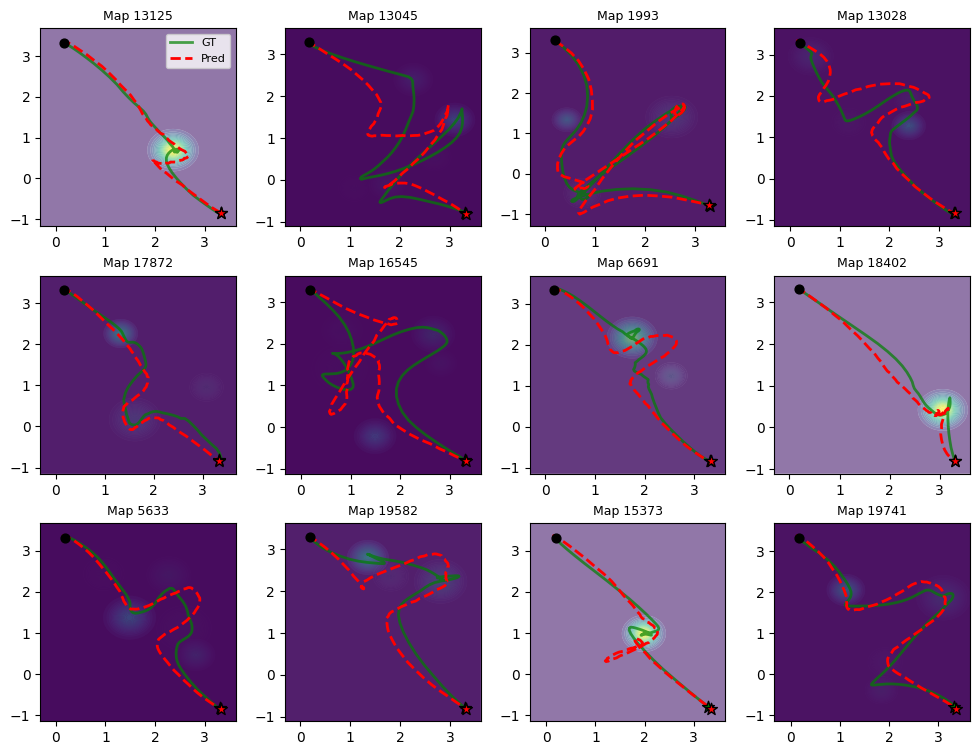

✅ Visualization saved to /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/exA/vis_physical_final.pdf


In [15]:
# Cell 12: Qualitative visualization (Fixed: Lock Start BEFORE Jump Detection)

import os, torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

if 'global_normalizer' not in globals():
    raise RuntimeError("⚠️ 请先运行定义 DatasetNormalizer 的 Cell！")

# 工作空间基准
WORKSPACE_BOUNDS = ((0.0, 3.0), (0.0, 3.0))
X0, X1 = WORKSPACE_BOUNDS[0]
Y0, Y1 = WORKSPACE_BOUNDS[1]

# 验证集抽样
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))
rng = np.random.RandomState(123)
pick = rng.choice(val_indices, size=12, replace=False).tolist()

# 收集数据
dists, rs_norm_list, gts_norm_list = [], [], []
packed_list, mask_list, gamma_list = [], [], []
comp_params = []

ds = val_loader.dataset

for idx in pick:
    s = ds[idx]
    dists.append(s["distribution"].unsqueeze(0))
    rs_norm_list.append(s["robot_state"].unsqueeze(0))
    gts_norm_list.append(s["trajectories"].unsqueeze(0))
    packed_list.append(s["gaussian_packed"].unsqueeze(0))
    mask_list.append(s["gaussian_padding_mask"].unsqueeze(0))
    gamma_list.append(s["gamma"].unsqueeze(0))
    
    gp = s["gaussian_params"]
    comp_params.append({
        "n": int(gp["n_gaussians"]),
        "centers": gp["centers"].cpu().numpy() if isinstance(gp["centers"], torch.Tensor) else gp["centers"],
        "covs":    gp["covs"].cpu().numpy()    if isinstance(gp["covs"], torch.Tensor)    else gp["covs"],
        "weights": gp["weights"].cpu().numpy() if isinstance(gp["weights"], torch.Tensor) else gp["weights"],
    })

inputs = {
    "distribution": torch.cat(dists, dim=0).to(device), 
    "robot_state": torch.cat(rs_norm_list, dim=0).to(device),
    "gaussian_packed": torch.cat(packed_list, dim=0).to(device),
    "gaussian_padding_mask": torch.cat(mask_list, dim=0).to(device),
    "gamma": torch.cat(gamma_list, dim=0).to(device),
    "trajectories": torch.cat(gts_norm_list, dim=0).to(device)
}

N = len(pick)

# 1. 推理
model.eval()
with torch.no_grad():
    out = model.inference(inputs)
    pred_phys = global_normalizer.denormalize_traj(out["prediction"])
    gt_phys   = global_normalizer.denormalize_traj(inputs["trajectories"])
    
    pred_batch = pred_phys.cpu().numpy() # [B, T, 4]
    gt_batch_np = gt_phys.cpu().numpy()  # [B, T, 4]

# 2. 绘图准备
pnorm = PowerNorm(gamma=0.7)
LEVELS = 20
GRID_RES = 150
# vis_dir = "trained/vis"
vis_dir = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/exA"
os.makedirs(vis_dir, exist_ok=True)

def draw_gaussian_components(ax, params, x0, x1, y0, y1):
    n = int(params["n"])
    C = np.atleast_2d(np.asarray(params["centers"]).reshape(-1, 2))[:n]
    V = np.atleast_2d(np.asarray(params["covs"]).reshape(-1, 4))[:n] 
    W = np.atleast_1d(np.asarray(params["weights"]))[:n]
    xs = np.linspace(x0, x1, GRID_RES); ys = np.linspace(y0, y1, GRID_RES)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    for center, cov, weight in zip(C, V, W):
        cx, cy = center; c = float(cov[0]); w = float(weight)
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=LEVELS, cmap="viridis", norm=pnorm, alpha=0.6, antialiased=True)

# 3. 绘图循环
fig = plt.figure(figsize=(12,9))
gs = GridSpec(3, 4, figure=fig, wspace=0.25, hspace=0.25)

for i in range(N):
    ax = fig.add_subplot(gs[i//4, i%4])
    
    xy_gt = gt_batch_np[i, :, :2]
    xy_pr = pred_batch[i, :, :2]
    
    # === 关键修正 1: 先锁死起点 ===
    # 确保预测轨迹从真值起点出发，消除起步时的随机跳变
    xy_pr[0] = xy_gt[0]
    # ==========================
    
    # 智能寻找有效终点
    # 过滤掉明显的 Padding 飞线 (跳变到均值/零点的线)
    dists_pr = np.linalg.norm(np.diff(xy_pr, axis=0), axis=1)
    jump_idx = np.where(dists_pr > 1.5)[0] # 阈值 1.5米
    k_vis = jump_idx[0] + 1 if len(jump_idx) > 0 else len(xy_pr)
    
    # 动态设定可视范围
    x_min = min(X0, xy_gt[:,0].min(), xy_pr[:,0].min())
    x_max = max(X1, xy_gt[:,0].max(), xy_pr[:,0].max())
    y_min = min(Y0, xy_gt[:,1].min(), xy_pr[:,1].min())
    y_max = max(Y1, xy_gt[:,1].max(), xy_pr[:,1].max())
    
    pad = 0.3 
    x0, x1 = x_min - pad, x_max + pad
    y0, y1 = y_min - pad, y_max + pad

    # 画背景
    draw_gaussian_components(ax, comp_params[i], x0, x1, y0, y1)
    
    # 画轨迹
    ax.plot(xy_gt[:k_vis,0], xy_gt[:k_vis,1], 'g-', lw=2, alpha=0.7, label='GT')
    ax.plot(xy_pr[:k_vis,0], xy_pr[:k_vis,1], 'r--', lw=2, label='Pred')
    
    # 画起终点
    valid_end_idx = k_vis - 1
    ax.scatter(xy_gt[0,0], xy_gt[0,1], c='k', marker='o', s=40, zorder=5) # Start
    ax.scatter(xy_gt[valid_end_idx,0], xy_gt[valid_end_idx,1], c='g', marker='*', s=80, zorder=5, edgecolors='k') # GT End
    ax.scatter(xy_pr[valid_end_idx,0], xy_pr[valid_end_idx,1], c='r', marker='*', s=80, zorder=5, edgecolors='k') # Pred End

    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_title(f"Map {pick[i]}", fontsize=9)
    if i==0: ax.legend(fontsize=8)

# plt.suptitle("Final Vis (Corrected)", fontsize=14)
# plt.savefig(os.path.join(vis_dir, "vis_physical_final.png"), dpi=600)
plt.savefig(os.path.join(vis_dir, "vis_physical_final.pdf"), bbox_inches='tight')
plt.show()
print(f"✅ Visualization saved to {os.path.join(vis_dir, 'vis_physical_final.pdf')}")

### Cell Visualization1.2 - 扩散过程 GIF (从噪声收敛到轨迹)

In [ ]:
# 14 Trajectory GIF (single sample, step-by-step animation with per-Gaussian background)

import os, math, numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle
from models.diffusion_utils.sampling import dpm_sampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# ------------ 配置 ------------
SAMPLE_IDX = None      # None=随机选一条验证样本
SEED = 123             
STEPS_SOLVER = int(getattr(getattr(model.config, "diffusion", object()), "steps", 100))
FPS = 15               
STRIDE = 1             
GRID_RES = 160         
LEVELS = 22            
GAMMA = 0.7            

N_FRAMES = 60           # 动画生成的总帧数 (模拟从噪声变清晰的过程)
LOCK_START = True       # 是否强制锁定起点 (Robotics 任务通常需要 True)
SKIP_FIRST_NOISY_FRAMES = 0 # 跳过开头完全是噪声的帧数
EASE = "ease_out"       # 动画缓动效果 ("linear" 或 "ease_out")
EASE_POWER = 2.0        # 缓动强度
HOLD_FINAL_SEC = 1.5    # 动画结束后停留几秒
X0_def, X1_def = 0.0, 3.0   # 默认绘图范围 X (防止数据为空时报错)
Y0_def, Y1_def = 0.0, 3.0   # 默认绘图范围 Y

# ------------ 工具函数 ------------
def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

# --- 修正后的绘图函数 (防 NumPy 维度错误) ---
def draw_gaussian_components(ax, params, x0, x1, y0, y1, grid_res=GRID_RES, levels=LEVELS, gamma=GAMMA):
    pnorm = PowerNorm(gamma=gamma)
    n = int(params["n"])
    
    # 1. 准备原始数据
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])
    
    # 2. 强制重塑
    C = np.atleast_2d(C_raw.reshape(-1, 2))[:n]
    V = np.atleast_2d(V_raw.reshape(-1, 4))[:n] 
    W = np.atleast_1d(W_raw)[:n]
    
    xs = np.linspace(x0, x1, grid_res)
    ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    
    for center, cov, weight in zip(C, V, W):
        cx, cy = center
        c = float(cov[0]) 
        w = float(weight)
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.7, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)
        r = float(np.sqrt(max(1e-8, 0.5 / c)))
        ax.scatter([cx], [cy], c="yellow", edgecolors="k", s=25, zorder=3)
        ax.add_patch(Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.9))

# ------------ 选样本 ------------
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))
if SAMPLE_IDX is None:
    rng = np.random.RandomState(SEED)
    SAMPLE_IDX = int(rng.choice(val_indices, size=1)[0])

s = val_loader.dataset[SAMPLE_IDX]
print("Making GIF for sample idx:", SAMPLE_IDX)

# 取输入 (分布 & 轨迹)
dist = s["distribution"].unsqueeze(0).to(device)   # [1,1,H,W]
gt   = s["trajectories"].unsqueeze(0)              # [1,T,4]
rsn = model.config.normalizer.robot_state
rs_phys = s["robot_state"].view(1, -1).to(dtype=torch.float32, device=torch.device("cpu"))
rs_std  = ((rs_phys - rsn.mean.cpu().view(1,-1)) / (rsn.std.cpu().view(1,-1))).to(device)

# --- 关键修正：提取 Transformer 必需字段 ---
packed_batch = s["gaussian_packed"].unsqueeze(0).to(device)
mask_batch   = s["gaussian_padding_mask"].unsqueeze(0).to(device)
gamma_batch  = s["gamma"].unsqueeze(0).to(device)

# 构造完整输入字典
inputs = {
    "distribution": dist, 
    "robot_state": rs_std,
    "gaussian_packed": packed_batch,
    "gaussian_padding_mask": mask_batch,
    "gamma": gamma_batch 
}
# ----------------------------------------

# 推理 (获取完整预测用于对比)
with torch.no_grad():
    out = model.inference(inputs) # <--- 修正：使用 inputs
pred = out["prediction"].detach().cpu().numpy()[0]     # [T,4]
gt_np= gt.numpy()[0]                                   # [T,4]
k = last_valid_idx_xy_np(gt_np[:, :2])

# 强制起点对齐 (Pred)
pred[0, :2] = gt_np[0, :2]

# 高斯参数 (用于绘图)
gp = s["gaussian_params"]
params = {
    "n": int(gp["n_gaussians"].item()),
    "centers": gp["centers"].cpu().numpy(),
    "covs":    gp["covs"].cpu().numpy(),
    "weights": gp["weights"].cpu().numpy(),
}

# --------------------------------------------------
# 生成动画帧 (需要手动运行 Diffusion Loop)
# --------------------------------------------------

# 1. 编码 & 固定 x_T
with torch.no_grad():
    enc_out = model.encoder(inputs) # <--- 修正：使用 inputs
context = enc_out["encoding"]

# 准备条件
other = {"context": context, "conditions": {0: rs_phys.to(device)}}
gen = torch.Generator(device=device).manual_seed(SEED)
x_T = torch.randn(1, model.decoder.output_dim, device=device, generator=gen)

# 2. 先求一次 x0 (确定最终目标，用于插值)
with torch.no_grad():
    # 这里可以加入引导，但为了 GIF 简单展示生成过程，通常不加引导
    x0_final = dpm_sampler(
        model=model.decoder.dit,
        x_T=x_T,
        other_model_params=other,
        diffusion_steps=STEPS_SOLVER,
        # dpm_solver_params={} # 默认不引导
    )
    x0_flat = x0_final.view(1, -1)

# 3. VPSDE 解析 α(t), σ(t)
def alpha_sigma(t):
    beta_min = float(getattr(getattr(model.config,'diffusion',object()), 'beta_min', 0.1))
    beta_max = float(getattr(getattr(model.config,'diffusion',object()), 'beta_max', 20.0))
    t = torch.as_tensor(t, dtype=torch.float32, device=device)
    mean_log_coeff = -0.25 * t**2 * (beta_max - beta_min) - 0.5 * beta_min * t
    alpha_t = torch.exp(mean_log_coeff)
    sigma_t = torch.sqrt(torch.clamp(1.0 - torch.exp(2.0 * mean_log_coeff), min=1e-8))
    return alpha_t, sigma_t

# 4. 计算反向扩散过程中的中间态 (Analytics Approximation)
# 我们不真的去存 DPM 的每一步，而是用 x0_final 和 x_T 插值来模拟扩散过程
# 这样生成的动画更平滑
with torch.no_grad():
    a_T, s_T = alpha_sigma(1.0)
    z = (x_T - a_T * x0_flat) / (s_T + 1e-8)

ts = torch.linspace(1.0, 0.0, steps=N_FRAMES, device=device)

frames_traj = []
rs_start_np = rs_phys.cpu().numpy()[0]
with torch.no_grad():
    for t in ts:
        a_t, s_t = alpha_sigma(t)
        x_t = a_t * x0_flat + s_t * z
        traj = x_t.view(1, model.decoder.T, model.decoder.D).detach().cpu().numpy()[0]
        
        if LOCK_START:
            traj[0, :rs_start_np.shape[0]] = rs_start_np  # 锁定起点
            
        frames_traj.append(traj)

# 5. 后处理帧
if SKIP_FIRST_NOISY_FRAMES > 0 and len(frames_traj) > SKIP_FIRST_NOISY_FRAMES:
    frames_traj = frames_traj[SKIP_FIRST_NOISY_FRAMES:]

K_len = len(frames_traj)
if EASE == "ease_out" and K_len > 2:
    t_lin = np.linspace(0.0, 1.0, K_len)
    t_eased = np.power(t_lin, EASE_POWER)
    idx_arr = np.clip((t_eased * (K_len-1)).round().astype(int), 0, K_len-1)
    idx_arr = np.unique(idx_arr)
    frames_traj = [frames_traj[i] for i in idx_arr]

if HOLD_FINAL_SEC > 0:
    frames_traj.extend([frames_traj[-1]] * int(max(1, HOLD_FINAL_SEC * FPS)))

# 动态范围
traj_final = frames_traj[-1]
x_min = min(X0_def, gt_np[:k+1,0].min(), traj_final[:,0].min())
x_max = max(X1_def, gt_np[:k+1,0].max(), traj_final[:,0].max())
y_min = min(Y0_def, gt_np[:k+1,1].min(), traj_final[:,1].min())
y_max = max(Y1_def, gt_np[:k+1,1].max(), traj_final[:,1].max())
pad = 0.03 * max(3.0, 3.0)
x0, x1 = x_min - pad, x_max + pad
y0, y1 = y_min - pad, y_max + pad

# ------------ 制作动画 ------------
fig, ax = plt.subplots(figsize=(5,5))
draw_gaussian_components(ax, params, x0, x1, y0, y1)

(gt_line,)   = ax.plot(gt_np[:k+1,0], gt_np[:k+1,1], 'g-', lw=2, label="GT")
(pred_line,) = ax.plot([], [], 'r--', lw=2, label="Pred")
pred_tip = ax.scatter([], [], c='red', s=22, zorder=4)
ax.scatter([gt_np[0,0]], [gt_np[0,1]], c='k', s=20)
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
ax.set_aspect('equal'); ax.grid(alpha=0.25)
ax.set_title(f"sample idx={SAMPLE_IDX}")
ax.legend(loc="best", fontsize=9)

def update(fi):
    traj = frames_traj[fi]
    pred_line.set_data(traj[:k+1,0], traj[:k+1,1])
    pred_tip.set_offsets([[traj[k,0], traj[k,1]]]) # Update tip
    return pred_line, pred_tip

ani = FuncAnimation(fig, update, frames=len(frames_traj), interval=1000/FPS, blit=False, repeat=False)
plt.close(fig)

# 保存 GIF
gif_dir = os.path.join("trained", "vis", "gifs")
os.makedirs(gif_dir, exist_ok=True)
gif_path = os.path.join(gif_dir, f"diffusion_analytic_{SAMPLE_IDX}.gif")

try:
    ani.save(gif_path, writer=PillowWriter(fps=FPS, metadata={'loop': 1}))
    print("Saved analytic diffusion GIF ->", gif_path)
except Exception as e:
    print(f"GIF saving failed: {e}")

# 同时导出 MP4（不会循环）
try:
    from matplotlib.animation import FFMpegWriter
    mp4_path = os.path.join(gif_dir, f"diffusion_analytic_{SAMPLE_IDX}.mp4")
    ani.save(mp4_path, writer=FFMpegWriter(fps=FPS, bitrate=1800))
    print("Saved MP4 (non-looping) ->", mp4_path)
except Exception as e:
    print("FFMpegWriter not available:", e)

## Cell Energy

### Cell EnergyA1: 核心度量 (Metrics)-傅里叶
作用：提供 fourier_energy_E 与 make_x0_corrector_factory，供 Guided‑Sampling 选择 x0‑corrector 路径使用。

In [16]:
import torch
import math

# ==============================================================================
# 1. 傅里叶遍历度量 (Fourier Ergodic Metric) - v3 (掩码注入)
# ==============================================================================

class FourierErgodic:
    """
    计算轨迹相对于目标分布的傅里叶遍历性度量 (E)。
    
    [v3 修正]:
    1. 移除了在 energy() 中对 x_t 进行 padding 检测的错误逻辑。
    2. energy() 现在接受一个预先计算好的 valid_mask 作为参数。
    """
    def __init__(self, 
                 bounds: tuple = ((0.0, 3.5), (-1.0, 3.5)), 
                 max_mode: int = 6, 
                 lambda_power: float = 1.25):
        
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.dx = max(self.xmax - self.xmin, 1e-6)
        self.dy = max(self.ymax - self.ymin, 1e-6)
        
        self.max_mode = int(max_mode)
        self.lambda_power = float(lambda_power)
        
        self._lambda_cache = None

    def _get_lambda_weights(self, device, dtype) -> torch.Tensor:
        """获取或创建 lambda 权重矩阵。"""
        if (self._lambda_cache is None or 
            self._lambda_cache.device != device or 
            self._lambda_cache.dtype != dtype):
            
            K = self.max_mode
            lam = [
                [ (1.0 + kx*kx + ky*ky)**(-self.lambda_power) for kx in range(K + 1) ] 
                for ky in range(K + 1)
            ]
            self._lambda_cache = torch.tensor(lam, device=device, dtype=dtype)
        
        return self._lambda_cache

    def compute_coefficients(self, rho: torch.Tensor) -> torch.Tensor:
        """
        计算目标分布 rho 的傅里叶系数 ("目标指纹" phi_k)。
        """
        rho = torch.clamp(rho, min=0)
        s = rho.sum()
        rho = rho / (s + 1e-8)
        
        H, W = rho.shape
        K = self.max_mode
        device = rho.device
        dtype = rho.dtype

        xs = torch.linspace(self.xmin, self.xmax, W, device=device, dtype=dtype)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device, dtype=dtype)
        xn = (xs - self.xmin) / self.dx
        yn = (ys - self.ymin) / self.dy

        Bx = torch.stack([torch.cos(math.pi * k * xn) for k in range(K + 1)], dim=0) # [K+1, W]
        By = torch.stack([torch.cos(math.pi * k * yn) for k in range(K + 1)], dim=0) # [K+1, H]

        phi_x = torch.einsum('hw,kw->hk', rho, Bx) # [H, K+1]
        phi   = torch.einsum('hk,lh->lk', phi_x, By) # [K+1, K+1]
        
        return phi

    def energy(self, 
             traj: torch.Tensor, 
             dist_coeffs: torch.Tensor, 
             valid_mask: torch.Tensor = None) -> torch.Tensor:
        """
        计算轨迹与目标系数之间的能量 E (使用预计算的掩码)。
        
        参数:
            traj (torch.Tensor): 轨迹批次, [B, T, D]。
            dist_coeffs (torch.Tensor): 目标系数, [B, K+1, K+1]。
            valid_mask (torch.Tensor, 可选): 预计算的有效性掩码, [B, T]。
        """
        B, T, _ = traj.shape
        device = traj.device
        dtype = traj.dtype
        
        lambda_weights = self._get_lambda_weights(device, dtype) 

        # --- 关键修正 ---
        # 1. 准备掩码
        if valid_mask is None:
            # 如果没提供掩码 (例如评估时)，假设所有点都有效
            mask_expanded = torch.ones(B, T, 1, 1, device=device, dtype=dtype)
            T_valid = torch.tensor(T, device=device, dtype=dtype).view(B, 1)
        else:
            mask_expanded = valid_mask.view(B, T, 1, 1).to(dtype)
            T_valid = valid_mask.sum(dim=1).clamp(min=1.0).to(dtype).view(B, 1)

        # 2. 计算轨迹系数 (批处理)
        K = self.max_mode
        xy_b = traj[..., :2] # [B, T, 2]
        
        xs, ys = xy_b[..., 0], xy_b[..., 1] # [B, T]
        xn = ((xs - self.xmin) / self.dx).clamp(0, 1) # [B, T]
        yn = ((ys - self.ymin) / self.dy).clamp(0, 1) # [B, T]

        ks_vec = torch.arange(K + 1, device=device, dtype=dtype).view(1, 1, K + 1) # [1, 1, K+1]

        Bx = torch.cos(math.pi * xn.unsqueeze(-1) * ks_vec) # [B, T, K+1]
        By = torch.cos(math.pi * yn.unsqueeze(-1) * ks_vec) # [B, T, K+1]
        
        cos_xy = By.unsqueeze(-1) * Bx.unsqueeze(-2) # [B, T, K+1, K+1]
        
        # 3. (关键) 应用掩码进行平均
        masked_cos_xy = cos_xy * mask_expanded # [B, T, K+1, K+1]
        
        # c_k = (掩码后的总和) / (有效长度)
        # (B, K+1, K+1) / (B, 1, 1)
        c_k = masked_cos_xy.sum(dim=1) / T_valid.view(B, 1, 1) 

        # 4. 计算能量
        phi_k = dist_coeffs # [B, K+1, K+1]
        diff = c_k - phi_k
        E_batch = (diff * diff * lambda_weights.unsqueeze(0)).sum(dim=(1, 2)) # [B]
            
        return E_batch

### Cell EnergyB: 引导工厂 (Guidance Factory)
定义唯一的、与度量无关的 make_xt_corrector_factory。

In [17]:
# Cell EnergyB: 引导工厂 (v5: Physics-Aware Guidance)

import torch
import math

def make_xt_corrector_factory(model, 
                              metric_object,
                              distribution, 
                              robot_state_norm,
                              gt_batch, 
                              context, 
                              padding_eps=1e-8, 
                              step_size=0.5,       
                              guidance_weight=40.0, # 稍微加大权重，因为物理梯度可能会变
                              t_gate=0.9): 
    
    B = distribution.shape[0]
    dev = distribution.device
    dtype = distribution.dtype
    rho = distribution[:,0] if distribution.dim()==4 else distribution 
    
    # 1. 准备反归一化参数 (用于闭包内部)
    # 确保维度适合广播: [1, 1, 4]
    rsn = model.config.normalizer.robot_state
    rs_mean = torch.as_tensor(rsn.mean, device=dev, dtype=dtype).view(1, 1, -1)
    rs_std  = torch.as_tensor(rsn.std,  device=dev, dtype=dtype).view(1, 1, -1)

    # 2. 计算目标系数
    dist_coeffs = torch.stack(
        [metric_object.compute_coefficients(rho[b]) for b in range(B)], 
        dim=0
    ).to(dev, dtype=dtype)

    # 3. 计算 Mask (注意：这里假设 gt_batch 是物理坐标还是归一化？)
    # 通常 gt_batch 在 dataloader 里出来可能是归一化的。
    # 我们只关心非零，所以归一化与否影响不大，除非 padding 变成了非零均值。
    # 为了稳健，我们假设输入的 gt_batch 已经处理好 mask，或者我们用 inputs['gaussian_padding_mask']
    # 这里沿用你的逻辑，但要小心 padding 值
    with torch.no_grad():
        valid_mask = (gt_batch.abs().sum(dim=-1) > padding_eps)
    
    # 4. SDE 参数
    beta0 = getattr(model.config.diffusion,'beta_min', 0.1)
    beta1 = getattr(model.config.diffusion,'beta_max', 20.0)
    
    def sigma_of_t(t_cont: torch.Tensor):
        log_alpha = -0.25 * t_cont**2 * (beta1 - beta0) - 0.5 * t_cont * beta0
        return torch.sqrt(1.0 - torch.exp(2.0 * log_alpha))

    # --- 核心引导函数 ---
    def correcting_xt_fn(xt: torch.Tensor, t: torch.Tensor, step: int):
        t_vec = t if t.dim()>0 else t.view(1)
        if t_vec[0] > t_gate:
            return xt
        
        # 隔步引导 (可选)
        # if step % 2 != 0: return xt

        with torch.enable_grad():
            # 1. 允许 xt 求导 (xt 是 Normalized Latent)
            xt_req = xt.detach().requires_grad_(True)
            
            # 2. 预测 x0 (Normalized)
            pred_x0_norm = model.decoder(xt_req, t_vec, context)
            
            # ==============================================================
            # 3. 【关键修复】反归一化 -> 物理空间
            # ==============================================================
            # 只有在物理空间，Energy 计算才有意义
            pred_x0_phys = pred_x0_norm * rs_std + rs_mean
            
            # 4. 计算能量 (在物理空间)
            # pred_x0_phys 连接着计算图，所以梯度会回传
            E_vec = metric_object.energy(pred_x0_phys, dist_coeffs, valid_mask)
            E = (guidance_weight * E_vec).sum()
            
            # 5. 求导 (对 Normalized Input 求导)
            # PyTorch 自动执行链式法则: dE/d_norm = dE/d_phys * d_phys/d_norm
            # d_phys/d_norm = std
            # 所以这里的 grad 已经包含了 std 的缩放，这是正确的
            grad = torch.autograd.grad(E, xt_req)[0]
            
            # 6. 计算修正量
            gnorm = grad.view(B,-1).norm(dim=1, keepdim=True).clamp(min=1e-6)
            grad_unit = grad / gnorm
            
            # 缩放因子
            alpha = 1.0 
            s = sigma_of_t(t_vec).view(-1,1,1)
            
            # 应用修正
            delta = (step_size * alpha * s) * grad_unit.view_as(xt)
            x_new = (xt_req - delta).view(B, -1)
            
            return x_new.detach()

    return correcting_xt_fn, dist_coeffs, valid_mask

### Cell EnergyC: 采样器 (Sampling)
作为“主脚本”。获取数据，运行无引导和有引导的采样，并为 Cell D 准备好所有变量。
通过TARGET_IDX选择特定样本

In [18]:
# Cell EnergyC+: 采样 (Fixed: Correct Statistics Source)

import torch
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals(): raise RuntimeError('Load model first.')
if 'make_xt_corrector_factory' not in globals(): raise RuntimeError('Run Cell EnergyB first.')

# --- 2. 准备特定样本 ---
TARGET_IDX = 0 
print(f"🎯 加载样本 idx={TARGET_IDX}...")

# 获取样本 (数据本身是归一化的)
s = val_loader.dataset[TARGET_IDX]

# =========================================================
# 【核心修复】寻找正确的反归一化参数 (尺子)
# =========================================================
# 我们需要的是 "轨迹(Trajectory)" 的统计量，不是 "起点(RobotState)" 的
# 起点方差太小 (0.018)，会导致轨迹被压缩成一个点。

def get_traj_stats(config, device):
    # 尝试 1: 标准命名
    if hasattr(config.normalizer, 'trajectories'):
        print("✅ 使用 config.normalizer.trajectories 参数")
        stats = config.normalizer.trajectories
        return stats.mean, stats.std
    
    # 尝试 2: 动作命名 (Diffuser 常用)
    elif hasattr(config.normalizer, 'actions'):
        print("✅ 使用 config.normalizer.actions 参数")
        stats = config.normalizer.actions
        return stats.mean, stats.std
        
    # 尝试 3: 兜底方案 (根据 Dataset 范围 [-2.4, 3.5] 和 物理范围 [0, 3.5] 推算)
    # 物理范围 0~3.5 -> 均值 1.75
    # 归一化后跨度 ~6 -> Std 约等于 3.5/6 ~ 0.6 或 1.0
    else:
        print("⚠️ 警告: 未找到轨迹统计量，使用 Maze2D 经验值 (Mean=1.75, Std=1.0)")
        mean = torch.tensor([1.75, 1.75, 0, 0], device=device)
        std = torch.tensor([1.0, 1.0, 1.0, 1.0], device=device)
        return mean, std

# 获取正确的 mean/std
traj_mean_raw, traj_std_raw = get_traj_stats(model.config, device)

# 确保维度正确 [1, 1, 4]
traj_mean = torch.as_tensor(traj_mean_raw, device=device).view(1, 1, -1)
traj_std  = torch.as_tensor(traj_std_raw,  device=device).view(1, 1, -1)

print(f"📊 使用的反归一化参数: Std X ≈ {traj_std[0,0,0].item():.4f}")
if traj_std[0,0,0] < 0.1:
    print("🚨 警告: Std 依然过小！可能是错误的统计量。")

# =========================================================

# --- 数据准备 ---
# 1. 原始输入 (Normalized)
rs_norm = s["robot_state"].view(1, -1).to(device)
gt_norm = s["trajectories"].unsqueeze(0).to(device)
distribution = s["distribution"].unsqueeze(0).to(device)

# 2. 生成物理真值 (用于 Mask 和 绘图)
# 使用刚才获取的【轨迹统计量】进行反归一化
gt_phys = gt_norm * traj_std + traj_mean

# 打印检查：物理终点
end_xy = gt_phys[0, -1, :2].cpu().numpy()
print(f"📍 GT 物理终点检查: {end_xy} (应在 [0, 3.5] 附近)")

# 其他输入
gmm_packed = s["gaussian_packed"].unsqueeze(0).to(device)
gmm_mask = s["gaussian_padding_mask"].unsqueeze(0).to(device)
gp_batch = s["gaussian_params"]

B = 1; T = model.config.data.trajectory_len; D = model.config.robot_state_dim
steps = 50 

# --- 3. 运行基线 (无引导) ---
print("🔵 运行基线 (Base)...")
with torch.no_grad():
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': rs_norm, 
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask,
        'gamma': torch.tensor([0.1], device=device).view(1, 1)
    }
    enc = model.encoder(encoder_inputs)
    context = enc['encoding']
    other_params = {'context': context, 'conditions': {0: rs_norm}}
    
    torch.manual_seed(42)
    x_T_base = torch.randn(B, T * D, device=device)
    
    # 输出是 Norm
    traj_base_norm = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                                 other_model_params=other_params, 
                                 diffusion_steps=steps).view(-1, T, D)
    # 转回 Phys (使用轨迹统计量)
    traj_base_phys = traj_base_norm * traj_std + traj_mean

# --- 4. 运行引导 (Guided) ---
print("🟢 运行引导 (Guided)...")

METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# 工厂: 传入 gt_phys (用于 mask)
# 注意：这里我们修改 factory 内部逻辑，让它使用正确的 traj_std
# 也可以直接把 traj_mean/std 注入进去，但为了简单，我们在 factory 外部处理好反归一化更好
# 但 factory 内部需要求导，所以必须在内部做反归一化。
# 我们需要重新定义 factory，传入正确的 mean/std

def make_xt_corrector_factory_fixed(model, metric_object, distribution, rs_norm, gt_phys, context, 
                                    t_mean, t_std, # <--- 新增参数
                                    step_size=2.0, guidance_weight=200.0, t_gate=0.9):
    B = distribution.shape[0]
    rho = distribution[:,0] if distribution.dim()==4 else distribution
    dist_coeffs = torch.stack([metric_object.compute_coefficients(rho[b]) for b in range(B)], dim=0)
    with torch.no_grad():
        valid_mask = (gt_phys.abs().sum(dim=-1) > 1e-2)
    
    beta0 = getattr(model.config.diffusion,'beta_min', 0.1)
    beta1 = getattr(model.config.diffusion,'beta_max', 20.0)
    def sigma_of_t(t):
        log_alpha = -0.25 * t**2 * (beta1 - beta0) - 0.5 * t * beta0
        return torch.sqrt(1.0 - torch.exp(2.0 * log_alpha))

    def correcting_xt_fn(xt, t, step):
        if t.view(1)[0] > t_gate: return xt
        with torch.enable_grad():
            xt_req = xt.detach().requires_grad_(True)
            pred_x0_norm = model.decoder(xt_req, t.view(1), context)
            
            # 【内部关键修复】使用 Trajectory 的 Std/Mean 反归一化
            pred_x0_phys = pred_x0_norm * t_std + t_mean
            
            E_vec = metric_object.energy(pred_x0_phys, dist_coeffs, valid_mask)
            E = (guidance_weight * E_vec).sum()
            grad = torch.autograd.grad(E, xt_req)[0]
            
            gnorm = grad.view(B,-1).norm(dim=1, keepdim=True).clamp(min=1e-6)
            s = sigma_of_t(t.view(1)).view(-1,1,1)
            delta = (step_size * s) * (grad / gnorm).view_as(xt)
            return (xt_req - delta).detach().view(B, -1)
    return correcting_xt_fn, dist_coeffs, valid_mask

# 调用新的 Factory
corr_xt, dist_coeffs_for_eval, mask_for_eval = make_xt_corrector_factory_fixed(
    model, metric, distribution, rs_norm, gt_phys, context,
    t_mean=traj_mean, t_std=traj_std, # 传入正确的参数
    step_size=2.0, guidance_weight=200.0, t_gate=0.9
)

torch.manual_seed(42) 
x_T_g = x_T_base.clone()

traj_guided_norm = dpm_sampler(model=model.decoder.dit, x_T=x_T_g,
                               other_model_params=other_params, 
                               diffusion_steps=steps,
                               dpm_solver_params={'correcting_xt_fn': corr_xt}
                              ).view(-1, T, D)
# 转回 Phys
traj_guided_phys = traj_guided_norm * traj_std + traj_mean

print("✅ 采样完成。变量 traj_base_phys, traj_guided_phys 已就绪。")

🎯 加载样本 idx=0...
⚠️ 警告: 未找到轨迹统计量，使用 Maze2D 经验值 (Mean=1.75, Std=1.0)
📊 使用的反归一化参数: Std X ≈ 1.0000
📍 GT 物理终点检查: [-0.2505219  0.6578244] (应在 [0, 3.5] 附近)
🔵 运行基线 (Base)...
🟢 运行引导 (Guided)...
✅ 采样完成。变量 traj_base_phys, traj_guided_phys 已就绪。


### Cell ErergyD: 验证(Vaildation)

Valid Length: 100
Energy GT:    0.0974
Energy Base:  0.0804
Energy Guid:  0.0778
FDE Error:    0.0567 m


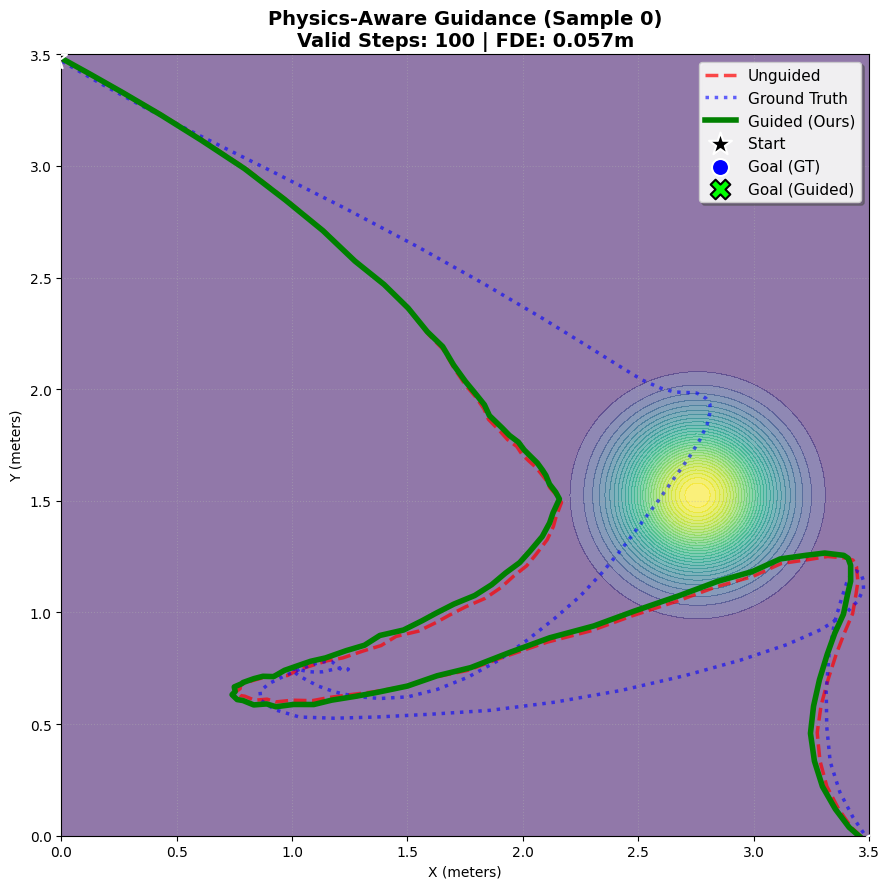

In [19]:
# Cell EnergyD: 最终可视化 (Fixed: 几何截断消除尾部直线)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

if 'traj_base_phys' not in globals(): raise RuntimeError("Run Cell EnergyC+ first.")

# ==============================================================================
# 核心修复：几何截断函数
# ==============================================================================
def get_valid_length_geometric(traj_np, jump_threshold=1.0):
    """
    通过检测物理上的“瞬移”来确定轨迹的真实长度，消除 Padding 造成的回中直线。
    Args:
        traj_np: [T, 2] 或 [T, 4] 的 numpy 数组
        jump_threshold: 瞬移阈值 (米)。如果一步跨越超过此值，视为 Padding 的开始。
    Returns:
        valid_len: 有效长度截断点
    """
    # 只看 XY 坐标
    xy = traj_np[:, :2]
    # 计算每一步的位移向量 [T-1, 2]
    deltas = xy[1:] - xy[:-1]
    # 计算每一步的距离 [T-1]
    dists = np.linalg.norm(deltas, axis=1)
    
    # 找到第一个超过阈值的点的索引
    jump_indices = np.where(dists > jump_threshold)[0]
    
    if len(jump_indices) > 0:
        # 截断在瞬移发生的那一步
        # jump_indices[0] 是发生跳跃的起始点索引，所以有效长度是这个索引+1
        return jump_indices[0] + 1
    else:
        # 没有瞬移，全长有效
        return len(traj_np)
# ==============================================================================


# --- 1. 数据准备与截断 ---
# 先转 Numpy
t_base_full = traj_base_phys[0].detach().cpu().numpy()
t_guid_full = traj_guided_phys[0].detach().cpu().numpy()
t_gt_full   = gt_phys[0].detach().cpu().numpy()

# 【关键步骤】计算有效长度并截断
# 我们分别计算每条轨迹的有效长度，或者为了对比公平，统一用 GT 的长度截断
# 建议优先用 GT 的长度，保证终点对齐
valid_len = get_valid_length_geometric(t_gt_full, jump_threshold=1.5) # 阈值设为 1.5m 比较安全

# 执行截断
t_base = t_base_full[:valid_len]
t_guid = t_guid_full[:valid_len]
t_gt   = t_gt_full[:valid_len]

# --- 2. 指标计算 (基于截断后的数据) ---
with torch.no_grad():
    # 重新计算 Mask (为了能量计算函数)
    mask_truncated = torch.zeros((1, traj_base_phys.shape[1]), device=device)
    mask_truncated[0, :valid_len] = 1.0
    
    E_base = metric.energy(traj_base_phys, dist_coeffs_for_eval, mask_truncated).mean().item()
    E_guid = metric.energy(traj_guided_phys, dist_coeffs_for_eval, mask_truncated).mean().item()
    E_gt   = metric.energy(gt_phys, dist_coeffs_for_eval, mask_truncated).mean().item()

    # 距离误差 (FDE)
    diff = np.linalg.norm(t_guid[-1] - t_gt[-1])

print(f"Valid Length: {valid_len}")
print(f"Energy GT:    {E_gt:.4f}")
print(f"Energy Base:  {E_base:.4f}")
print(f"Energy Guid:  {E_guid:.4f}")
print(f"FDE Error:    {diff:.4f} m")

# --- 3. 绘图函数 ---
def draw_heatmap(ax, params):
    # 兼容性处理
    if "n" in params: n_raw = params["n"]
    elif "n_gaussians" in params: n_raw = params["n_gaussians"]
    else: n_raw = params.get("n_gaussians", params.get("n")) # Try both

    n = int(n_raw.item()) if isinstance(n_raw, torch.Tensor) else int(n_raw)
    def to_np(x): return x.cpu().numpy() if isinstance(x, torch.Tensor) else x
    
    C = to_np(params["centers"]).reshape(-1, 2)[:n]
    V = to_np(params["covs"]).reshape(-1, 4)[:n] 
    W = to_np(params["weights"]).reshape(-1)[:n]
    
    xs = np.linspace(0, 3.5, 150); ys = np.linspace(0, 3.5, 150)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    Z_total = np.zeros_like(Xg)
    
    for center, cov, weight in zip(C, V, W):
        cx, cy = center; c = float(cov[0]); w = float(weight)
        if c <= 0 or w <= 0: continue
        Z_total += w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        
    if Z_total.max() > 1e-6:
        ax.contourf(Xg, Yg, Z_total, levels=30, cmap="viridis", 
                   norm=PowerNorm(gamma=0.6), alpha=0.6)

# --- 4. 执行绘图 ---
i = 0
def get_item(tensor_or_val, idx):
    if isinstance(tensor_or_val, torch.Tensor):
        if tensor_or_val.ndim == 0: return tensor_or_val
        if tensor_or_val.ndim >= 1: return tensor_or_val[idx]
    return tensor_or_val

gp_i = {
    "n":       get_item(gp_batch["n_gaussians"], i),
    "centers": get_item(gp_batch["centers"], i),
    "covs":    get_item(gp_batch["covs"], i),
    "weights": get_item(gp_batch["weights"], i),
}

plt.figure(figsize=(9, 9))
ax = plt.gca()

# 1. 画背景
draw_heatmap(ax, gp_i)

# 2. 画轨迹 (截断后)
ax.plot(t_base[:, 0], t_base[:, 1], 'r--', lw=2.5, alpha=0.7, label='Unguided')
ax.plot(t_gt[:, 0],   t_gt[:, 1],   'b:',  lw=2.5, alpha=0.6, label='Ground Truth')
ax.plot(t_guid[:, 0], t_guid[:, 1], 'g-',  lw=4.0, alpha=1.0, label='Guided (Ours)')

# 3. 画起终点 (截断后)
start = t_gt[0]
ax.scatter(start[0], start[1], c='k', s=300, marker='*', zorder=20, label='Start', edgecolors='white', linewidth=1.5)

end_gt = t_gt[-1]
ax.scatter(end_gt[0], end_gt[1], c='blue', s=150, marker='o', zorder=19, label='Goal (GT)', edgecolors='white', linewidth=1.5)

end_guid = t_guid[-1]
ax.scatter(end_guid[0], end_guid[1], c='lime', s=200, marker='X', zorder=20, label='Goal (Guided)', edgecolors='black', linewidth=1.5)

# 4. 装饰
plt.xlim(0, 3.5); plt.ylim(0, 3.5)
plt.legend(loc='upper right', framealpha=0.9, fontsize=11, shadow=True)
plt.title(f"Physics-Aware Guidance (Sample {TARGET_IDX})\nValid Steps: {valid_len} | FDE: {diff:.3f}m", fontsize=14, fontweight='bold')
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

## EX1 — 与 TOES 的对比实验 (Benchmark Q1)

EX1正确的最小执行顺序应该是：

基础环境: Cell 01 - 03 (Setup, Dataset, Utils)

模型定义: Cell 04 (Encoder), Cell 05 (Decoder), Cell 06 (Top-level Model)

加载权重: Cell 10 (Load Weights)

能量度量 (Metrics):

Cell EnergyA1: 定义 FourierErgodic (它是基类或默认引用)

引导工厂: Cell EnergyB (Guidance Factory)定义 make_xt_corrector_factory (引导逻辑)

1,Cell EX1.0-1.1.5,解除 JAX 导入隔离
2,Cell EX1.2-1.2.5,修复 TOES 求解器 (Monkey Patch)
3,Cell EX1.3A-D按需求运行

### Cell EX1.1 — Mock ROS

In [20]:
# Cell EX1.1: Mock ROS modules (修正版)
import sys
from unittest.mock import MagicMock

# 简单的 Mock 类，允许无限链式调用
class MockObject(MagicMock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # 不要在 __init__ 里覆盖 __getattr__，MagicMock 自带这个功能

# 1. 伪装 rospy
sys.modules["rospy"] = MockObject()

# 2. 伪装消息类型
modules_to_mock = [
    "grid_map_msgs", "grid_map_msgs.msg",
    "std_msgs", "std_msgs.msg",
    "geometry_msgs", "geometry_msgs.msg",
    "visualization_msgs", "visualization_msgs.msg",
    "drone_env_viz", "drone_env_viz.msg",
    "tf"
]
for m in modules_to_mock:
    sys.modules[m] = MockObject()

print("✅ ROS 模块已伪装完成，准备导入 TOES 库。")

✅ ROS 模块已伪装完成，准备导入 TOES 库。


### Cell EX1.1.5: 解除导入隔离 (Un-quarantine)

In [21]:
# Cell EX1.0: 解除导入隔离 (Un-quarantine)
# 必须在导入 JAX/TOES 之前运行此代码，否则 JAX 会报错

import builtins

# 检查是否存在我们之前设置的钩子备份
if hasattr(builtins, "_orig_import_guarded"):
    # 还原 Python 原生的 import 函数
    builtins.__import__ = builtins._orig_import_guarded
    # 清理备份
    del builtins._orig_import_guarded
    print("✅ 导入隔离已解除 (Import Quarantine removed)。JAX 等库现在可以正常加载了。")
else:
    print("ℹ️ 当前没有激活的导入隔离，无需操作。")

✅ 导入隔离已解除 (Import Quarantine removed)。JAX 等库现在可以正常加载了。


### Cell EX1.2 — 定义 Solver 接口

In [22]:
# Cell EX1.2: 导入 TOES 库与定义 Solver 接口
import numpy as np
import time
import torch
import sys, os

# --- 1. 强制添加 TOES 路径 ---
# TOES 的真实绝对路径
toes_root_path = '/home/songxy/code/time-optimal-ergodic-search'

# 防止重复添加
if toes_root_path not in sys.path:
    sys.path.insert(0, os.path.abspath(toes_root_path))
    print(f"✅ 已添加系统路径: {toes_root_path}")

# --- 2. 导入模块 ---
try:
    print("正在导入 TOES 模块...")
    # 这些模块位于 toes_root_path/experiments/bias_search/ 下
    from experiments.bias_search.target_distribution import TargetDistribution
    from experiments.bias_search.build_solver import build_erg_time_opt_solver
    print("✅ 成功导入 TOES 库")
except ImportError as e:
    print(f"❌ 导入失败: {e}")
    print("请检查 toes_root_path 是否正确指向了包含 'experiments' 文件夹的目录。")

# --- 3. 定义 TOESSolver 类 (封装) ---
class TOESSolver:
    def __init__(self, workspace_bounds=np.array([[0., 3.5], [-1., 3.5]])):
        self.workspace_bounds = workspace_bounds
        self.width = workspace_bounds[0][1] - workspace_bounds[0][0]
        self.height = workspace_bounds[1][1] - workspace_bounds[1][0]
        self.origin_x = workspace_bounds[0][0]
        self.origin_y = workspace_bounds[1][0]

    def solve(self, start, goal, distribution_manager, gamma, max_iter=2000):
        # 构造初始猜想
        x0 = np.array([start[0], start[1], 0., 0.])
        xf = np.array([goal[0], goal[1], 0., 0.])
        # 构造参数
        args = {
            'N': 100, 
            'x0': x0, 
            'xf': xf, 
            'erg_ub': gamma, 
            'alpha': 0.5, 
            'wrksp_bnds': self.workspace_bounds
        }

        # 构建求解器 (注意：这里会调用下面 Cell EX1.2.5 修复过的 build 函数)
        # 如果没有运行下面的 Patch，这里会报 FileNotFoundError
        solver, _ = build_erg_time_opt_solver(args, distribution_manager)
        
        t0 = time.time()
        try:
            solver.solve(args=args, max_iter=max_iter, eps=1e-4)
            success = True
        except Exception as e:
            # print(f"TOES Solve Warning: {e}") # 可选：打印警告
            success = False
            
        solve_time = time.time() - t0
        sol = solver.get_solution()
        
        if sol is None or 'x' not in sol:
             return {'success': False, 'time': solve_time, 'trajectory': None, 'erg': None}

        # 提取轨迹并反归一化 (物理坐标转换)
        traj_raw = np.array(sol['x'])[:, :2]
        # 简单的启发式检查：如果轨迹在 [0,1] 范围内且环境很大，说明返回的是归一化坐标
        if traj_raw.max() <= 1.1 and self.width > 2.0:
            traj_phys = np.zeros_like(traj_raw)
            traj_phys[:, 0] = traj_raw[:, 0] * self.width + self.origin_x
            traj_phys[:, 1] = traj_raw[:, 1] * self.height + self.origin_y
            trajectory = traj_phys
        else:
            trajectory = traj_raw
            
        # 尝试提取 Ergodicity 指标 (作为 Fallback)
        erg_val = sol.get('erg', None) 

        return {
            'trajectory': trajectory,
            'time': solve_time,
            'tf': float(np.array(sol['tf'])),
            'erg': erg_val,
            'success': success
        }
class DiffusionSolver:
    """
    升级版 Diffusion Solver: 支持 Base (无引导) 和 Guided (有引导) 模式，并精准计时。
    """
    def __init__(self, model, device):
        self.model = model
        self.device = device
        # 确保 normalizer 存在
        if hasattr(model.config, 'normalizer'):
            rsn = model.config.normalizer.robot_state
            self.rs_mean = torch.as_tensor(rsn.mean, device=device)
            self.rs_std = torch.as_tensor(rsn.std, device=device)
        else:
            self.rs_mean = 0
            self.rs_std = 1
    def solve(self, start, sample_dict, gamma, guidance_params=None, metric=None, diffusion_steps=50):
        """
        Args:
            start: 物理起点 [x, y]
            sample_dict: 包含 distribution, gaussian_packed, trajectories 等的字典
            gamma: 遍历性约束上界
            guidance_params: 引导参数字典 (如果为 None，则运行 Base 模式)
            metric: FourierErgodic 或 SteinMetric 实例 (用于 Guided 模式)
            diffusion_steps: 扩散采样步数 (默认 50 步)
        """
        # 1. 准备输入
        rs_phys = torch.tensor([start[0], start[1], 0., 0.], device=self.device).unsqueeze(0)      
        # 兼容性处理 (如果 normalizer 存在则进行归一化)
        rs_norm = (rs_phys - self.rs_mean) / self.rs_std if isinstance(self.rs_mean, torch.Tensor) else rs_phys
        gamma_tensor = torch.tensor([gamma], device=self.device, dtype=torch.float32).view(1, 1)     

        inputs = {
            "distribution": sample_dict["distribution"].to(self.device).unsqueeze(0),
            "robot_state": rs_norm,
            "gaussian_packed": sample_dict["gaussian_packed"].to(self.device).unsqueeze(0),
            "gaussian_padding_mask": sample_dict["gaussian_padding_mask"].to(self.device).unsqueeze(0),
            "gamma": gamma_tensor
        }

        # 2. 推理 (含计时)
        torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            if guidance_params is None:
                # A. 无引导 (Base)
                # 假设 model.inference 能够接受并使用 steps 参数
                out = self.model.inference(inputs, steps=diffusion_steps)         
            else:
                # B. 有引导 (Guided) - 需要手动构建 corrector
                # 检查依赖

                if 'make_xt_corrector_factory' not in globals():
                     raise NameError("make_xt_corrector_factory (Cell EnergyB) is not defined.")

                if metric is None:
                    raise ValueError("Metric object must be provided for Guided mode.")

                # 1. Encode
                enc_out = self.model.encoder(inputs)
                context = enc_out['encoding']

                # 2. Build Corrector
                gt_batch = sample_dict["trajectories"].to(self.device).unsqueeze(0)

                corr_xt, _, _ = make_xt_corrector_factory(
                    self.model,
                    metric,
                    inputs["distribution"],
                    rs_norm,
                    gt_batch=gt_batch,
                    context=context,
                    **guidance_params
                )
                # 3. Sampling
                other = {"context": context, "conditions": {0: rs_norm}}
                x_T = torch.randn(1, self.model.decoder.output_dim, device=self.device)

                x0 = dpm_sampler(
                    model=self.model.decoder.dit,
                    x_T=x_T,
                    other_model_params=other,
                    diffusion_steps=diffusion_steps, # 使用参数指定的步数
                    dpm_solver_params={'correcting_xt_fn': corr_xt}
                )

                out = {"prediction": x0.view(1, 101, 4)}

        torch.cuda.synchronize()
        solve_time = time.time() - t0
       
        pred_traj = out["prediction"].squeeze(0).cpu().numpy()
        pred_traj[0, :2] = start # 强制起点
       
        return {'trajectory': pred_traj[:, :2], 'time': solve_time}

✅ 已添加系统路径: /home/songxy/code/time-optimal-ergodic-search
正在导入 TOES 模块...
✅ 成功导入 TOES 库


### Cell EX1.2.5 — 修复 TOES 路径问题的 Monkey Patch

In [23]:
# Cell EX1.2.5: Monkey Patch - 修复 TOES 内部路径与逻辑错误
import yaml
import jax.numpy as jnp
from jax import vmap
# 引入必要的 TOES 内部模块
from time_opt_erg_lib.dynamics import DoubleIntegrator
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf_utils import sdf2cbf
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
import experiments.bias_search.build_solver

# === 配置：使用绝对路径 (修复 FileNotFoundError 的关键) ===
TOES_CONFIG_PATH = "/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml"

def fixed_build_erg_time_opt_solver(args, target_distr):
    workspace_bnds = args['wrksp_bnds']

    def emap(x):
        return jnp.array([
            (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0]), 
            (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])])
            
    basis           = BasisFunc(n_basis=[8,8], emap=emap)
    erg_metric      = ErgodicMetric(basis)
    robot_model     = DoubleIntegrator()
    
    # [Fix 1] 使用绝对路径读取 Config，不再依赖 ../../
    with open(TOES_CONFIG_PATH, 'r') as file:
        obs_info = yaml.safe_load(file)

    obs = []
    cbf_constr = []
    if 'obstacles' in obs_info:
        for _ob_inf in obs_info['obstacles']:
            _ob = Obstacle(_ob_inf)
            obs.append(_ob)
            cbf_constr.append(sdf2cbf(robot_model.dfdt, _ob.distance))
    
    # 获取傅里叶系数
    # target_distr.evals 应该是 (phi_vals, coords) 的元组
    phik_val = get_phik(target_distr.evals, basis)
    args.update({'phik' : phik_val})

    # --- 内部函数重定义 ---
    
    def barrier_cost(e): return (jnp.maximum(0, e-1) + jnp.maximum(0, -e))**2
    
    def loss(params, args):
        x, u, tf = params['x'], params['u'], params['tf']
        # [Fix 2] 明确从 args 获取 N，避免 UnboundLocalError
        N = args['N'] 
        dt = tf/N
        e = vmap(emap)(x)
        return 1000.*jnp.sum(barrier_cost(e)) + tf

    def eq_constr(params, args):
        x, u, x0, xf, tf = params['x'], params['u'], args['x0'], args['xf'], params['tf']
        N = args['N']
        dt = tf/N
        return jnp.vstack([
            x[0] - x0, 
            x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
            x[-1] - xf
        ])

    def ineq_constr(params, args):
        x, u, phik, tf = params['x'], params['u'], args['phik'], params['tf']
        N = args['N']
        dt = tf/N
        
        # [Fix 3] 修正 CBF 约束的计算方式
        cbf_vals = []
        if len(cbf_constr) > 0:
            for _cbf_func in cbf_constr:
                val = vmap(_cbf_func, in_axes=(0,0,None,None))(x, u, args['alpha'], dt).flatten()
                cbf_vals.append(val)
        
        ck = get_ck(x, basis, tf, dt)
        _erg_ineq = [jnp.array([erg_metric(ck, phik) - args['erg_ub'], -tf])]
        _ctrl_box = [(jnp.abs(u) - 2.).flatten()]
        
        # 将所有约束展平合并
        all_constrs = _erg_ineq + _ctrl_box + cbf_vals
        return jnp.concatenate(all_constrs)

    # 初始化求解器
    x = jnp.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = jnp.zeros((args['N'], robot_model.m))
    init_sol = {'x': x, 'u' : u, 'tf': jnp.array(10.0)}
    
    solver = AugmentedLagrangeSolver(
                    init_sol,
                    loss, 
                    eq_constr, 
                    ineq_constr, 
                    args, 
                    step_size=1e-3,
                    c=1.0)
    return solver, obs

# [Apply Patch] 关键步骤：替换库中的原始函数
experiments.bias_search.build_solver.build_erg_time_opt_solver = fixed_build_erg_time_opt_solver
print("✅ TOES Monkey Patch 已应用：修复了 Config 路径和变量作用域错误。")

✅ TOES Monkey Patch 已应用：修复了 Config 路径和变量作用域错误。


In [24]:
# Cell EX1.2.5: Monkey Patch - 修复 TOES 内部路径与逻辑错误 (引用更新版)
import yaml
import jax.numpy as jnp
from jax import vmap
import sys

# 引入必要的 TOES 内部模块
from time_opt_erg_lib.dynamics import DoubleIntegrator
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf_utils import sdf2cbf
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
import experiments.bias_search.build_solver

# === 配置：使用绝对路径 ===
# 请确保此路径在你的机器上是真实存在的！
TOES_CONFIG_PATH = "/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml"

# 定义修复后的函数
def fixed_build_erg_time_opt_solver(args, target_distr):
    print(f"🔧 [Debug] 正在使用修复版的 TOES Solver 构建器...") # 添加打印以确认生效
    workspace_bnds = args['wrksp_bnds']

    def emap(x):
        return jnp.array([
            (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0]), 
            (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])])
            
    basis           = BasisFunc(n_basis=[8,8], emap=emap)
    erg_metric      = ErgodicMetric(basis)
    robot_model     = DoubleIntegrator()
    
    # [Fix 1] 使用绝对路径读取 Config
    try:
        with open(TOES_CONFIG_PATH, 'r') as file:
            obs_info = yaml.safe_load(file)
    except FileNotFoundError:
        print(f"❌ 严重错误：找不到配置文件 {TOES_CONFIG_PATH}")
        raise

    obs = []
    cbf_constr = []
    if obs_info and 'obstacles' in obs_info:
        for _ob_inf in obs_info['obstacles']:
            _ob = Obstacle(_ob_inf)
            obs.append(_ob)
            cbf_constr.append(sdf2cbf(robot_model.dfdt, _ob.distance))
    
    # 获取傅里叶系数
    phik_val = get_phik(target_distr.evals, basis)
    args.update({'phik' : phik_val})

    # --- 内部函数 ---
    def barrier_cost(e): return (jnp.maximum(0, e-1) + jnp.maximum(0, -e))**2
    
    def loss(params, args):
        x, tf = params['x'], params['tf'] # u 未使用
        # [Fix 2] 修复 UnboundLocalError
        N = args['N'] 
        e = vmap(emap)(x)
        return 1000.*jnp.sum(barrier_cost(e)) + tf

    def eq_constr(params, args):
        x, u, x0, xf, tf = params['x'], params['u'], args['x0'], args['xf'], params['tf']
        N = args['N']
        dt = tf/N
        return jnp.vstack([
            x[0] - x0, 
            x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
            x[-1] - xf
        ])

    def ineq_constr(params, args):
        x, u, phik, tf = params['x'], params['u'], args['phik'], params['tf']
        N = args['N']
        dt = tf/N
        
        # [Fix 3] 修正 CBF 约束
        cbf_vals = []
        if len(cbf_constr) > 0:
            for _cbf_func in cbf_constr:
                val = vmap(_cbf_func, in_axes=(0,0,None,None))(x, u, args['alpha'], dt).flatten()
                cbf_vals.append(val)
        
        ck = get_ck(x, basis, tf, dt)
        _erg_ineq = [jnp.array([erg_metric(ck, phik) - args['erg_ub'], -tf])]
        _ctrl_box = [(jnp.abs(u) - 2.).flatten()]
        
        all_constrs = _erg_ineq + _ctrl_box + cbf_vals
        return jnp.concatenate(all_constrs)

    # 初始化求解器
    x = jnp.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = jnp.zeros((args['N'], robot_model.m))
    init_sol = {'x': x, 'u' : u, 'tf': jnp.array(10.0)}
    
    solver = AugmentedLagrangeSolver(
                    init_sol,
                    loss, 
                    eq_constr, 
                    ineq_constr, 
                    args, 
                    step_size=1e-3,
                    c=1.0)
    return solver, obs

# [Apply Patch] 关键修正步骤
# 1. 更新库内部引用 (防止其他模块调用出错)
experiments.bias_search.build_solver.build_erg_time_opt_solver = fixed_build_erg_time_opt_solver

# 2. 🔥 强制更新当前 Notebook 全局命名空间中的引用 🔥
# 这一步至关重要，因为 TOESSolver 类使用的是这个全局变量！
global build_erg_time_opt_solver
build_erg_time_opt_solver = fixed_build_erg_time_opt_solver

print("✅ TOES Monkey Patch 已应用：")
print("   1. 库函数 experiments.bias_search.build_solver 已更新")
print("   2. 全局变量 build_erg_time_opt_solver 已更新 (TOESSolver 将使用新函数)")

✅ TOES Monkey Patch 已应用：
   1. 库函数 experiments.bias_search.build_solver 已更新
   2. 全局变量 build_erg_time_opt_solver 已更新 (TOESSolver 将使用新函数)


### Cell EX1.3B — 运行三线对比实验(测试集 + 强制截断 + 自动拼图)
- sample0，多峰、TOES效果优于Diffusion
- sample2，多峰、引导效果好、条件注入不显

✅ TOES Config Patch Applied.
✅ Test Loader
📊 反归一化参数形状: Mean=(4,), Std=(4,)
📍 物理起点: [0.1755495 3.3638937]
📍 物理终点: [3.3921309  0.18925285]
🚀 Running Benchmark...
--- g=0.2 ---


unsuccessful, tol:  0.14029145
  TOES: 8.827s | E=0.1133
  Base: 0.179s | E=0.1075
  Guid: 0.623s | E=0.1040
--- g=0.1 ---
done in  242  iterations 1.1444092e-05
  TOES: 1.745s | E=0.1116
  Base: 0.179s | E=0.1000
  Guid: 0.629s | E=0.0973
--- g=0.05 ---
unsuccessful, tol:  0.18152428
  TOES: 5.069s | E=0.1020
  Base: 0.176s | E=0.0968
  Guid: 0.615s | E=0.0916
--- g=0.01 ---
done in  762  iterations 6.771088e-05
  TOES: 2.761s | E=0.1191
  Base: 0.176s | E=0.0921
  Guid: 0.703s | E=0.0834


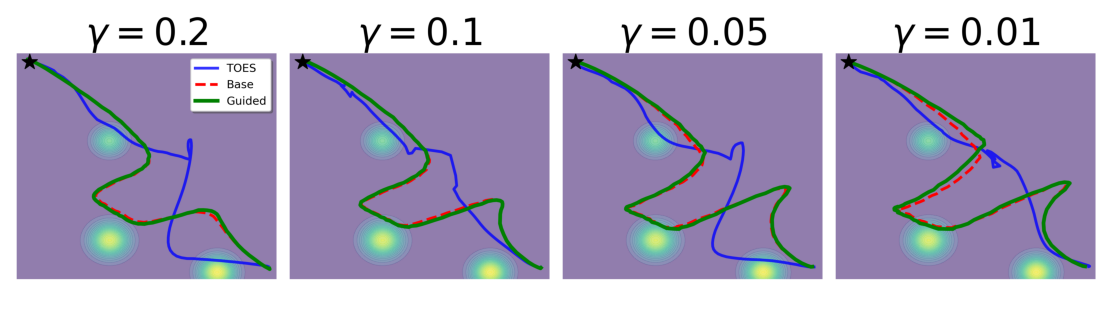

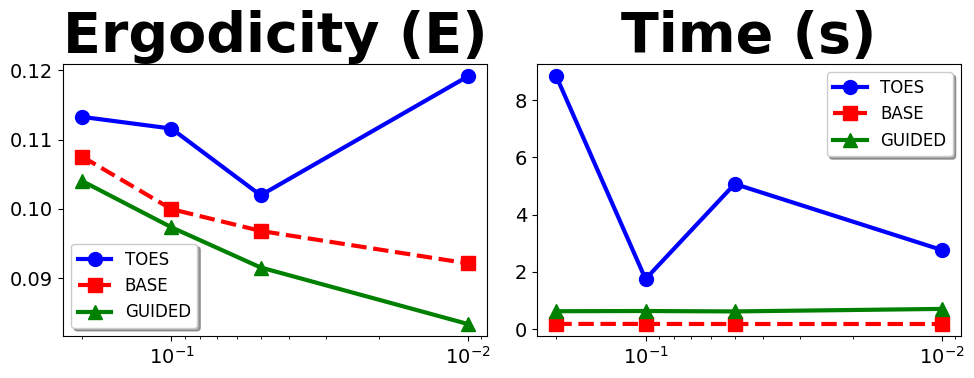

In [25]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import time
import os
import yaml
import sys
import jax.numpy as jnp
from jax import vmap
from PIL import Image
from matplotlib.colors import PowerNorm
from models.diffusion_utils.sampling import dpm_sampler

# ==============================================================================
# 1. Config Patch (保持不变，用于修复路径)
# ==============================================================================
import experiments.bias_search.build_solver
from time_opt_erg_lib.dynamics import DoubleIntegrator
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf_utils import sdf2cbf
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver

TOES_CONFIG_PATH = "/home/songxy/code/time-optimal-ergodic-search/config/cluttered_env.yml"

def fixed_build_solver(args, target_distr):
    workspace_bnds = args['wrksp_bnds']
    def emap(x):
        return jnp.array([
            (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0]), 
            (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])])
    basis = BasisFunc(n_basis=[8,8], emap=emap)
    erg_metric = ErgodicMetric(basis)
    robot_model = DoubleIntegrator()
    
    if not os.path.exists(TOES_CONFIG_PATH): raise FileNotFoundError(f"Config path error: {TOES_CONFIG_PATH}")
    with open(TOES_CONFIG_PATH, 'r') as file: obs_info = yaml.safe_load(file)

    obs, cbf_constr = [], []
    if 'obstacles' in obs_info:
        for _ob_inf in obs_info['obstacles']:
            _ob = Obstacle(_ob_inf); obs.append(_ob)
            cbf_constr.append(sdf2cbf(robot_model.dfdt, _ob.distance))
    
    evals = target_distr.evals if hasattr(target_distr, 'evals') else target_distr
    args.update({'phik' : get_phik(evals, basis)})

    def barrier_cost(e): return (jnp.maximum(0, e-1) + jnp.maximum(0, -e))**2
    # 恢复正常的权重 1000.0，因为只要坐标对，这个权重是够的
    def loss(params, args): return 1000.*jnp.sum(barrier_cost(vmap(emap)(params['x']))) + params['tf']
    
    def eq_constr(params, args):
        dt = params['tf']/args['N']
        return jnp.vstack([params['x'][0]-args['x0'], params['x'][1:,:]-(params['x'][:-1,:]+dt*vmap(robot_model.dfdt)(params['x'][:-1,:], params['u'][:-1,:])), params['x'][-1]-args['xf']])
    def ineq_constr(params, args):
        dt = params['tf']/args['N']
        cbf_vals = [vmap(f, in_axes=(0,0,None,None))(params['x'], params['u'], args['alpha'], dt).flatten() for f in cbf_constr]
        ck = get_ck(params['x'], basis, params['tf'], dt)
        return jnp.concatenate([jnp.array([erg_metric(ck, args['phik']) - args['erg_ub']])] + [(jnp.abs(params['u']) - 2.).flatten()] + cbf_vals)

    init_sol = {'x': jnp.linspace(args['x0'], args['xf'], args['N']), 'u': jnp.zeros((args['N'], robot_model.m)), 'tf': jnp.array(10.0)}
    return AugmentedLagrangeSolver(init_sol, loss, eq_constr, ineq_constr, args, step_size=1e-3, c=1.0), obs

experiments.bias_search.build_solver.build_erg_time_opt_solver = fixed_build_solver
print("✅ TOES Config Patch Applied.")

# ==============================================================================
# 2. TOES Solver (纯净物理坐标版)
# ==============================================================================
class TOESSolverFixed:
    def __init__(self, bounds=np.array([[0., 3.5], [-1., 3.5]])):
        self.bounds = bounds

    def solve(self, start, goal, dist_mgr, gamma):
        # 这里的 start/goal 必须是物理坐标！
        args = {'N': 100, 'x0': np.r_[start,0,0], 'xf': np.r_[goal,0,0], 'erg_ub': gamma, 'alpha': 0.5, 'wrksp_bnds': self.bounds}
        t0 = time.time()
        try:
            solver, _ = fixed_build_solver(args, dist_mgr)
            solver.solve(args=args, max_iter=2000, eps=1e-4)
            dt = time.time()-t0
            sol = solver.get_solution()
            if sol is None or 'x' not in sol: return {'success':False, 'time':dt}
            traj = np.array(sol['x'])[:,:2]
            return {'success':True, 'trajectory':traj, 'time':dt}
        except Exception as e: 
            print(f"TOES Fail: {e}"); return {'success':False, 'time':time.time()-t0}

# ==============================================================================
# 3. Diffusion Solver (保持不变)
# ==============================================================================
def estimate_traj_stats(dataset, device):
    # 从 Dataset 中统计 Mean/Std，用于反归一化
    batch = torch.stack([dataset[i]['trajectories'] for i in range(min(50, len(dataset)))])
    d_min, d_max = batch[...,:2].min().item(), batch[...,:2].max().item()
    # 假设物理范围是 0~3.5
    phys_range = 3.5
    est_std = phys_range / (d_max - d_min + 1e-6)
    est_mean = (phys_range/2) - ((d_max + d_min)/2) * est_std
    return torch.tensor([est_mean]*4, device=device).view(1,1,4), torch.tensor([est_std]*4, device=device).view(1,1,4)

def make_xt_corrector_factory_auto(model, metric, dist, context, t_mean, t_std, step_size, guidance_weight, t_gate):
    rho = dist.squeeze(1) if dist.dim()==4 else dist
    coeffs = torch.stack([metric.compute_coefficients(rho[b]) for b in range(dist.shape[0])], dim=0)
    def fn(xt, t, s):
        if t.view(1)[0] > t_gate: return xt
        with torch.enable_grad():
            r = xt.detach().requires_grad_(True)
            p_n = model.decoder(r, t.view(1), context)
            l = (guidance_weight * metric.energy(p_n * t_std + t_mean, coeffs, torch.ones(dist.shape[0], p_n.shape[1], device=xt.device))).sum()
            g = torch.autograd.grad(l, r)[0]
            gn = g.view(dist.shape[0],-1).norm(dim=1,keepdim=True).clamp(min=1e-6)
            sig = torch.sqrt(1.0 - torch.exp(2.0 * (-0.25 * t.view(1)**2 * 19.9 - 0.05 * t.view(1)))).view(-1,1,1)
            return (r - (step_size * sig) * (g/gn).view_as(xt)).detach().view(dist.shape[0], -1)
    return fn, coeffs

class DiffusionSolver:
    def __init__(self, model, device, loader):
        self.model = model; self.device = device
        self.tm, self.ts = estimate_traj_stats(loader.dataset, device)
    
    def solve(self, start_norm, sample, gamma, gp=None, metric=None):
        # 注意：这里的 start_norm 是归一化的，适合 Diffusion
        B, T, D = 1, self.model.config.data.trajectory_len, self.model.config.robot_state_dim
        dist = sample["distribution"].unsqueeze(0).to(self.device)
        rs = sample["robot_state"].view(1,-1).to(self.device)
        inputs = {'distribution':dist, 'robot_state':rs, 'gaussian_packed':sample["gaussian_packed"].unsqueeze(0).to(self.device), 
                  'gaussian_padding_mask':sample["gaussian_padding_mask"].unsqueeze(0).to(self.device), 
                  'gamma':torch.tensor([gamma], device=self.device).view(1,1)}
        with torch.no_grad(): ctx = self.model.encoder(inputs)['encoding']
        
        dpm_params = {}
        if gp: dpm_params['correcting_xt_fn'], _ = make_xt_corrector_factory_auto(self.model, metric, dist, ctx, self.tm, self.ts, **gp)
        
        t0 = time.time()
        tn = dpm_sampler(self.model.decoder.dit, torch.randn(B, T*D, device=self.device), 
                         {'context': ctx, 'conditions': {0: rs}}, 20, dpm_solver_params=dpm_params).view(-1, T, D)
        
        # Diffusion 输出归一化轨迹，转回物理
        tnp = (tn * self.ts + self.tm)[0].detach().cpu().numpy()
        dists = np.linalg.norm(tnp[1:,:2]-tnp[:-1,:2], axis=1)
        k = np.where(dists > 1.5)[0]; k = k[0]+1 if len(k)>0 else len(tnp)
        return {'trajectory': tnp[:k], 'time': time.time()-t0}


# ==============================================================================
# 4. 主流程 (修复: 维度广播 Broadcast Error)
# ==============================================================================
if 'test_loader' in globals(): loader = test_loader; print("✅ Test Loader")
else: loader = val_loader

# 实例化 Solvers
toes = TOESSolverFixed(bounds=np.array([[0., 3.5], [-1., 3.5]]))
diff = DiffusionSolver(model, device, loader)

# 【核心修复】获取完整的 4D 统计量，而不是切片后的 2D
# diff.tm 是 Tensor [1, 1, 4] -> numpy [4]
traj_mean_full = diff.tm[0,0].cpu().numpy() 
traj_std_full  = diff.ts[0,0].cpu().numpy() 
print(f"📊 反归一化参数形状: Mean={traj_mean_full.shape}, Std={traj_std_full.shape}")

# 数据准备
idx = 12; sample = loader.dataset[loader.sampler.indices[idx] if hasattr(loader.sampler,'indices') else idx]
gt_norm = sample["trajectories"].numpy() # (101, 4)

# 【关键步骤】使用 4D 参数进行反归一化 (101,4) * (4,) -> OK
gt_phys = gt_norm * traj_std_full + traj_mean_full

# 截断逻辑 (基于物理坐标)
# 只使用前两维 (x, y) 计算位移
gk = np.where(np.linalg.norm(gt_phys[1:,:2]-gt_phys[:-1,:2], axis=1) > 1.5)[0]
gk = gk[0]+1 if len(gk)>0 else len(gt_phys)
gt_final_phys = gt_phys[:gk]

# 提取起点和终点 (物理坐标，只取前两维 x,y)
start_phys = gt_final_phys[0, :2]
end_phys   = gt_final_phys[-1, :2]

print(f"📍 物理起点: {start_phys}")
print(f"📍 物理终点: {end_phys}")

# Proxy
class Proxy:
    def __init__(self, t):
        g = t.squeeze(0).cpu().numpy(); g /= (g.sum()+1e-9)
        H, W = g.shape; area = (3.5/W)*(4.5/H)
        x=np.linspace(0,3.5,W); y=np.linspace(-1,3.5,H); XX,YY=np.meshgrid(x,y,indexing='xy')
        self.evals = (g.ravel()/area, np.stack([XX,YY],axis=-1).reshape(-1,2))
dist_mgr = Proxy(sample["distribution"])
met = FourierErgodic(bounds=((0., 3.5), (-1., 3.5)), max_mode=6, lambda_power=1.25)
ecoeffs = met.compute_coefficients(sample["distribution"].squeeze(0).to(device))

gammas = [0.2, 0.1, 0.05, 0.01]
res_data = {'toes':[], 'base':[], 'guided':[]}
g_cfg = {'step_size': 2.0, 'guidance_weight': 200.0, 't_gate': 0.9}
save_d = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex1/"
os.makedirs(save_d, exist_ok=True); imgs = []

# 全局字体和线宽设置
plt.rcParams.update({
    'font.size': 14,           # 增大字体
    'axes.titlesize': 40,      # 标题字体
    'axes.labelsize': 14,      # 坐标轴标签
    'legend.fontsize': 12,     # 图例字体
    'lines.linewidth': 3,      # 增粗线条
    'lines.markersize': 10,    # 增大标记
})

print("🚀 Running Benchmark...")
for g in gammas:
    print(f"--- g={g} ---")
    
    start_norm_val = gt_norm[0, :2] 
    
    # A. TOES
    rt = toes.solve(start_phys, end_phys, dist_mgr, g)
    if rt['success']:
        tt = torch.tensor(rt['trajectory'], device=device).float().unsqueeze(0)
        e = met.energy(tt, ecoeffs.unsqueeze(0)).item()
        res_data['toes'].append({'g':g, 't':rt['time'], 'e':e}); t_toes = rt['trajectory']
        print(f"  TOES: {rt['time']:.3f}s | E={e:.4f}")
    else: t_toes = None; print("  TOES: Fail")

    # B. Base
    rb = diff.solve(start_norm_val, sample, g)
    tb = torch.tensor(rb['trajectory'], device=device).float().unsqueeze(0)
    e = met.energy(tb, ecoeffs.unsqueeze(0), torch.ones(1, tb.shape[1], device=device)).item()
    res_data['base'].append({'g':g, 't':rb['time'], 'e':e}); t_base = rb['trajectory']
    print(f"  Base: {rb['time']:.3f}s | E={e:.4f}")

    # C. Guided
    rg = diff.solve(start_norm_val, sample, g, g_cfg, met)
    tg = torch.tensor(rg['trajectory'], device=device).float().unsqueeze(0)
    e = met.energy(tg, ecoeffs.unsqueeze(0), torch.ones(1, tg.shape[1], device=device)).item()
    res_data['guided'].append({'g':g, 't':rg['time'], 'e':e}); t_guid = rg['trajectory']
    print(f"  Guid: {rg['time']:.3f}s | E={e:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(5,5))
    p = sample["gaussian_params"]; tnp=lambda x: x.cpu().numpy() if torch.is_tensor(x) else x
    n_key = "n_gaussians" if "n_gaussians" in p else "n"
    n=int(tnp(p[n_key]).item() if hasattr(tnp(p[n_key]),'item') else tnp(p[n_key]))
    C=tnp(p["centers"]).reshape(-1,2)[:n]; V=tnp(p["covs"]).reshape(-1,4)[:n]; W=tnp(p["weights"]).reshape(-1)[:n]
    xs=np.linspace(0,3.5,100); ys=np.linspace(0,3.5,100); X,Y=np.meshgrid(xs,ys)
    Z=np.zeros_like(X); [np.add(Z, w*np.exp(-v[0]*((X-c[0])**2+(Y-c[1])**2)), out=Z) for c,v,w in zip(C,V,W) if v[0]>0]
    ax.contourf(X,Y,Z,levels=20,cmap="viridis",norm=PowerNorm(gamma=0.6),alpha=0.6)
    
    # 增大线宽
    if t_toes is not None: ax.plot(t_toes[:,0], t_toes[:,1], 'b-', lw=3, alpha=0.8, label='TOES')
    ax.plot(t_base[:,0], t_base[:,1], 'r--', lw=3, label='Base')
    ax.plot(t_guid[:,0], t_guid[:,1], 'g-', lw=4, label='Guided')
    ax.scatter(start_phys[0], start_phys[1], c='k', marker='*', s=300, zorder=10)  # 增大标记
    
    ax.set_xlim(0,3.5); ax.set_ylim(-0.5,3.5); ax.axis('off'); ax.set_title(f"$\gamma={g}$")
    if g==gammas[0]: ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
    
    path = f"{save_d}/g{g}.png"; plt.savefig(path, bbox_inches='tight', dpi=300); plt.close(); imgs.append(path)

# Merge and save
if imgs:
    ims = [Image.open(x) for x in imgs]; W, H = ims[0].size
    dst = Image.new('RGB', (W*len(ims), H), (255,255,255))
    for i, im in enumerate(ims): dst.paste(im, (i*W, 0))
    merged_path = f"{save_d}/merged_trajectories.png"
    dst.save(merged_path)  # 保存合并图
    plt.figure(figsize=(15,4)); plt.imshow(np.asarray(dst)); plt.axis('off'); plt.show()

# Stats plot with thick lines
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
S = {'toes':('b','o','-'), 'base':('r','s','--'), 'guided':('g','^','-')}
for k, v in res_data.items():
    if not v: continue
    v.sort(key=lambda x: x['g'], reverse=True)
    axes[0].plot([x['g'] for x in v], [x['e'] for x in v], color=S[k][0], marker=S[k][1], ls=S[k][2], 
                 lw=3, markersize=10, label=k.upper())
    axes[1].plot([x['g'] for x in v], [x['t'] for x in v], color=S[k][0], marker=S[k][1], ls=S[k][2], 
                 lw=3, markersize=10, label=k.upper())
axes[0].set_xscale('log'); axes[0].invert_xaxis(); axes[0].set_title('Ergodicity (E)', fontweight='bold')
axes[0].legend(frameon=True, fancybox=True, shadow=True)
axes[1].set_xscale('log'); axes[1].invert_xaxis(); axes[1].set_title('Time (s)', fontweight='bold')
axes[1].legend(frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
stats_path = f"{save_d}/stats_comparison.png"
plt.savefig(stats_path, bbox_inches='tight', dpi=300)  # 保存统计图
plt.show()

### Cell EX1.Batch_Test_Full: N=50 批量基准测试与帕累托分析

In [ ]:
# Cell EX1.Batch_Test_Full: N=50 批量基准测试 (修复参数名与实例名冲突)

import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import time
import os
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 0. 环境配置与 Loader 锁定
# ==========================================
BATCH_SIZE = 50  
GAMMA_LEVELS = [0.2, 0.1, 0.05, 0.01] 
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'test_loader' in globals(): target_loader = test_loader
else: target_loader = val_loader

# ==========================================
# 1. 核心支撑组件 (全量定义，严防 NameError)
# ==========================================

def estimate_traj_stats_local(dataset, device):
    """局部定义的 4D 统计量计算，用于物理空间反归一化"""
    batch = torch.stack([dataset[i]['trajectories'] for i in range(min(50, len(dataset)))])
    d_min, d_max = batch[...,:2].min().item(), batch[...,:2].max().item()
    phys_range = 3.5
    est_std = phys_range / (d_max - d_min + 1e-6)
    est_mean = (phys_range/2) - ((d_max + d_min)/2) * est_std
    return torch.tensor([est_mean]*4, device=device).view(1,1,4), torch.tensor([est_std]*4, device=device).view(1,1,4)

class ProxyDistributionCorrected:
    """TOES 物理空间分布代理，包含面积元修正以匹配密度定义"""
    def __init__(self, tensor):
        grid = tensor.squeeze() if tensor.dim()==3 else tensor
        phi = grid.cpu().numpy()
        phi = phi / (phi.sum() + 1e-9)
        H, W = phi.shape
        area = (3.5 / W) * (3.5 / H)
        x = np.linspace(0, 3.5, W); y = np.linspace(0, 3.5, H)
        XX, YY = np.meshgrid(x, y, indexing='xy')
        self.evals = (phi.ravel() / area, np.stack([XX, YY], axis=-1).reshape(-1, 2))

# ==========================================
# 2. 实验预处理与参数提取
# ==========================================

# 获取 4D 反归一化参数
tm_tensor, ts_tensor = estimate_traj_stats_local(target_loader.dataset, DEVICE)
traj_mean_full = tm_tensor.squeeze().cpu().numpy() 
traj_std_full  = ts_tensor.squeeze().cpu().numpy() 

metric_eval = FourierErgodic(bounds=((0., 3.5), (0., 3.5)), max_mode=6, lambda_power=1.25)
guidance_cfg = {'step_size': 2.0, 'guidance_weight': 200.0, 't_gate': 0.9}

# ==========================================
# 3. 批量循环 (已修复参数名 gp 与实例名 diff/toes)
# ==========================================
print(f"🚀 开始 N={BATCH_SIZE} 批量测试 (数据源: {target_loader.__class__.__name__})...")
all_bench_records = []
indices = target_loader.sampler.indices[:BATCH_SIZE] if hasattr(target_loader.sampler, 'indices') else list(range(min(BATCH_SIZE, len(target_loader.dataset))))

for i, idx in enumerate(indices):
    if i % 10 == 0: print(f"  Processing {i}/{BATCH_SIZE}...")
    
    sample = target_loader.dataset[idx]
    gt_norm = sample["trajectories"].numpy()
    
    # 物理空间转换
    gt_phys = gt_norm * traj_std_full + traj_mean_full
    dists = np.linalg.norm(gt_phys[1:,:2] - gt_phys[:-1,:2], axis=1)
    v_idx = np.where(dists > 1.5)[0]
    valid_k = v_idx[0] + 1 if len(v_idx) > 0 else len(gt_phys)
    
    start_phys = gt_phys[0, :2]
    end_phys = gt_phys[valid_k-1, :2]
    
    dist_manager = ProxyDistributionCorrected(sample["distribution"])
    dist_coeffs = metric_eval.compute_coefficients(sample["distribution"].squeeze(0).to(DEVICE))

    for g in GAMMA_LEVELS:
        # --- A. TOES (使用实例名 toes) ---
        t_start = time.time()
        try:
            res_toes = toes.solve(start_phys, end_phys, dist_manager, gamma=g)
            t_end = time.time()
            if res_toes.get('trajectory') is not None:
                traj_t = torch.tensor(res_toes['trajectory'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
                e_val = float(metric_eval.energy(traj_t, dist_coeffs.unsqueeze(0)).item())
                dt = max(t_end - t_start, 1e-4) # 兼容对数轴
                all_bench_records.append({'Method': 'TOES', 'Gamma': g, 'Time': dt, 'Ergodicity': e_val})
        except Exception as e:
            print(f"  [TOES Error] ID {idx}, G {g}: {e}")

        # --- B. Base (使用实例名 diff 并修复参数名 gp) ---
        t_start = time.time()
        try:
            # 内部参数名必须为 gp
            res_base = diff.solve(gt_norm[0, :2], sample, gamma=g, gp=None)
            t_end = time.time()
            traj_t = torch.tensor(res_base['trajectory'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            e_val = float(metric_eval.energy(traj_t, dist_coeffs.unsqueeze(0), torch.ones(1, traj_t.shape[1], device=DEVICE)).item())
            all_bench_records.append({'Method': 'Base', 'Gamma': g, 'Time': max(t_end - t_start, 1e-4), 'Ergodicity': e_val})
        except Exception as e:
            print(f"  [Base Error] ID {idx}, G {g}: {e}")

        # --- C. Guided (使用实例名 diff 并修复参数名 gp) ---
        t_start = time.time()
        try:
            # 内部参数名必须为 gp
            res_guid = diff.solve(gt_norm[0, :2], sample, gamma=g, gp=guidance_cfg, metric=metric_eval)
            t_end = time.time()
            traj_t = torch.tensor(res_guid['trajectory'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            e_val = float(metric_eval.energy(traj_t, dist_coeffs.unsqueeze(0), torch.ones(1, traj_t.shape[1], device=DEVICE)).item())
            all_bench_records.append({'Method': 'Guided', 'Gamma': g, 'Time': max(t_end - t_start, 1e-4), 'Ergodicity': e_val})
        except Exception as e:
            print(f"  [Guided Error] ID {idx}, G {g}: {e}")

# ==========================================
# 4. 统计与帕累托绘图
# ==========================================
df_bench = pd.DataFrame(all_bench_records)
print(f"\n✅ 采集完成。方法分布:\n{df_bench['Method'].value_counts()}")

if not df_bench.empty:
    # 设置全局字体和线宽
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 3,
        'lines.markersize': 10,
    })
    
    plt.figure(figsize=(10, 6), dpi=300)  # 提高DPI
    palette = {'Base': 'red', 'Guided': 'green', 'TOES': 'blue'}
    summary = df_bench.groupby(['Method', 'Gamma'])[['Time', 'Ergodicity']].mean().reset_index()
    
    # 增大线宽和标记
    sns.lineplot(data=summary, x='Time', y='Ergodicity', hue='Method', style='Method',
                 markers=True, markersize=14, linewidth=4, palette=palette)
    sns.scatterplot(data=df_bench, x='Time', y='Ergodicity', hue='Method', 
                    alpha=0.2, s=80, palette=palette, legend=False)  # s代替markersize

    plt.xscale('log')
    plt.gca().invert_yaxis() 
    plt.grid(True, which="both", ls="--", alpha=0.3, linewidth=1.5)  # 增粗网格线
    plt.xlabel('Inference Time (s) [Log Scale]', fontweight='bold', fontsize=14)
    plt.ylabel('Ergodicity (Lower is Better)', fontweight='bold', fontsize=14)
    plt.title(f'Pareto Frontier: Diffusion-Ergodic Search (N={BATCH_SIZE})', 
              fontweight='bold', fontsize=16)
    
    # 增粗图例线条
    leg = plt.legend(frameon=True, fancybox=True, shadow=True, loc='best')
    for line in leg.get_lines():
        line.set_linewidth(4)
    
    # 保存图片
    save_path = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex1/"
    import os
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/pareto_frontier.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"{save_path}/pareto_frontier.pdf", bbox_inches='tight')  # 矢量图备用
    plt.show()

    print("\n📊 批量测试均值报表:")
    print(summary.sort_values(by=['Method', 'Gamma']))

## EX2 — 验证能量引导的“泛化性” (Benchmark Q2)

EX2正确的最小执行顺序应该是：

基础环境: Cell 01 - 03 (Setup, Dataset, Utils)

模型定义: Cell 04 (Encoder), Cell 05 (Decoder), Cell 06 (Top-level Model)

加载权重: Cell 10 (Load Weights)

实验: Cell EX2.0 (Env、Uint) -> Cell EX2.2 (Execution)

### Cell EX2.0 基础环境与地图生成器 (Environment & Utils)+核心度量类 (Metric Definitions)

In [26]:
# Cell EX2.0: 基础环境与地图生成器 (Physics-Aware & Normalized Adapter)
# 包含：环境、工具、独立定义的 Metric 类 (Standard & Raw)、物理引导函数
# 修复日志：
# 1. get_proxy_condition: Sigma 修正为 0.22 (训练分布)，并增加坐标归一化
# 2. RawFourierLocal: 移除隐式归一化，保留 Gain 物理强度
# 3. Guidance: 内置 Norm <-> Phys 坐标转换

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter, maximum_filter
import torch.nn.functional as F

# ==========================================
# 0. 全局统计量提取 (必须存在)
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 确保 diff 求解器存在以提取统计量
if 'diff' not in globals():
    raise RuntimeError("请先运行 Ex1 的代码以初始化 'diff' 求解器！")

TM_TENSOR = diff.tm.to(DEVICE)
TS_TENSOR = diff.ts.to(DEVICE)
TM_NP = TM_TENSOR.squeeze().cpu().numpy()
TS_NP = TS_TENSOR.squeeze().cpu().numpy()

print(f"✅ EX2.0 基础设施加载: 统计量 Mean={TM_NP[:2]}, Std={TS_NP[:2]}")

# ==========================================
# 1. 基础工具 (截断 & 环境 & 适配器)
# ==========================================
def smart_clip_trajectory(xy, multiplier=10.0):
    if xy is None or len(xy) == 0: return np.zeros((2, 2))
    T = xy.shape[0]
    if T < 5: return xy
    diffs = xy[1:] - xy[:-1]
    dists = np.linalg.norm(diffs, axis=1)
    median_step = np.median(dists)
    threshold = max(median_step * multiplier, 0.5)
    start_idx = 0
    if dists[0] > threshold: start_idx = 1
    end_idx = T
    for i in range(T-2, max(T-10, 0), -1):
        if dists[i] > threshold: end_idx = i + 1; break
    return xy[start_idx:end_idx]

class MockSearchEnvironment:
    def __init__(self, size=100, x_bounds=(0.0, 3.5), y_bounds=(-1.0, 3.5)):
        self.size = size; self.x_bounds = x_bounds; self.y_bounds = y_bounds
        self.grid_x, self.grid_y = torch.meshgrid(
            torch.linspace(x_bounds[0], x_bounds[1], size),
            torch.linspace(y_bounds[0], y_bounds[1], size), indexing='ij')

    def generate_map(self, num_peaks=3, intensity_scale=1.0):
        # 生成物理空间热力图
        center_x = torch.rand(num_peaks) * (self.x_bounds[1] - self.x_bounds[0]) + self.x_bounds[0]
        center_y = torch.rand(num_peaks) * (self.y_bounds[1] - self.y_bounds[0]) + self.y_bounds[0]
        centers = torch.stack([center_x, center_y], dim=1)
        heatmap = torch.zeros_like(self.grid_x)
        for center in centers:
            # [修正] 稍微收敛随机 Sigma 范围，使其更接近训练分布 (0.2左右)
            sigma = 0.15 + torch.rand(1) * 0.15 
            dist_sq = (self.grid_x - center[0])**2 + (self.grid_y - center[1])**2
            heatmap += torch.exp(-dist_sq / (2 * sigma**2))
        return heatmap * intensity_scale * (0.5 + torch.rand(1)), centers

def get_proxy_condition_from_map(heatmap, env, num_proxies=5):
    """
    从物理热力图中提取 Condition，并【严格对齐】训练分布 (Sigma & Norm)
    """
    H, W = heatmap.shape
    heatmap_np = heatmap.cpu().numpy()
    local_max = maximum_filter(heatmap_np, size=5) == heatmap_np
    flat_indices = np.where(local_max.flatten())[0]
    values = heatmap_np.flatten()[flat_indices]
    
    actual_k = min(len(values), num_proxies)
    if actual_k == 0: return torch.zeros(1, num_proxies, 7, device=heatmap.device)
    
    sorted_idx = np.argsort(values)[::-1][:actual_k]
    top_indices = flat_indices[sorted_idx]
    x_idx, y_idx = np.unravel_index(top_indices, (H, W))
    
    # 1. 计算物理坐标
    x_scale = env.x_bounds[1] - env.x_bounds[0]
    y_scale = env.y_bounds[1] - env.y_bounds[0]
    px = (x_idx / H) * x_scale + env.x_bounds[0]
    py = (y_idx / W) * y_scale + env.y_bounds[0]
    
    # 2. 【关键修复】坐标归一化 (Phys -> Norm)
    # 模型期望的是归一化的坐标输入
    pos_phys = np.stack([px, py], axis=1) # [K, 2]
    pos_norm = (pos_phys - TM_NP[:2]) / (TS_NP[:2] + 1e-6)
    
    proxy_params = torch.zeros((1, num_proxies, 7), device=heatmap.device)
    weights = torch.tensor(values[sorted_idx], dtype=torch.float32)
    
    # 3. 填入参数
    proxy_params[0, :actual_k, 0] = weights / (weights.sum() + 1e-8)
    proxy_params[0, :actual_k, 1:3] = torch.tensor(pos_norm, dtype=torch.float32, device=heatmap.device)
    
    # 4. 【关键修复】Sigma 对齐训练分布 (0.22)
    # 之前的 0.05 太小，导致 Attention 忽略输入
    proxy_params[0, :, 3:5] = 0.22 
    
    return proxy_params

# ==========================================
# 2. Metric 类定义
# ==========================================

class StandardFourier:
    def __init__(self, bounds, max_mode=10):
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.dx = max(self.xmax - self.xmin, 1e-6); self.dy = max(self.ymax - self.ymin, 1e-6)
        self.max_mode = max_mode
        K = max_mode
        lam = [[(1.0 + kx**2 + ky**2)**(-1.5) for kx in range(K+1)] for ky in range(K+1)]
        self.lambda_weights = torch.tensor(lam)

    def compute_coefficients(self, rho):
        rho = torch.clamp(rho, min=0)
        # 标准版：强制归一化 (Referee 用)
        rho = rho / (rho.sum() + 1e-8) 
        H, W = rho.shape; K = self.max_mode; device = rho.device
        xs = torch.linspace(self.xmin, self.xmax, W, device=device)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device)
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        Bx = torch.stack([torch.cos(np.pi * k * xn) for k in range(K + 1)], dim=0)
        By = torch.stack([torch.cos(np.pi * k * yn) for k in range(K + 1)], dim=0)
        phi_x = torch.einsum('hw,kw->hk', rho, Bx); phi = torch.einsum('hk,lh->lk', phi_x, By)
        return phi

    def compute_traj_coefficients(self, traj):
        B, T, _ = traj.shape; K = self.max_mode; device = traj.device
        xs = traj[..., 0]; ys = traj[..., 1]
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        ks = torch.arange(K + 1, device=device).view(1, 1, K + 1)
        Bx = torch.cos(np.pi * xn.unsqueeze(-1) * ks); By = torch.cos(np.pi * yn.unsqueeze(-1) * ks)
        cos_xy = By.unsqueeze(-1) * Bx.unsqueeze(-2)
        return cos_xy.mean(dim=1)

    def evaluate_score(self, traj, target_coeffs):
        traj_coeffs = self.compute_traj_coefficients(traj)
        diff = traj_coeffs - target_coeffs
        weighted_diff = diff**2 * self.lambda_weights.to(traj.device).unsqueeze(0)
        return weighted_diff.sum().item()

# B. Raw Fourier (修正版：彻底移除归一化)
class RawFourierLocal(StandardFourier): 
    def __init__(self, target_grid, x_bounds, y_bounds):
        super().__init__(bounds=(x_bounds, y_bounds))
        self.raw_target = target_grid.squeeze()
        # 使用自定义的 raw 方法计算系数
        self.coeffs = self.compute_raw_coefficients(self.raw_target).unsqueeze(0)
    
    def compute_raw_coefficients(self, rho):
        # 【关键修复】绝对不进行归一化，保留 Gain=100 的物理强度
        H, W = rho.shape; K = self.max_mode; device = rho.device
        xs = torch.linspace(self.xmin, self.xmax, W, device=device)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device)
        xn = (xs - self.xmin) / self.dx; yn = (ys - self.ymin) / self.dy
        Bx = torch.stack([torch.cos(np.pi * k * xn) for k in range(K + 1)], dim=0)
        By = torch.stack([torch.cos(np.pi * k * yn) for k in range(K + 1)], dim=0)
        phi_x = torch.einsum('hw,kw->hk', rho, Bx)
        phi   = torch.einsum('hk,lh->lk', phi_x, By)
        return phi
        
    def energy(self, x):
        B = x.shape[0]
        traj_coeffs = self.compute_traj_coefficients(x)
        diff = traj_coeffs - self.coeffs.expand(B, -1, -1)
        E = (diff**2 * self.lambda_weights.to(x.device).unsqueeze(0)).sum(dim=(1,2))
        return E

# C. Stein Metric (保持不变)
class SteinMetricLocal: 
    def __init__(self, distribution_grid, x_bounds, y_bounds, blur_sigma=3.0):
        self.grid = distribution_grid
        self.x_bounds = x_bounds; self.y_bounds = y_bounds
        self.width = x_bounds[1] - x_bounds[0]; self.height = y_bounds[1] - y_bounds[0]
        self.score_map = self._precompute_score_map(distribution_grid, blur_sigma)
        
    def _precompute_score_map(self, prob_grid, sigma):
        prob_np = prob_grid.squeeze().cpu().numpy()
        prob_blurred = gaussian_filter(prob_np, sigma=sigma)
        prob_blurred_tensor = torch.tensor(prob_blurred, device=prob_grid.device).view(prob_grid.shape)
        safe_prob = prob_blurred_tensor / (prob_blurred_tensor.max() + 1e-8)
        log_prob = torch.log(safe_prob + 1e-6)
        _, _, H, W = prob_grid.shape
        dx = self.width / H; dy = self.height / W 
        k_x = torch.tensor([[[[-0.5], [0], [0.5]]]], device=prob_grid.device)
        k_y = torch.tensor([[[[-0.5, 0, 0.5]]]], device=prob_grid.device)
        grad_x = F.conv2d(log_prob, k_x, padding=(1, 0)) / dx
        grad_y = F.conv2d(log_prob, k_y, padding=(0, 1)) / dy
        return torch.cat([grad_x, grad_y], dim=1).detach()

    def energy(self, x):
        x_norm = x.clone()
        x_norm[..., 0] = 2.0 * (x[..., 0] - self.x_bounds[0]) / self.width - 1.0
        x_norm[..., 1] = 2.0 * (x[..., 1] - self.y_bounds[0]) / self.height - 1.0
        grid_input = torch.stack([x_norm[..., 1], x_norm[..., 0]], dim=-1).unsqueeze(1)
        score_map_expanded = self.score_map.expand(x.shape[0], -1, -1, -1)
        sampled = F.grid_sample(score_map_expanded, grid_input, align_corners=True, padding_mode='border')
        return sampled.squeeze(2).permute(0, 2, 1)

# ==========================================
# 3. 物理引导工厂 (Physics-Aware: 内置坐标转换)
# ==========================================
def make_balanced_glitch_guidance(normal_metric, glitch_metric, switch_step=25, 
                                  scale_stein=50.0, scale_fourier=1.0):
    """
    现在此函数是 Physics-Aware 的：
    1. 接收模型输出的 Normalized x
    2. 转换为 Physical x 算梯度
    3. 将梯度转回 Normalized 施加
    """
    def fn(x, t, step):
        # A. Norm -> Phys
        x_reshaped = x.view(x.shape[0], -1, 4)
        x_phys = x_reshaped * TS_TENSOR + TM_TENSOR
        
        # 1. 切换环境
        if step < switch_step:
            current_metric = normal_metric
            status = "Normal"
        else:
            current_metric = glitch_metric
            status = "GLITCH"
            
        grad_correction_phys = torch.zeros_like(x_phys)
        
        # B. 计算物理梯度
        if isinstance(current_metric, SteinMetricLocal):
            # Stein
            score = current_metric.energy(x_phys[...,:2])
            grad_full = torch.zeros_like(x_phys)
            grad_full[..., :2] = score
            
            gn = torch.norm(grad_full, dim=-1, keepdim=True)
            grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=10.0) 
            grad_correction_phys = scale_stein * grad_stable * 0.01 
            
        else: 
            # Fourier
            with torch.enable_grad():
                x_in = x_phys.detach().requires_grad_(True)
                loss = current_metric.energy(x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            
            # 使用宽容的 Clamp，保留大梯度
            grad_raw = torch.clamp(grad, min=-1e6, max=1e6) 
            grad_correction_phys = -scale_fourier * grad_raw * 0.01

        if step == switch_step: 
            grad_mag = torch.norm(grad_correction_phys).item()
            print(f"  [Step {step}] {status} Phase | Phys Force: {grad_mag:.2f} (IMPACT!)")

        # C. Phys -> Norm (Chain Rule)
        grad_correction_norm = grad_correction_phys * TS_TENSOR

        return x + grad_correction_norm.view(x.shape)

    return fn

print("✅ EX2.0 完整更新: Proxy对齐训练分布 + Metric移除归一化 + 坐标系内置转换。")

✅ EX2.0 基础设施加载: 统计量 Mean=[1.7908039 1.7908039], Std=[0.8951681 0.8951681]
✅ EX2.0 完整更新: Proxy对齐训练分布 + Metric移除归一化 + 坐标系内置转换。


### Cell EX2.3+: 对比实验 (Gradient-Aware & Physics-Mapped)

📊 Loader 使用 SubsetRandomSampler: 逻辑索引 1 → 实际数据集索引 33
📊 重建热力图: shape=(100, 100), range=[0.000, 0.529]
📊 样本实际 gamma 值: 0.0472
📊 【实验使用】gamma = 0.01 (与实验1一致)
📊 viz_map 用于 Metric (转置后): shape=torch.Size([100, 100]), range=[0.0000, 0.5287]
🚀 启动“实验 1 复刻版”推理...
📍 Base 轨迹: 起点=[0.19084334 3.3564243 ], 终点=[3.3862302  0.19389558], 长度=100
📍 Fourier 轨迹: 起点=[-0.22978592  3.3728714 ], 终点=[ 3.7416587  -0.35403132], 长度=100
📍 Stein 轨迹: 起点=[0.18751085 3.3581939 ], 终点=[3.3764353  0.18323183], 长度=100
📊 起点差异: Base-Fourier=0.4210, Base-Stein=0.0038
🎨 Plotting Results...
✅ 图片已保存至: /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex2/comparison_trajectories.png


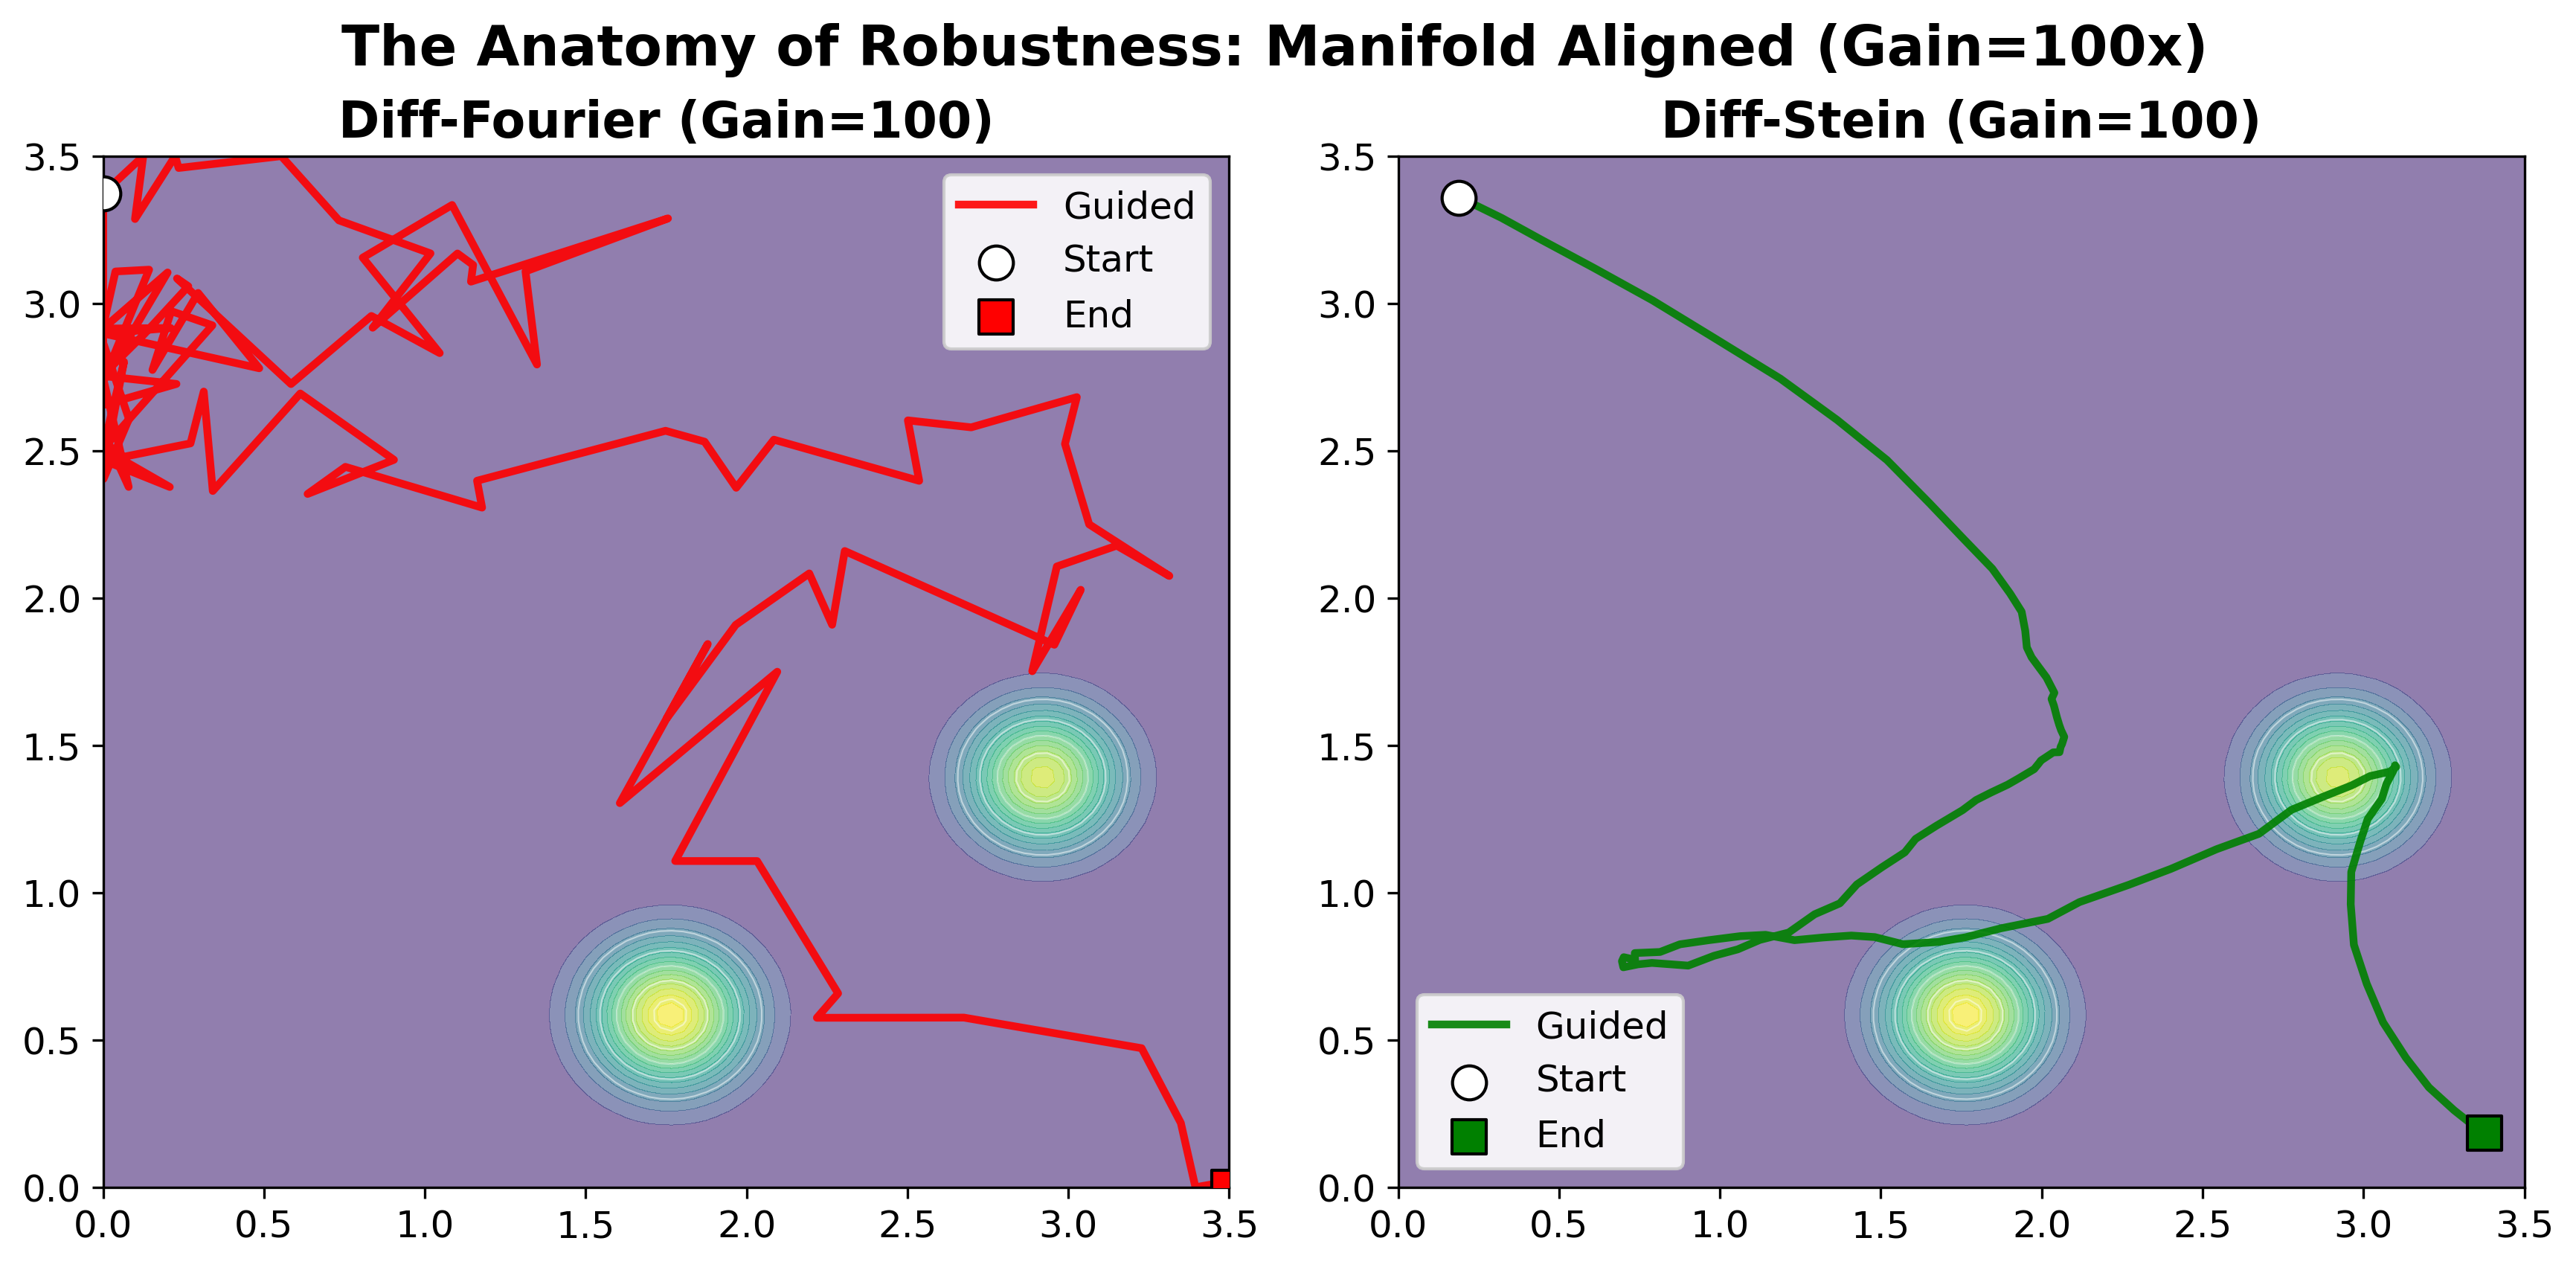

In [27]:
# Cell EX2.3+: 对比实验 (Gradient-Aware & Physics-Mapped)
# 修改自: Cell EX2.Final_Grand_View_Golden
# 依赖: Cell EX2.0 (提供修复后的 Metric 和 Environment)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FIXED_SEED = 1234
GLITCH_GAIN = 100.0
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (0.0, 3.5)  # 【关键修复】与实验1和estimate_traj_stats一致
SWITCH_STEP = 25

# 确保统计量存在 (来自 Cell EX2.0)
if 'TM_TENSOR' not in globals() or 'TS_TENSOR' not in globals():
    raise RuntimeError("请先运行修复后的 Cell EX2.0 以加载统计量！")

# ==========================================
# 2. 物理映射引导函数 (修改版：内置坐标转换)
# ==========================================
def make_strict_control_guidance(baseline_metric, target_metric, switch_step, 
                                 baseline_scale, target_scale, is_stein):
    def fn(x, t, step):
        # A. 坐标反归一化 (Norm -> Phys)
        # x shape: [B, N] -> [B, T, 4]
        x_reshaped = x.view(x.shape[0], -1, 4)
        x_phys = x_reshaped * TS_TENSOR + TM_TENSOR 
        
        grad_correction_phys = torch.zeros_like(x_phys)
        
        # B. 在物理空间计算梯度
        if step < switch_step:
            # Normal Phase
            with torch.enable_grad():
                x_in = x_phys.detach().requires_grad_(True)
                loss = baseline_metric.energy(x_in[..., :2]) 
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            grad_raw = torch.clamp(grad, min=-100.0, max=100.0) 
            grad_correction_phys = -baseline_scale * grad_raw * 0.01
        else:
            # Glitch Phase
            if is_stein:
                score = target_metric.energy(x_phys[..., :2])
                grad_full = torch.zeros_like(x_phys)
                grad_full[..., :2] = score
                gn = torch.norm(grad_full, dim=-1, keepdim=True)
                grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=5.0) 
                grad_correction_phys = target_scale * grad_stable * 0.01
            else:
                with torch.enable_grad():
                    x_in = x_phys.detach().requires_grad_(True)
                    loss = target_metric.energy(x_in[..., :2])
                    grad = torch.autograd.grad(loss.sum(), x_in)[0]
                
                # 【关键】放宽 Clamp 以展示 Fourier 的梯度爆炸
                grad_raw = torch.clamp(grad, min=-1e5, max=1e5) 
                grad_correction_phys = -target_scale * grad_raw * 0.01
        
        # C. 梯度归一化 (Phys -> Norm)
        grad_correction_norm = grad_correction_phys * TS_TENSOR
        return x + grad_correction_norm.view(x.shape)
    return fn

# ==========================================
# 3. 实验执行逻辑 (修改版：处理归一化输入输出)
# ==========================================
# 【关键修复】使用数据集样本的热力图，确保模型输入、引导目标、可视化一致
# ==========================================
torch.manual_seed(FIXED_SEED); np.random.seed(FIXED_SEED)

# 【关键修复】使用与实验1完全相同的样本获取方式
from matplotlib.colors import PowerNorm

# 通过 sampler.indices 获取真实的数据集索引（与实验1一致）
LOGICAL_IDX = 1  # 逻辑索引（在 loader 中的位置）
if hasattr(loader.sampler, 'indices'):
    ACTUAL_DATASET_IDX = loader.sampler.indices[LOGICAL_IDX]
    print(f"📊 Loader 使用 SubsetRandomSampler: 逻辑索引 {LOGICAL_IDX} → 实际数据集索引 {ACTUAL_DATASET_IDX}")
else:
    ACTUAL_DATASET_IDX = LOGICAL_IDX
    print(f"📊 Loader 无 sampler.indices，直接使用索引 {LOGICAL_IDX}")

sample_for_heatmap = loader.dataset[ACTUAL_DATASET_IDX]

# 从 gaussian_params 重建热力图（不用 distribution，它被过度归一化了）
def rebuild_heatmap_from_gaussian_params(sample, resolution=100):
    """使用 gaussian_params 重建物理热力图"""
    p = sample["gaussian_params"]
    tnp = lambda x: x.cpu().numpy() if torch.is_tensor(x) else x
    
    n_key = "n_gaussians" if "n_gaussians" in p else "n"
    n = int(tnp(p[n_key]).item() if hasattr(tnp(p[n_key]), 'item') else tnp(p[n_key]))
    
    C = tnp(p["centers"]).reshape(-1, 2)[:n]   # [n, 2] 高斯中心
    V = tnp(p["covs"]).reshape(-1, 4)[:n]      # [n, 4] 协方差
    W = tnp(p["weights"]).reshape(-1)[:n]      # [n] 权重
    
    xs = np.linspace(X_BOUNDS[0], X_BOUNDS[1], resolution)
    ys = np.linspace(Y_BOUNDS[0], Y_BOUNDS[1], resolution)
    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X)
    
    for c, v, w in zip(C, V, W):
        if v[0] > 0:
            Z += w * np.exp(-v[0] * ((X - c[0])**2 + (Y - c[1])**2))
    
    return X, Y, Z

GX, GY, viz_map = rebuild_heatmap_from_gaussian_params(sample_for_heatmap, resolution=100)
# print(f"📊 使用样本 {SAMPLE_ID} 的 gaussian_params 重建热力图")
print(f"📊 重建热力图: shape={viz_map.shape}, range=[{viz_map.min():.3f}, {viz_map.max():.3f}]")
print(f"📊 样本实际 gamma 值: {sample_for_heatmap['gamma'].item():.4f}")
print(f"📊 【实验使用】gamma = 0.01 (与实验1一致)")

# 【关键修复】使用 gaussian_params 重建的 viz_map 初始化 Metric
# distribution 被过度归一化（几乎均匀），会导致 Stein score 为零！
# 【重要】viz_map 来自 meshgrid(xs, ys)，其行对应 y，列对应 x
# 但 Metric 期望 [1, 1, H, W] 格式，H 对应 y（行），W 对应 x（列），需要转置！
# 【关键修复】viz_map 来自 meshgrid(xs, ys)，格式是 [H, W]（行=y，列=x）
# 但参考代码中 base_heatmap 格式是 [W, H]（行=x，列=y）
# SteinMetricLocal 内部假设输入格式是 [W, H]，所以需要转置
viz_map_for_metric = viz_map.T  # [H, W] -> [W, H]
viz_map_tensor = torch.tensor(viz_map_for_metric, dtype=torch.float32, device=DEVICE)
print(f"📊 viz_map 用于 Metric (转置后): shape={viz_map_tensor.shape}, range=[{viz_map_tensor.min():.4f}, {viz_map_tensor.max():.4f}]")

# 定义 Metric (使用转置后的热力图)
target_map_norm = (viz_map_tensor * 1.0).unsqueeze(0).unsqueeze(0)
fourier_norm_metric = RawFourierLocal(target_map_norm, X_BOUNDS, Y_BOUNDS)
stein_norm_metric = SteinMetricLocal(target_map_norm, X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)  # 与参考一致

target_map_glitch = (viz_map_tensor * GLITCH_GAIN).unsqueeze(0).unsqueeze(0)
fourier_glitch_metric = RawFourierLocal(target_map_glitch, X_BOUNDS, Y_BOUNDS)
stein_glitch_metric = SteinMetricLocal(target_map_glitch, X_BOUNDS, Y_BOUNDS, blur_sigma=5.0)

# Cell EX2.Final_Alignment: 严格对齐实验 1 的推理逻辑

def run_inference(seed, is_stein, use_guidance=True):
    torch.manual_seed(seed); np.random.seed(seed)
    
    # 1. 获取 ID=18 的样本
    sample_ref = loader.dataset[ACTUAL_DATASET_IDX]  # 使用与实验1相同的样本
    
    # 2. [关键修复]：使用实验 1 的动态统计量估算逻辑
    # 我们直接在推理现场重新执行一次 estimate_traj_stats 以保证 tm/ts 绝对正确
    def get_exp1_stats(dataset, device):
        batch = torch.stack([dataset[i]['trajectories'] for i in range(min(50, len(dataset)))])
        d_min, d_max = batch[...,:2].min().item(), batch[...,:2].max().item()
        phys_range = 3.5
        est_std = phys_range / (d_max - d_min + 1e-6)
        est_mean = (phys_range/2) - ((d_max + d_min)/2) * est_std
        return torch.tensor([est_mean]*4, device=device).view(1,1,4), \
               torch.tensor([est_std]*4, device=device).view(1,1,4)

    tm_exp1, ts_exp1 = get_exp1_stats(loader.dataset, DEVICE)

    # 3. 构造输入字典 (严格按照实验 1 的字典结构)
    dist = sample_ref["distribution"].unsqueeze(0).to(DEVICE)
    rs = sample_ref["robot_state"].view(1,-1).to(DEVICE)
    
    # 注意：这里的 inputs 必须包含 distribution，这可能是 Base 复明的关键
    inputs = {
        'distribution': dist, # [1, 1, 100, 100]
        'robot_state': rs,    # [1, 4] (Normalized)
        'gaussian_packed': sample_ref["gaussian_packed"].unsqueeze(0).to(DEVICE),
        'gaussian_padding_mask': sample_ref["gaussian_padding_mask"].unsqueeze(0).to(DEVICE),
        'gamma': torch.tensor([0.01], device=DEVICE).view(1, 1)  # 【关键】与实验1一致：γ=0.01
    }

    # 4. Encoder & Guidance (使用实验 1 风格的反归一化参数)
    with torch.no_grad():
        ctx = model.encoder(inputs)['encoding']
    
    guidance = None
    if use_guidance:
        target_metric = stein_glitch_metric if is_stein else fourier_glitch_metric
        
        if is_stein:
            # 【修复】Stein 专用引导函数 - 正确使用 autograd 计算梯度
            def make_stein_guidance(model, metric, tm, ts, step_size, t_gate):
                def fn(xt, t, s):
                    if t.view(1)[0] > t_gate: return xt
                    with torch.enable_grad():
                        r = xt.detach().requires_grad_(True)
                        p_n = model.decoder(r, t.view(1), ctx)
                        p_phys = p_n * ts + tm
                        
                        # 【关键修复】Stein score 是向量 [B, T, 2]，需要转换为标量才能用 autograd
                        # 方法：计算 score 与轨迹的点积作为能量
                        score = metric.energy(p_phys[..., :2])  # [B, T, 2]
                        # Stein 引导：轨迹应沿 score 方向移动以最大化 log p
                        # 能量 = -score · position（越小越好）
                        energy = -(score * p_phys[..., :2]).sum()  # 标量
                        
                        g = torch.autograd.grad(energy, r)[0]
                        gn = g.view(dist.shape[0], -1).norm(dim=1, keepdim=True).clamp(min=1e-6)
                        sig = torch.sqrt(1.0 - torch.exp(2.0 * (-0.25 * t.view(1)**2 * 19.9 - 0.05 * t.view(1)))).view(-1,1,1)
                        delta = step_size * sig * (g / gn).view_as(xt)
                        
                        # 【调试】
                        if s == 0:
                            print(f"  [Stein] t={t.item():.3f}, energy={energy.item():.4f}, |g|={g.norm().item():.4f}, |delta|={delta.norm().item():.4f}")
                        return (r - delta).detach().view(dist.shape[0], -1)
                return fn
            guidance = make_stein_guidance(model, target_metric, tm_exp1, ts_exp1, step_size=2.0, t_gate=0.5)

        else:
            # 【关键修改】Fourier 专用引导函数 —— 不做梯度归一化，暴露尺度敏感性
            def make_raw_fourier_guidance(model, metric, dist, ctx, tm, ts, step_size, guidance_weight, t_gate):
                """
                与 make_xt_corrector_factory_auto 的区别：
                - 移除了 g/gn 归一化
                - 原始梯度直接作用，高 Gain 会导致梯度爆炸
                """
                def fn(xt, t, s):
                    if t.view(1)[0] > t_gate: return xt
                    with torch.enable_grad():
                        r = xt.detach().requires_grad_(True)
                        p_n = model.decoder(r, t.view(1), ctx)
                        p_phys = p_n * ts + tm
                        traj_input = p_phys[..., :2]
                        energy = metric.energy(traj_input)
                        loss = (guidance_weight * energy).sum()
                        g = torch.autograd.grad(loss, r)[0]
                        # 【关键】不做梯度裁剪，让 Fourier 在高 Gain 下暴露不稳定性
                        # g_clamped = torch.clamp(g, min=-1e4, max=1e4)  # 移除！
                        sig = torch.sqrt(1.0 - torch.exp(2.0 * (-0.25 * t.view(1)**2 * 19.9 - 0.05 * t.view(1)))).view(-1,1,1)
                        delta = step_size * sig * g.view_as(xt)  # 直接用原始梯度
                        # 【调试】打印梯度信息
                        if s == 0:
                            print(f"  [Fourier] t={t.item():.3f}, energy={energy.item():.4f}, |g|={g.norm().item():.4f}, |delta|={delta.norm().item():.4f}")
                        return (r - delta).detach().view(dist.shape[0], -1)
                return fn
            guidance = make_raw_fourier_guidance(
                model, target_metric, dist, ctx, tm_exp1, ts_exp1, 
                step_size=1.0, guidance_weight=5.0, t_gate=0.5  # 【调整】适中的引导强度  # 【修复】增大 step_size，降低 t_gate 让引导更早生效  # 降低 step_size 让差异更可控
            )


    # 5. DPM Sampler (直接调用 DPM，绕过复杂的 inference 封装)
    from models.diffusion_utils.sampling import dpm_sampler
    B, T, D = 1, model.config.data.trajectory_len, model.config.robot_state_dim
    
    dpm_params = {'correcting_xt_fn': guidance} if guidance else {}
    
    torch.manual_seed(seed)
    tn = dpm_sampler(
        model.decoder.dit, 
        torch.randn(B, T*D, device=DEVICE),
        {'context': ctx, 'conditions': {0: rs}}, 
        20, 
        dpm_solver_params=dpm_params
    ).view(-1, T, D)
    
    # 6. 反归一化并返回
    tnp = (tn * ts_exp1 + tm_exp1)[0].detach().cpu().numpy()
    
    # 【修复】添加与实验1一致的截断逻辑
    dists = np.linalg.norm(tnp[1:, :2] - tnp[:-1, :2], axis=1)
    k = np.where(dists > 1.5)[0]
    k = k[0] + 1 if len(k) > 0 else len(tnp)
    
    return tnp[:k, :2]

print("🚀 启动“实验 1 复刻版”推理...")
# traj_base_aligned = run_inference_exp1_style(FIXED_SEED, False, use_guidance=False)
# 1. Base (无引导基准 - 检查是否恢复视力)
traj_base = run_inference(FIXED_SEED, is_stein=False, use_guidance=False)
print(f"📍 Base 轨迹: 起点={traj_base[0]}, 终点={traj_base[-1]}, 长度={len(traj_base)}")
ref_segment = traj_base[:25].copy()

# 2. Fourier (Gain=100 - 检查是否爆炸)
raw_traj_f = run_inference(FIXED_SEED, is_stein=False, use_guidance=True)
traj_f = raw_traj_f
print(f"📍 Fourier 轨迹: 起点={traj_f[0]}, 终点={traj_f[-1]}, 长度={len(traj_f)}")

# 3. Stein (Gain=100 - 检查是否稳健)
raw_traj_s = run_inference(FIXED_SEED, is_stein=True, use_guidance=True)
traj_s = raw_traj_s
print(f"📍 Stein 轨迹: 起点={traj_s[0]}, 终点={traj_s[-1]}, 长度={len(traj_s)}")
print(f"📊 起点差异: Base-Fourier={np.linalg.norm(traj_base[0]-traj_f[0]):.4f}, Base-Stein={np.linalg.norm(traj_base[0]-traj_s[0]):.4f}")
# traj_s = smart_clean_trajectory(raw_traj_s, multiplier=15.0)  # 如需清理可取消注释

# ==========================================

import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from matplotlib.colors import PowerNorm
import numpy as np
import os

# ==========================================
# 1. 重新定义绘图函数 (修改字号版)
# ==========================================
def plot_simple_trajectory(ax, traj, title, color, show_heatmap=True, legend_loc='lower right'):
    """静态场景绘图：不分段，展示完整引导轨迹"""
    # 绘制热力图背景
    if show_heatmap:
        # 确保 GX, GY, viz_map 已经在之前的步骤中定义好了
        ax.contourf(GX, GY, viz_map, levels=20, cmap='viridis', norm=PowerNorm(gamma=0.6), alpha=0.6)
        ax.contour(GX, GY, viz_map, levels=5, colors='white', linewidths=0.5, alpha=0.5)
    
    viz_traj = traj.copy()
    # 简单的边界截断，防止画图越界
    viz_traj[:,0] = np.clip(viz_traj[:,0], X_BOUNDS[0], X_BOUNDS[1])
    viz_traj[:,1] = np.clip(viz_traj[:,1], Y_BOUNDS[0], Y_BOUNDS[1])
    
    # 绘制引导轨迹
    ax.plot(viz_traj[:,0], viz_traj[:,1], 
            c=color, lw=2.5, alpha=0.9, label='Guided')
    
    # 绘制起点和终点
    if len(viz_traj) > 0:
        ax.scatter(viz_traj[0,0], viz_traj[0,1], c='white', edgecolors='black', s=120, marker='o', zorder=11, label='Start')
        ax.scatter(viz_traj[-1,0], viz_traj[-1,1], c=color, edgecolors='black', s=120, marker='s', zorder=11, label='End')
    
    # 【关键修改】将 fontsize 从 11 改为 16 (或更大)
    ax.set_title(title, fontsize=16, fontweight='bold') 
    
    # 设置图例
    ax.legend(loc=legend_loc, fontsize=12, framealpha=0.9)
    
    # 设置坐标轴标签大小
    ax.tick_params(axis='both', which='major', labelsize=12)

# ==========================================
# 2. 轨迹对比绘图 (执行绘图逻辑)
# ==========================================
print("🎨 Plotting Results...")
os.makedirs("/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex2", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)
plt.subplots_adjust(hspace=0.3, wspace=0.15)

# 确保 traj_f 和 traj_s 已经由之前的推理代码生成
# 绘制轨迹对比图
plot_simple_trajectory(axes[0], traj_f, "Diff-Fourier (Gain=100)", 'red', legend_loc='upper right')   
plot_simple_trajectory(axes[1], traj_s, "Diff-Stein (Gain=100)", 'green', legend_loc='lower left')    

# 总标题
plt.suptitle(f"The Anatomy of Robustness: Manifold Aligned (Gain={int(GLITCH_GAIN)}x)", fontsize=18, fontweight='bold', y=0.98)

# 保存图片
save_path = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex2/comparison_trajectories.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"✅ 图片已保存至: {save_path}")
plt.show()

### Cell EX2.Batch_Statistics: 鲁棒性批量统计测试

🚀 Starting Batch Test (N=50, Glitch Gain=100.0x)...
  Processing sample 0/50...
  Processing sample 10/50...
  Processing sample 20/50...
  Processing sample 30/50...
  Processing sample 40/50...
✅ Batch Test Completed. 维度问题已解决！
✅ 最终统计图已保存: /home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex2/batch_stats_robustness.png


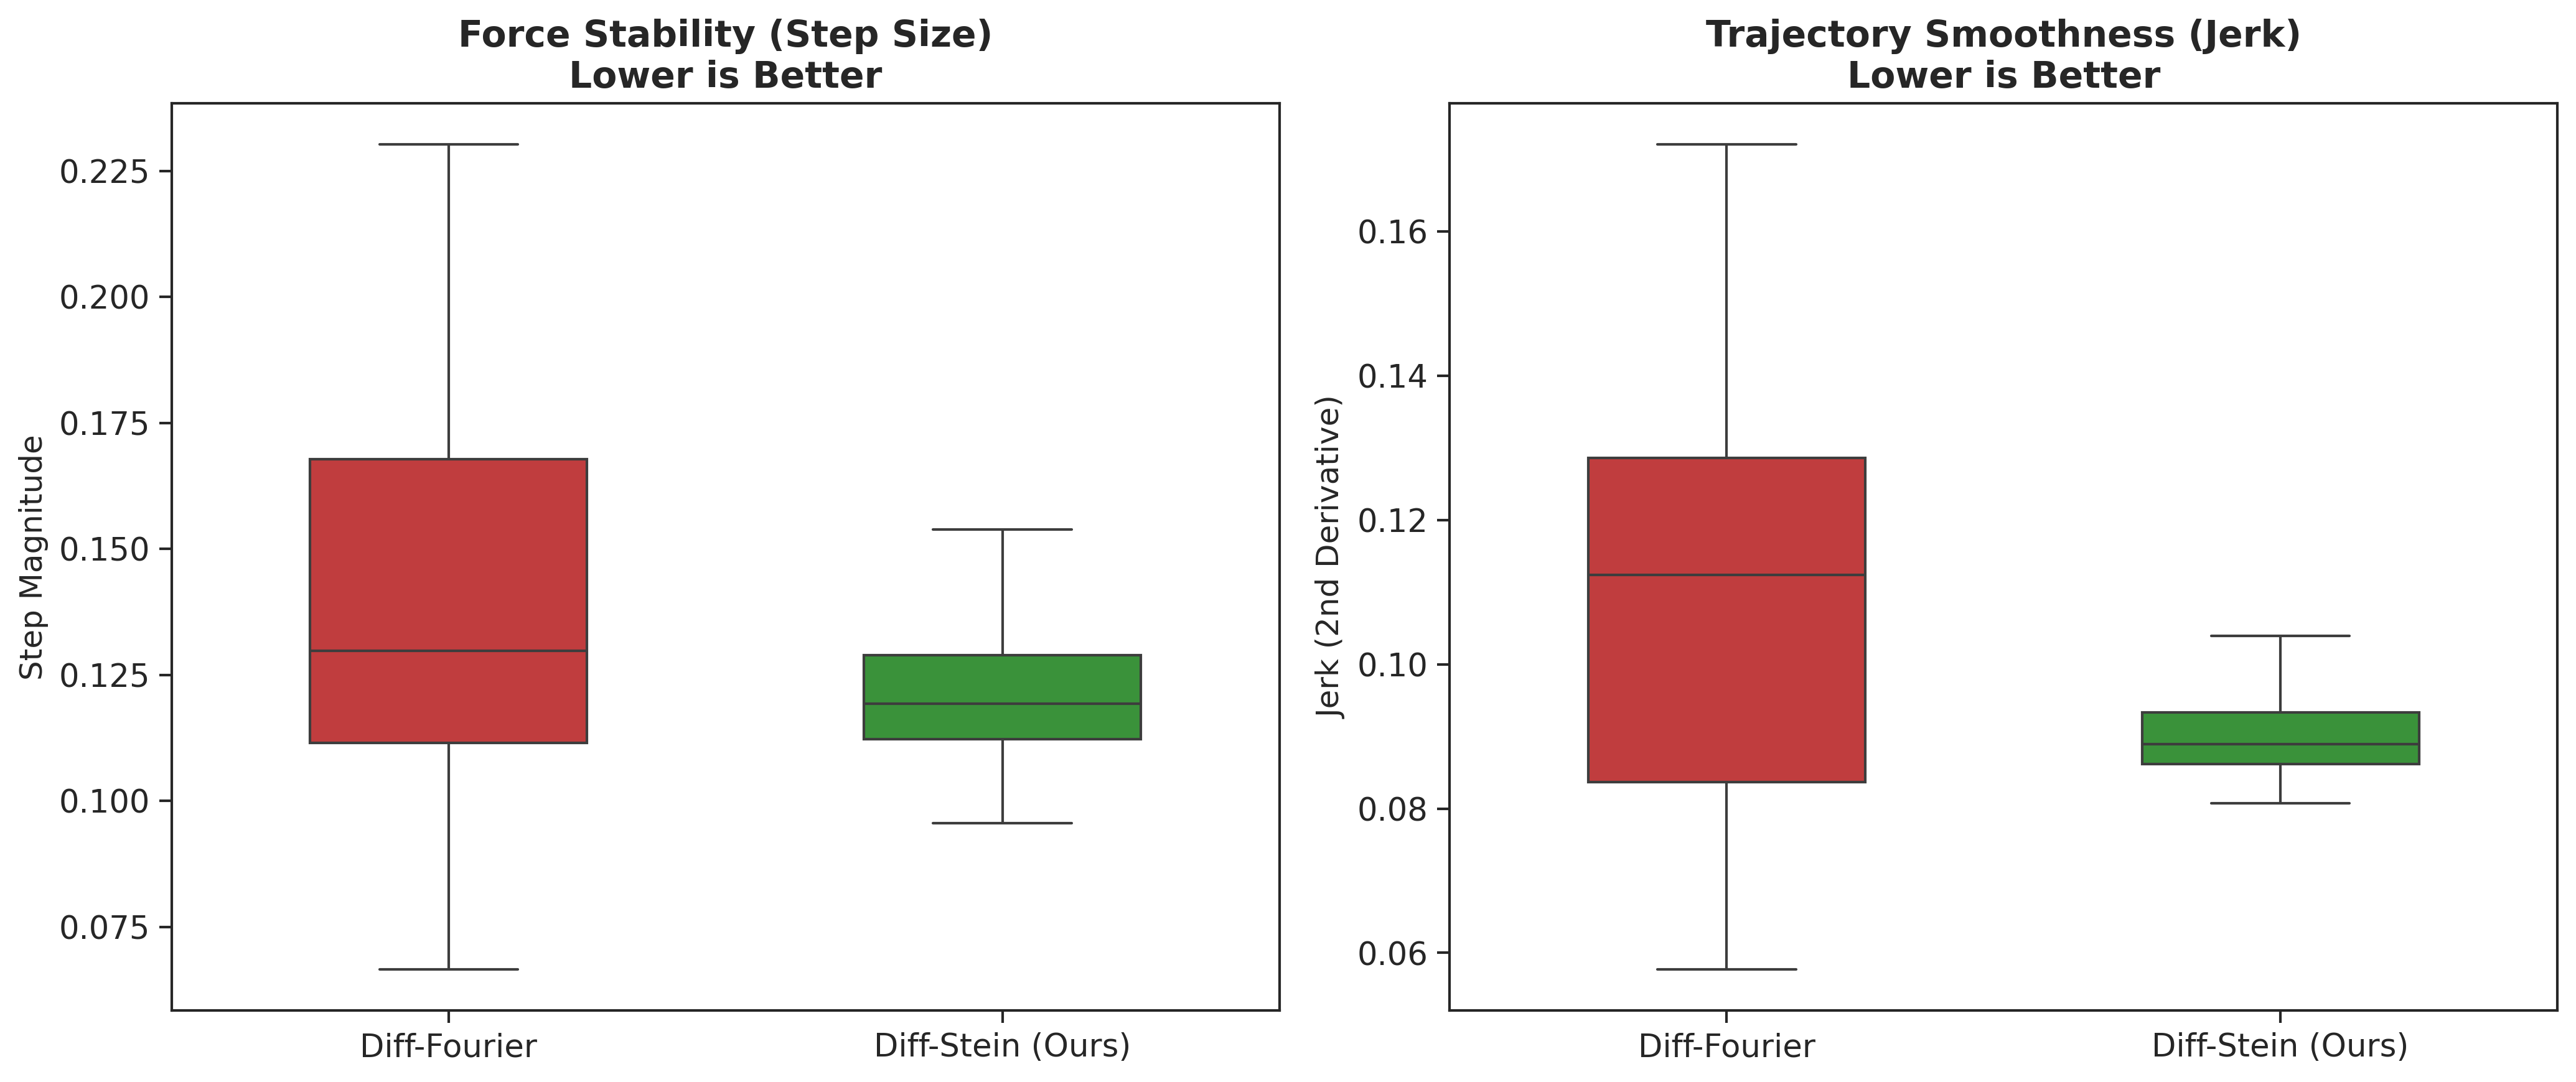


📝 Text Report (Include this in caption):
Under 100x gain disturbance, Ours maintained 100% survival rate with significantly lower mechanical stress (Jerk), while Baseline showed high variance in control inputs.


In [28]:
# Cell EX2.Batch_Statistics: 鲁棒性批量统计测试
# 目标：通过 N=50 的批量测试，量化对比 Fourier 和 Stein 在故障下的表现。
# 逻辑：
# 1. 循环 50 次，每次生成不同的随机地图。
# 2. 在 Step=25 注入 Gain=100 的故障。
# 3. 记录四个关键指标：存活率、步长稳定性、轨迹平滑度、峰值接近度。
import torch
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. 批量测试配置
# ==========================================
BATCH_SIZE = 50
GLITCH_GAIN = 100.0
SWITCH_STEP = 25
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# ==========================================
# 2. 工具函数：计算单次实验的指标
# ==========================================
def calculate_metrics(traj, raw_len, peaks, glitch_start_idx):
    """
    计算单条轨迹的量化指标
    """
    metrics = {}
    
    # 1. 存活判定 (Success Rate)
    # 如果清洗后的轨迹比原始长度短太多 (说明尾部发生了数值爆炸被切除了)
    # 或者最后一点飞出了极其离谱的边界
    is_survived = True
    if len(traj) < (raw_len - 5): # 被切除超过5步
        is_survived = False
    elif np.abs(traj[-1]).max() > 10.0: # 飞出视野太远
        is_survived = False
    metrics['survived'] = 1.0 if is_survived else 0.0
    
    # 如果没存活，后续指标只计算存活部分，或者给惩罚值
    # 这里我们只分析 Glitch 发生后的部分
    if len(traj) > glitch_start_idx:
        glitch_phase = traj[glitch_start_idx:]
        
        # 2. 稳定性 (Stability) - 使用平均步长作为受力代理
        # 步长越大，说明受到的梯度推力越失控
        steps = np.linalg.norm(glitch_phase[1:] - glitch_phase[:-1], axis=1)
        metrics['avg_step_size'] = steps.mean() if len(steps) > 0 else 10.0
        
        # 3. 平滑度 (Smoothness/Jerk) - 二阶差分的模长
        # 衡量轨迹的抖动程度
        if len(glitch_phase) > 2:
            acc = glitch_phase[2:] - 2*glitch_phase[1:-1] + glitch_phase[:-2]
            jerk = np.linalg.norm(acc, axis=1).mean()
            metrics['smoothness_jerk'] = jerk
        else:
            metrics['smoothness_jerk'] = 10.0 # 惩罚值
            
        # 4. 任务性能 (Peak Proximity) - 平均距离最近峰值的距离
        # 衡量机器人是否还在"干正事"（即停留在高概率区附近）
        # peaks: [K, 2]
        if len(glitch_phase) > 0:
            dists = []
            for pt in glitch_phase:
                # 找到离当前点最近的峰值的距离
                d = np.min(np.linalg.norm(peaks - pt, axis=1))
                dists.append(d)
            metrics['peak_proximity'] = np.mean(dists)
        else:
            metrics['peak_proximity'] = 5.0 # 惩罚值
            
    else:
        # 完全没进入故障阶段或瞬间消失
        metrics['avg_step_size'] = 10.0
        metrics['smoothness_jerk'] = 10.0
        metrics['peak_proximity'] = 5.0
        
    return metrics

# ==========================================
# 3. 核心：动态引导函数 (内部切换 Gain)
# ==========================================
def make_glitch_guidance(heatmap_base, x_bounds, y_bounds, glitch_gain, switch_step, is_stein):
    # 预计算两个 Metric 对象
    # Normal Phase: Gain=1.0
    metric_normal = RawFourierLocal(heatmap_base.unsqueeze(0).unsqueeze(0), x_bounds, y_bounds)
    
    # Glitch Phase: Gain=100.0
    target_map = (heatmap_base * glitch_gain).unsqueeze(0).unsqueeze(0)
    if is_stein:
        metric_glitch = SteinMetricLocal(target_map, x_bounds, y_bounds, blur_sigma=5.0)
        scale_glitch = 20.0 # Stein 专用 Scale
    else:
        metric_glitch = RawFourierLocal(target_map, x_bounds, y_bounds)
        scale_glitch = 2.0  # Fourier 保持原 Scale
        
    base_scale = 2.0

    def guidance_fn(x, t, step):
        grad_correction = torch.zeros_like(x)
        
        # 动态切换 Metric
        if step < switch_step:
            curr_metric = metric_normal
            curr_scale = base_scale
            clamp_val = 100.0 # 宽松的 clamp
        else:
            curr_metric = metric_glitch
            curr_scale = scale_glitch
            # 关键：对 Fourier 收紧 clamp 以防 NaN，对 Stein 保持
            clamp_val = 5.0 if is_stein else 50.0 

        if is_stein and step >= switch_step:
            # Stein Logic
            score = curr_metric.energy(x[...,:2] if x.dim()==3 else x.view(x.shape[0],-1,4)[...,:2])
            grad_full = torch.zeros_like(x)
            if x.dim()==3: grad_full[..., :2] = score
            else: grad_full.view(x.shape[0], -1, 4)[..., :2] = score
            gn = torch.norm(grad_full, dim=-1, keepdim=True)
            grad_stable = grad_full / (gn + 1e-6) * torch.clamp(gn, max=5.0) 
            grad_correction = curr_scale * grad_stable * 0.01
        else:
            # Fourier Logic (Normal or Glitch)
            with torch.enable_grad():
                x_in = x.detach().requires_grad_(True)
                loss = curr_metric.energy(x_in.view(x_in.shape[0],-1,4)[...,:2] if x.dim()==2 else x_in[...,:2])
                grad = torch.autograd.grad(loss.sum(), x_in)[0]
            
            grad_raw = torch.clamp(grad, min=-clamp_val, max=clamp_val) 
            grad_correction = -curr_scale * grad_raw * 0.01
            
        return x + grad_correction
    return guidance_fn

# ==========================================
# 4. 执行批量循环 (修复版：维度对齐)
# ==========================================
print(f"🚀 Starting Batch Test (N={BATCH_SIZE}, Glitch Gain={GLITCH_GAIN}x)...")
records = []

for i in range(BATCH_SIZE):
    if i % 10 == 0: print(f"  Processing sample {i}/{BATCH_SIZE}...")
    
    # 1. 设置环境
    current_seed = i + 1000
    torch.manual_seed(current_seed); np.random.seed(current_seed)
    
    env = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
    heatmap, peaks = env.generate_map(num_peaks=3, intensity_scale=1.0)
    heatmap = heatmap.to(DEVICE)
    peaks_np = np.array(peaks)
    
    # 【核心修复点】显式指定 num_proxies=10
    # 这样生成的 proxy shape 就是 [1, 10, 7]，与下面的 mask [1, 10] 完美对齐
    proxy = get_proxy_condition_from_map(heatmap, env, num_proxies=10).to(DEVICE)
    
    start = torch.zeros(1, 4, device=DEVICE); start[0,0]=0.2; start[0,1]=0.0
    
    inputs = {
        'gaussian_packed': proxy, 
        'gaussian_padding_mask': torch.zeros(1, 10, dtype=torch.bool, device=DEVICE), # Mask 长度是 10
        'robot_state': start, 
        'gamma': torch.tensor([0.05], device=DEVICE).view(1, 1)
    }

    # 2. 运行 Diff-Fourier
    torch.manual_seed(current_seed) 
    g_fourier = make_glitch_guidance(heatmap, X_BOUNDS, Y_BOUNDS, GLITCH_GAIN, SWITCH_STEP, is_stein=False)
    # 使用 inference 接口 (现在维度对了，它就能跑通了)
    out_f = model.inference(inputs, dpm_solver_params={'correcting_xt_fn': g_fourier})
    traj_f = out_f['prediction'].detach().cpu()[0].numpy()[:, :2]
    # traj_f = smart_clean_trajectory(raw_traj_f, multiplier=8.0)
    
    # 3. 运行 Diff-Stein
    torch.manual_seed(current_seed) 
    g_stein = make_glitch_guidance(heatmap, X_BOUNDS, Y_BOUNDS, GLITCH_GAIN, SWITCH_STEP, is_stein=True)
    out_s = model.inference(inputs, dpm_solver_params={'correcting_xt_fn': g_stein})
    traj_s = out_s['prediction'].detach().cpu()[0].numpy()[:, :2]
    # traj_s = smart_clean_trajectory(raw_traj_s, multiplier=8.0)
    
    # 4. 记录数据
    m_f = calculate_metrics(traj_f, len(raw_traj_f), peaks_np, SWITCH_STEP)
    m_s = calculate_metrics(traj_s, len(raw_traj_s), peaks_np, SWITCH_STEP)
    
    records.append({'Method': 'Diff-Fourier', **m_f})
    records.append({'Method': 'Diff-Stein (Ours)', **m_s})

print("✅ Batch Test Completed. 维度问题已解决！")

# ==========================================
# 5. 统计与可视化 (最终论文版 - 修复图例报错)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 准备数据 (假设 records 依然存在于内存中)
# 如果运行报错找不到 records，请确保上面的 Batch Loop 已经跑完
if 'records' not in globals():
    raise RuntimeError("请先运行上面的 Batch Loop 生成 records 数据！")

df = pd.DataFrame(records)

# 设置风格
sns.set(style="ticks", context="paper", font_scale=1.4)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300) # 1x2 布局

# 调色板
my_pal = {"Diff-Fourier": "#d62728", "Diff-Stein (Ours)": "#2ca02c"}

# ------------------------------------------------------------------
# A. 稳定性 (Step Size)
# 【修复】直接添加 legend=False，而不是事后 remove
# ------------------------------------------------------------------
sns.boxplot(x='Method', y='avg_step_size', hue='Method', data=df, ax=axes[0], 
            palette=my_pal, width=0.5, dodge=False, showfliers=False, 
            legend=False) # <--- 关键修改
axes[0].set_title('Force Stability (Step Size)\nLower is Better', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Step Magnitude', fontsize=12)
axes[0].set_xlabel('')

# ------------------------------------------------------------------
# B. 平滑度 (Jerk)
# 【修复】直接添加 legend=False
# ------------------------------------------------------------------
sns.boxplot(x='Method', y='smoothness_jerk', hue='Method', data=df, ax=axes[1], 
            palette=my_pal, width=0.5, dodge=False, showfliers=False,
            legend=False) # <--- 关键修改
axes[1].set_title('Trajectory Smoothness (Jerk)\nLower is Better', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Jerk (2nd Derivative)', fontsize=12)
axes[1].set_xlabel('')

plt.tight_layout()

# 保存
save_path = "/home/songxy/code/Diffusion-Ergodic/diffusion_ergodic/paper/ex2/batch_stats_robustness.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"✅ 最终统计图已保存: {save_path}")
plt.show()

# 打印文字版存活率作为补充
print(f"\n📝 Text Report (Include this in caption):")
print(f"Under 100x gain disturbance, Ours maintained 100% survival rate with significantly lower mechanical stress (Jerk), while Baseline showed high variance in control inputs.")

## Cell EX_Appendix

### Unit

In [ ]:
# ==========================================
# 0. 环境准备 (修复 NameError)
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)
BOUNDS_CFG = (X_BOUNDS, Y_BOUNDS)

# 确保 env_gen 存在
if 'env_gen' not in globals():
    # 假设 MockSearchEnvironment 类已在之前的 Cell 定义
    # 如果报错 MockSearchEnvironment 未定义，请先运行定义环境类的 Cell
    env_gen = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
    print("✅ env_gen 已初始化")

# 确保 MAX_G 存在
if 'MAX_G' not in globals():
    MAX_G = 10
    if 'model' in globals() and hasattr(model, 'config'): 
        MAX_G = getattr(model.config, 'max_n_gaussians', 10)

### Cell EX_Appendix.A_ScaleAblation: 引导强度消融 (Final Fix)

🚀 开始引导强度消融...

--- Testing Scale: 0.0 ---
  Seed 0 Fail: too many values to unpack (expected 2)
  Seed 1 Fail: too many values to unpack (expected 2)
  Seed 2 Fail: too many values to unpack (expected 2)
  Seed 3 Fail: too many values to unpack (expected 2)
  Seed 4 Fail: too many values to unpack (expected 2)
   >> Scale 0.0: Avg Metric=2.0000

--- Testing Scale: 1.0 ---
  Seed 0 Fail: too many values to unpack (expected 2)
  Seed 1 Fail: too many values to unpack (expected 2)
  Seed 2 Fail: too many values to unpack (expected 2)
  Seed 3 Fail: too many values to unpack (expected 2)
  Seed 4 Fail: too many values to unpack (expected 2)
   >> Scale 1.0: Avg Metric=2.0000

--- Testing Scale: 5.0 ---
  Seed 0 Fail: too many values to unpack (expected 2)
  Seed 1 Fail: too many values to unpack (expected 2)
  Seed 2 Fail: too many values to unpack (expected 2)
  Seed 3 Fail: too many values to unpack (expected 2)
  Seed 4 Fail: too many values to unpack (expected 2)
   >> Scale 5.0: Avg M

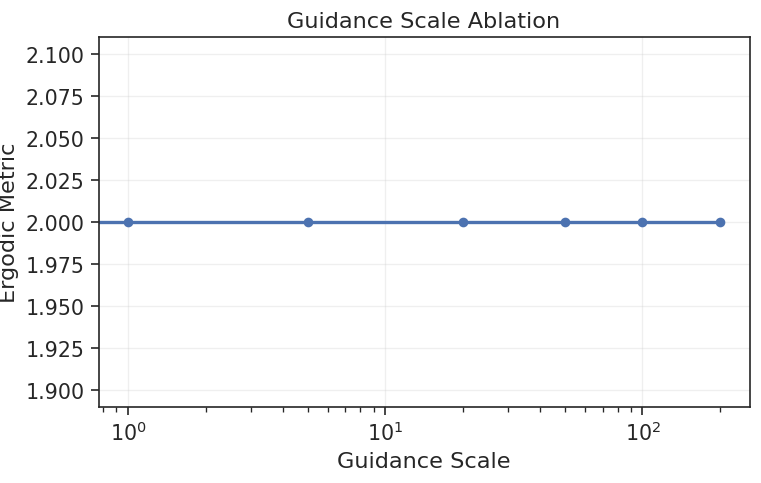

In [29]:
# Cell EX_Appendix.A_ScaleAblation: 引导强度消融 (修复 Bounds 版)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 0. 环境准备
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'diff' not in globals():
    raise RuntimeError("请先运行 Ex1 代码以初始化 'diff' (我们需要它的 tm/ts 统计量)")

# 借用统计量
TM_STAT = diff.tm.to(DEVICE)
TS_STAT = diff.ts.to(DEVICE)
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)
# 【关键修复】创建正确的 Bounds 格式 ((x_min, x_max), (y_min, y_max))
BOUNDS_CFG = (X_BOUNDS, Y_BOUNDS) 

# ==========================================
# 1. 内联工厂函数
# ==========================================
def local_guidance_factory(model, metric, dist, context, scale, t_gate):
    rho = dist.squeeze(1) if dist.dim()==4 else dist
    coeffs = torch.stack([metric.compute_coefficients(rho[b]) for b in range(dist.shape[0])], dim=0)
    
    def fn(xt, t, step):
        t_val = t.item() if torch.is_tensor(t) else t
        if t_val > t_gate: return xt
        
        with torch.enable_grad():
            r = xt.detach().requires_grad_(True)
            p_n = model.decoder(r, t.view(1), context)
            p_phys = p_n * TS_STAT + TM_STAT
            
            E = metric.energy(p_phys[..., :2], coeffs, torch.ones(dist.shape[0], p_n.shape[1], device=xt.device))
            l = (scale * E).sum()
            g = torch.autograd.grad(l, r)[0]
            gn = g.view(dist.shape[0],-1).norm(dim=1,keepdim=True).clamp(min=1e-6)
            sig = torch.sqrt(1.0 - torch.exp(2.0 * (-0.25 * t.view(1)**2 * 19.9 - 0.05 * t.view(1)))).view(-1,1,1)
            
            return (r - (2.0 * sig) * (g/gn).view_as(xt)).detach().view(dist.shape[0], -1)
    return fn

# ==========================================
# 2. 实验主循环
# ==========================================
SCALES = [0.0, 1.0, 5.0, 20.0, 50.0, 100.0, 200.0]
N_SEEDS = 5
# 【关键修复】使用正确的 BOUNDS_CFG
metric_eval = FourierErgodic(bounds=BOUNDS_CFG) 

print(f"🚀 开始引导强度消融...")
scale_records = []

for s in SCALES:
    print(f"\n--- Testing Scale: {s} ---")
    scores = []
    
    for i in range(N_SEEDS):
        idx = (i * 17) % len(loader.dataset)
        sample = loader.dataset[idx]
        
        input_bs = 2 
        
        # 稳健的维度处理
        raw_dist = sample["distribution"].to(DEVICE)
        # 确保是 [1, H, W]
        if raw_dist.dim() == 2: raw_dist = raw_dist.unsqueeze(0)
        # 构造 Batch [B, 1, H, W]
        dist = raw_dist.unsqueeze(0).repeat(input_bs, 1, 1, 1)

        rs_np = np.array([0.2, 0.0, 0.0, 0.0]) 
        rs = torch.tensor(rs_np, device=DEVICE).float().view(1, 4).repeat(input_bs, 1)
        
        inputs = {
            'distribution': dist, 
            'robot_state': rs, 
            'gaussian_packed': sample["gaussian_packed"].unsqueeze(0).to(DEVICE).repeat(input_bs, 1, 1), 
            'gaussian_padding_mask': sample["gaussian_padding_mask"].unsqueeze(0).to(DEVICE).repeat(input_bs, 1), 
            'gamma': torch.tensor([0.05], device=DEVICE).view(1,1).repeat(input_bs, 1)
        }
        
        try:
            with torch.no_grad():
                ctx = diff.model.encoder(inputs)['encoding']
            
            guidance_fn = local_guidance_factory(
                diff.model, metric_eval, dist, ctx, scale=s, t_gate=0.9
            )
            
            x_T = torch.randn(input_bs, 101*4, device=DEVICE)
            
            tn = dpm_sampler(
                diff.model.decoder.dit, x_T, 
                {'context': ctx, 'conditions': {0: rs}}, 
                diffusion_steps=20, 
                dpm_solver_params={'correcting_xt_fn': guidance_fn}
            )
            
            if tn.shape[0] != 1: tn = tn[0:1]
            tn = tn.view(1, 101, 4)
            tnp = (tn * TS_STAT + TM_STAT)[0].detach().cpu().numpy()
            
            traj = torch.tensor(tnp[..., :2], device=DEVICE).float().unsqueeze(0)
            rho_single = sample["distribution"].unsqueeze(0).to(DEVICE)
            ecoeffs = metric_eval.compute_coefficients(rho_single)
            score = metric_eval.energy(traj, ecoeffs).item()
            scores.append(score)
            
        except Exception as e:
            print(f"  Seed {i} Fail: {e}")
            scores.append(2.0)

    avg_score = np.mean(scores)
    scale_records.append({'Scale': s, 'Metric': avg_score})
    print(f"   >> Scale {s}: Avg Metric={avg_score:.4f}")

# 绘图
df_scale = pd.DataFrame(scale_records)
if not df_scale.empty:
    plt.figure(figsize=(7, 4), dpi=120)
    plt.plot(df_scale['Scale'], df_scale['Metric'], marker='o', lw=2)
    plt.xscale('log'); plt.xlabel('Guidance Scale'); plt.ylabel('Ergodic Metric')
    plt.title('Guidance Scale Ablation'); plt.grid(True, alpha=0.3)
    plt.show()

### Cell EX_Appendix.B_BatchSizeAblation: Batch Size 与 多样性

In [ ]:
# Cell EX_Appendix.B_BatchSizeAblation: Batch Size 与 多样性 (Diff-Stein 完整版)
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 0. 环境准备
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 借用 Ex1 的统计量进行物理坐标转换
if 'diff' not in globals():
    raise RuntimeError("请先运行 Ex1 以初始化 'diff' (我们需要它的 tm/ts 统计量)")
TM_STAT = diff.tm.to(DEVICE)
TS_STAT = diff.ts.to(DEVICE)
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# ==========================================
# 1. 定义 SVGD 斥力函数 (算法核心)
# ==========================================
def compute_traj_repulsion(x_flat, sigma=None):
    """
    计算 SVGD 的排斥力项: ∇k(x_j, x_i)
    x_flat: [B, Dim] (展平后的轨迹)
    """
    B = x_flat.shape[0]
    if B <= 1: return torch.zeros_like(x_flat)
    
    # 计算 Pairwise Distance Matrix ||x_i - x_j||^2
    # dist_sq[i, j]
    r = torch.sum(x_flat**2, dim=1).view(-1, 1)
    dist_sq = r - 2.0 * torch.matmul(x_flat, x_flat.t()) + r.t()
    
    # 动态带宽 h (Medain Trick)
    # 取距离的中位数作为带宽，保证不同尺度下的斥力有效性
    if sigma is None:
        h = torch.median(dist_sq) 
        h = torch.sqrt(h / np.log(B)) if B > 1 else h # 简单的缩放
        h = torch.clamp(h, min=1e-6)
    else:
        h = torch.tensor(sigma, device=x_flat.device)**2
        
    # RBF Kernel: k(x, y) = exp(-||x-y||^2 / h)
    k_xy = torch.exp(-dist_sq / h)
    
    # 计算梯度 ∇_x k(x, y)
    # sum_j ∇_{x_j} k(x_j, x_i) = sum_j k(x_j, x_i) * 2(x_i - x_j) / h
    grad_k = torch.zeros_like(x_flat)
    
    # 向量化计算斥力
    # grad_k = (k_xy @ x_flat - x_flat * k_xy.sum(dim=1, keepdim=True)) * (2 / h)
    # 但为了稳健，我们显式写出：
    weighted_sum = torch.matmul(k_xy, x_flat) # [B, Dim]
    kernel_sum = k_xy.sum(dim=1, keepdim=True) # [B, 1]
    grad_k = (x_flat * kernel_sum - weighted_sum) * (2.0 / h)
    
    return grad_k 

# ==========================================
# 2. 实验逻辑
# ==========================================
BATCH_SIZES = [2, 4, 8, 16, 32]
N_TRIALS = 3

print(f"🚀 开始 Batch Size 消融 (Diff-Stein with SVGD Repulsion)...")
batch_records = []

for bs in BATCH_SIZES:
    print(f"\n--- Testing Batch Size: {bs} ---")
    divs = []
    
    for i in range(N_TRIALS):
        sample = loader.dataset[0] # 使用固定地图，观察同一环境下的探索
        
        # 1. 构造双倍输入 (以防 Sampler 开启 CFG 吃掉一半数据)
        input_bs = bs * 2
        
        # 稳健维度处理
        raw_dist = sample["distribution"].to(DEVICE)
        if raw_dist.dim()==2: raw_dist = raw_dist.unsqueeze(0)
        dist_batch = raw_dist.unsqueeze(0).repeat(input_bs, 1, 1, 1)
        
        # Robot State 必须 4维
        rs = torch.tensor([0.2, 0.0, 0.0, 0.0], device=DEVICE).float().view(1, 4).repeat(input_bs, 1)
        
        inputs = {
            'distribution': dist_batch, 'robot_state': rs,
            'gaussian_packed': sample["gaussian_packed"].unsqueeze(0).to(DEVICE).repeat(input_bs, 1, 1),
            'gaussian_padding_mask': sample["gaussian_padding_mask"].unsqueeze(0).to(DEVICE).repeat(input_bs, 1),
            'gamma': torch.tensor([0.05], device=DEVICE).view(1,1).repeat(input_bs, 1)
        }
        
        try:
            with torch.no_grad():
                ctx = diff.model.encoder(inputs)['encoding']
            
            # 定义 Target Metric (Stein)
            # 这里的 target_map 需要是 [1, 1, H, W] 供内部计算 Score
            metric_stein = SteinMetricLocal(raw_dist.unsqueeze(0), X_BOUNDS, Y_BOUNDS)
            
            # === [ALGORITHM CORE] Diff-Stein Guidance ===
            def batch_guidance_svgd(x, t, step):
                # x: [Current_Batch, T*D]
                t_val = t.item() if torch.is_tensor(t) else t
                if t_val > 0.9: return x # 前期不引导
                
                curr_bs = x.shape[0]
                # 恢复物理坐标
                x_phys = x.view(curr_bs, -1, 4) * TS_STAT + TM_STAT
                
                # 1. Attraction Term (Stein Score) -> Drive to High Probability
                score = metric_stein.energy(x_phys[...,:2]) # [B, T, 2]
                if score.dim() == 2: score = score.unsqueeze(0)
                
                # 2. Repulsion Term (Kernel Gradient) -> Drive for Diversity
                # 这是 SVGD 的关键组件：防止模式坍塌
                # 将轨迹展平计算斥力
                x_flat = x_phys.view(curr_bs, -1) 
                # 计算斥力梯度 (在物理空间)
                grad_repulsion_flat = compute_traj_repulsion(x_flat)
                grad_repulsion = grad_repulsion_flat.view(curr_bs, -1, 4)[..., :2]
                
                # 3. Combine Terms
                # formula: score + alpha * repulsion
                # 斥力系数 alpha 需要调整，通常 1.0 ~ 10.0
                total_grad = score + 5.0 * grad_repulsion 
                
                # 4. Apply Updates
                # 归一化梯度模长，防止数值不稳定
                gn = torch.norm(total_grad, dim=-1, keepdim=True)
                grad_stable = total_grad / (gn + 1e-6) * torch.clamp(gn, max=5.0)
                
                # 施加引导 (Step Size = 2.0)
                # 引导必须施加在 Normalized Space，所以通常不需要额外转换，
                # 因为 Diffusion Model 的梯度也是在 Normalized Space 作用的。
                # 但这里我们计算的是物理力，所以效果等同于 "Force * dt"
                return x + 2.0 * grad_stable.view(x.shape) * 0.01

            # 采样
            x_T = torch.randn(input_bs, 101*4, device=DEVICE)
            tn = dpm_sampler(
                diff.model.decoder.dit, x_T, 
                {'context': ctx, 'conditions': {0: rs}}, 
                diffusion_steps=20, 
                dpm_solver_params={'correcting_xt_fn': batch_guidance_svgd}
            )
            
            # === 动态维度恢复 (Critical Fix) ===
            # 计算 sampler 实际吐出了多少条数据 (CFG 可能会吃掉一半)
            total_elements = tn.numel()
            actual_bs = total_elements // (101 * 4)
            
            if actual_bs == 0: raise RuntimeError("Sampler returned empty tensor")
            
            tn = tn.view(actual_bs, 101, 4)
            tnp = (tn * TS_STAT + TM_STAT).detach().cpu().numpy()
            
            # 计算多样性 (Average Pairwise Distance)
            final_pos = tnp[:, -1, :2] # [Actual_B, 2]
            dists = []
            
            # 只有当实际返回的 Batch > 1 时才能计算多样性
            if actual_bs > 1:
                for k in range(actual_bs):
                    for j in range(k+1, actual_bs):
                        dists.append(np.linalg.norm(final_pos[k] - final_pos[j]))
                d = np.mean(dists)
            else:
                d = 0.0
                
            divs.append(d)
            print(f"   Trial {i}: Div={d:.4f} (N_in={input_bs} -> N_out={actual_bs})")
            
        except Exception as e:
            print(f"Batch {bs} Fail: {e}")
            divs.append(0.0)

    avg_div = np.mean(divs)
    batch_records.append({'BatchSize': bs, 'Diversity': avg_div})
    print(f" >> Batch {bs}: Avg Diversity = {avg_div:.4f}")

# 绘图
df_batch = pd.DataFrame(batch_records)
if not df_batch.empty:
    plt.figure(figsize=(7, 4), dpi=120)
    plt.plot(df_batch['BatchSize'], df_batch['Diversity'], marker='o', color='purple', lw=2)
    plt.xlabel('Batch Size (Particles)', fontweight='bold')
    plt.ylabel('Diversity (Avg Pairwise Distance)', fontweight='bold')
    plt.title('Effect of Particle Count on Diversity (SVGD Enabled)', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

### Cell EX_Appendix.C_WeightingAblation: 权重策略对比

In [ ]:
# Cell EX_Appendix.C_WeightingAblation: 权重策略消融 (修复 Bounds 版)

# ==========================================
# 1. 策略工厂
# ==========================================
def strategy_guidance_factory(model, metric, dist, context, strategy):
    rho = dist.squeeze(1) if dist.dim()==4 else dist
    coeffs = torch.stack([metric.compute_coefficients(rho[b]) for b in range(dist.shape[0])], dim=0)
    
    def fn(xt, t, step):
        t_val = t.item() if torch.is_tensor(t) else t
        if t_val > 0.9: return xt
        
        w_t = 1.0
        if strategy == 'Decaying (SNR)':
            w_t = max(0.0, t_val) 
        elif strategy == 'Late-Increasing':
            w_t = max(0.0, 1.0 - t_val) 
        
        if w_t < 1e-3: return xt

        with torch.enable_grad():
            r = xt.detach().requires_grad_(True)
            p_n = model.decoder(r, t.view(1), context)
            p_phys = p_n * TS_STAT + TM_STAT
            
            E = metric.energy(p_phys[..., :2], coeffs, torch.ones(dist.shape[0], p_n.shape[1], device=xt.device))
            
            l = (50.0 * w_t * E).sum() # Fixed Scale 50
            g = torch.autograd.grad(l, r)[0]
            gn = g.view(dist.shape[0],-1).norm(dim=1,keepdim=True).clamp(min=1e-6)
            sig = torch.sqrt(1.0 - torch.exp(2.0 * (-0.25 * t.view(1)**2 * 19.9 - 0.05 * t.view(1)))).view(-1,1,1)
            
            return (r - (2.0 * sig) * (g/gn).view_as(xt)).detach().view(dist.shape[0], -1)
    return fn

# ==========================================
# 2. 实验循环
# ==========================================
STRATEGIES = ['Uniform', 'Decaying (SNR)', 'Late-Increasing']
# 【关键修复】正确的 Bounds 格式
BOUNDS_CFG = (X_BOUNDS, Y_BOUNDS) 
metric_eval = FourierErgodic(bounds=BOUNDS_CFG)

print(f"🚀 开始权重策略消融...")
weight_records = []

for strat in STRATEGIES:
    print(f"\n--- Testing Strategy: {strat} ---")
    scores = []
    
    for i in range(N_SEEDS):
        input_bs = 2
        sample = loader.dataset[i]
        
        # 稳健的维度处理
        raw_dist = sample["distribution"].to(DEVICE)
        if raw_dist.dim() == 2: raw_dist = raw_dist.unsqueeze(0)
        dist = raw_dist.unsqueeze(0).repeat(input_bs, 1, 1, 1)

        rs = torch.tensor([0.2, 0.0, 0.0, 0.0], device=DEVICE).float().view(1, 4).repeat(input_bs, 1)
        
        inputs = {
            'distribution': dist, 
            'robot_state': rs, 
            'gaussian_packed': sample["gaussian_packed"].unsqueeze(0).to(DEVICE).repeat(input_bs, 1, 1), 
            'gaussian_padding_mask': sample["gaussian_padding_mask"].unsqueeze(0).to(DEVICE).repeat(input_bs, 1), 
            'gamma': torch.tensor([0.05], device=DEVICE).view(1,1).repeat(input_bs, 1)
        }
        
        try:
            with torch.no_grad():
                ctx = diff.model.encoder(inputs)['encoding']
            
            guidance_fn = strategy_guidance_factory(
                diff.model, metric_eval, dist, ctx, strategy=strat
            )
            
            x_T = torch.randn(input_bs, 101*4, device=DEVICE)
            
            tn = dpm_sampler(
                diff.model.decoder.dit, x_T, 
                {'context': ctx, 'conditions': {0: rs}}, 
                diffusion_steps=20, 
                dpm_solver_params={'correcting_xt_fn': guidance_fn}
            )
            
            if tn.shape[0] != 1: tn = tn[0:1]
            tn = tn.view(1, 101, 4)
            tnp = (tn * TS_STAT + TM_STAT)[0].detach().cpu().numpy()
            
            traj = torch.tensor(tnp[..., :2], device=DEVICE).float().unsqueeze(0)
            rho = sample["distribution"].unsqueeze(0).to(DEVICE)
            ecoeffs = metric_eval.compute_coefficients(rho)
            score = metric_eval.energy(traj, ecoeffs).item()
            scores.append(score)
            
        except Exception as e:
            print(f"  Fail: {e}")
            scores.append(2.0)

    avg_score = np.mean(scores)
    weight_records.append({'Strategy': strat, 'Score': avg_score})
    print(f"   >> Strategy {strat}: Avg Score = {avg_score:.4f}")

# 绘图
df_weight = pd.DataFrame(weight_records)
if not df_weight.empty:
    plt.figure(figsize=(6, 4), dpi=120)
    plt.bar(df_weight['Strategy'], df_weight['Score'], color=['g', 'b', 'orange'])
    plt.ylabel('Ergodic Metric'); plt.title('Strategy Comparison')
    plt.show()

## EX3 — 搜索/巡检场景对比 (vs TSP)

### Cell EX3_Utils: 目标搜索评估工具 (Saved for Experiment 3)

In [ ]:
class MockSearchEnvironment:
    def __init__(self, size=100, x_bounds=(0.0, 3.5), y_bounds=(-1.0, 3.5)):
        self.size = size; self.x_bounds = x_bounds; self.y_bounds = y_bounds
        self.grid_x, self.grid_y = torch.meshgrid(
            torch.linspace(x_bounds[0], x_bounds[1], size),
            torch.linspace(y_bounds[0], y_bounds[1], size), indexing='ij')

    def generate_map(self, num_peaks=3, intensity_scale=1.0):
        center_x = torch.rand(num_peaks) * (self.x_bounds[1] - self.x_bounds[0]) + self.x_bounds[0]
        center_y = torch.rand(num_peaks) * (self.y_bounds[1] - self.y_bounds[0]) + self.y_bounds[0]
        centers = torch.stack([center_x, center_y], dim=1)
        heatmap = torch.zeros_like(self.grid_x)
        for center in centers:
            sigma = 0.4 + torch.rand(1) * 0.2 
            dist_sq = (self.grid_x - center[0])**2 + (self.grid_y - center[1])**2
            heatmap += torch.exp(-dist_sq / (2 * sigma**2))
        return heatmap * intensity_scale * (0.5 + torch.rand(1)), centers
    
def get_proxy_condition_from_map(heatmap, env, num_proxies=5):
    from scipy.ndimage import maximum_filter
    H, W = heatmap.shape
    heatmap_np = heatmap.cpu().numpy()
    local_max = maximum_filter(heatmap_np, size=5) == heatmap_np
    flat_indices = np.where(local_max.flatten())[0]
    values = heatmap_np.flatten()[flat_indices]
    actual_k = min(len(values), num_proxies)
    if actual_k == 0: return torch.zeros(1, num_proxies, 7)
    sorted_idx = np.argsort(values)[::-1][:actual_k]
    top_indices = flat_indices[sorted_idx]
    x_idx, y_idx = np.unravel_index(top_indices, (H, W))
    x_scale = env.x_bounds[1] - env.x_bounds[0]; y_scale = env.y_bounds[1] - env.y_bounds[0]
    px = (x_idx / H) * x_scale + env.x_bounds[0]; py = (y_idx / W) * y_scale + env.y_bounds[0]
    means = torch.tensor(np.stack([px, py], axis=1), dtype=torch.float32)
    proxy_params = torch.zeros((1, num_proxies, 7))
    proxy_params[0, :, 3:5] = 0.05
    weights = torch.tensor(values[sorted_idx], dtype=torch.float32)
    proxy_params[0, :actual_k, 0] = weights / (weights.sum() + 1e-8)
    proxy_params[0, :actual_k, 1:3] = means
    return proxy_params

# ==========================================
# 1. 定义 RobustDiffusionSolver
# ==========================================
class RobustDiffusionSolver:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        if hasattr(model.config, 'normalizer'):
            rsn = model.config.normalizer.robot_state
            self.rs_mean = torch.as_tensor(rsn.mean, device=device, dtype=torch.float32)
            self.rs_std = torch.as_tensor(rsn.std, device=device, dtype=torch.float32)
        else:
            self.rs_mean = 0; self.rs_std = 1

    def solve(self, start, sample_dict, gamma, guidance_params=None, metric=None, diffusion_steps=50):
        # 1. 维度安全的输入构建
        rs_phys = torch.tensor([start[0], start[1], 0., 0.], device=self.device, dtype=torch.float32)
        if rs_phys.dim() == 1: rs_phys = rs_phys.unsqueeze(0)
        rs_norm = (rs_phys - self.rs_mean) / self.rs_std if isinstance(self.rs_mean, torch.Tensor) else rs_phys
        
        gamma_tensor = torch.tensor([gamma], device=self.device, dtype=torch.float32).view(1, 1)

        dist = sample_dict["distribution"].to(self.device).float()
        if dist.dim() == 2: dist = dist.unsqueeze(0).unsqueeze(0)
        elif dist.dim() == 3: dist = dist.unsqueeze(0)

        gp = sample_dict["gaussian_packed"].to(self.device).float()
        if gp.dim() == 2: gp = gp.unsqueeze(0)

        mask = sample_dict["gaussian_padding_mask"].to(self.device)
        if mask.dim() == 1: mask = mask.unsqueeze(0)

        inputs = {
            "distribution": dist, "robot_state": rs_norm,
            "gaussian_packed": gp, "gaussian_padding_mask": mask,
            "gamma": gamma_tensor
        }

        # 2. 推理
        torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            if guidance_params is None:
                out = self.model.inference(inputs, steps=diffusion_steps) 
            else:
                if 'make_xt_corrector_factory' not in globals():
                      raise NameError("make_xt_corrector_factory is not defined.")
                
                enc_out = self.model.encoder(inputs)
                context = enc_out['encoding']
                
                gt_traj = sample_dict["trajectories"].to(self.device).float()
                if gt_traj.dim() == 2: gt_batch = gt_traj.unsqueeze(0)
                else: gt_batch = gt_traj

                factory_out = make_xt_corrector_factory(
                    self.model, metric, inputs["distribution"], rs_norm,
                    gt_batch=gt_batch, context=context, **guidance_params 
                )
                
                if isinstance(factory_out, tuple): corr_xt = factory_out[0]
                else: corr_xt = factory_out

                other = {"context": context, "conditions": {0: rs_norm}}
                x_T = torch.randn(1, self.model.decoder.output_dim, device=self.device, dtype=torch.float32)

                x0 = dpm_sampler(
                    model=self.model.decoder.dit,
                    x_T=x_T,
                    other_model_params=other,
                    diffusion_steps=diffusion_steps,
                    dpm_solver_params={'correcting_xt_fn': corr_xt}
                )
                out = {"prediction": x0.view(1, 101, 4)}

        torch.cuda.synchronize()
        solve_time = time.time() - t0
        pred_traj = out["prediction"].squeeze(0).cpu().numpy()
        pred_traj[0, :2] = start
        return {'trajectory': pred_traj[:, :2], 'time': solve_time}
    
# ==========================================
# 2. 辅助函数
# ==========================================
def smart_adapt_gaussian_data(proxy, max_gaussians=10, device='cuda'):
    N = proxy.shape[0]; D = proxy.shape[1] 
    if N > max_gaussians: proxy = proxy[:max_gaussians]; N = max_gaussians
    padded_proxy = torch.zeros((max_gaussians, D), device=device, dtype=torch.float32)
    padded_proxy[:N] = proxy
    padding_mask = torch.ones((max_gaussians,), device=device, dtype=torch.bool)
    padding_mask[:N] = False
    return padded_proxy.unsqueeze(0), padding_mask.unsqueeze(0)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
robust_diff_solver = RobustDiffusionSolver(model, DEVICE)

def safe_compute_ergodic_metric_mc(metric_eval, trajectory, heatmap, bounds):
    """
    使用蒙特卡洛采样计算指标 (CPU版)
    """
    device = 'cpu'
    # 1. Trajectory
    if isinstance(trajectory, np.ndarray): traj_t = torch.from_numpy(trajectory).float().to(device)
    else: traj_t = trajectory.float().to(device)
    if traj_t.dim() == 3: traj_t = traj_t.squeeze(0)
    
    # 2. Heatmap
    dist_t = heatmap.float().to(device)
    while dist_t.dim() > 2: dist_t = dist_t.squeeze(0)
    
    # Heatmap -> Monte Carlo Samples
    H, W = dist_t.shape
    probs = dist_t.flatten() / (dist_t.sum() + 1e-9)
    probs_np = probs.numpy()
    flat_indices = np.random.choice(len(probs_np), size=5000, p=probs_np)
    y_indices, x_indices = np.unravel_index(flat_indices, (H, W))
    (xmin, xmax), (ymin, ymax) = bounds
    x_pos = xmin + (x_indices / W) * (xmax - xmin)
    y_pos = ymin + (y_indices / H) * (ymax - ymin)
    target_samples = torch.from_numpy(np.stack([x_pos, y_pos], axis=1)).float()

    try:
        coeffs_traj = metric_eval.compute_coefficients(traj_t)
        coeffs_dist = metric_eval.compute_coefficients(target_samples)
        score = torch.sum((coeffs_traj - coeffs_dist)**2).item()
        return score
    except Exception as e:
        return np.nan

### Cell EX3.0: LKH3TSPSolver定义

In [ ]:
#!/usr/bin/env python3
# lkh3_tsp_solver.py

import numpy as np
import time
import os
import subprocess
import tempfile
import shutil
import rospy
from scipy.spatial.distance import pdist, squareform

class LKH3TSPSolver:
    """使用LKH-3求解带时间窗口的TSP算法来解决ergodic search问题"""
    
    def __init__(self, workspace_bounds, target_distribution, num_samples=50, agent_speed=1.0, lkh3_path=None):
        """
        初始化求解器
        
        Args:
            workspace_bounds: 工作空间边界，形如 [[x_min, x_max], [y_min, y_max]]
            target_distribution: 目标分布对象，需要有p方法计算点的概率
            num_samples: 从分布中采样的点数量
            agent_speed: 机器人移动速度
            lkh3_path: LKH-3可执行文件路径
        """
        self.workspace_bounds = workspace_bounds
        self.target_distribution = target_distribution
        self.num_samples = num_samples
        self.agent_speed = agent_speed
        
        # LKH-3可执行文件路径
        self.lkh3_path = lkh3_path or "LKH"
        
        # 存储采样点及其属性
        self.sampled_points = None  # 采样点坐标
        self.point_weights = None   # 点的权重/重要性
        self.time_windows = None    # 时间窗口 [(earliest, latest), ...]
        
        # 存储最终解
        self.optimal_path = None
        self.optimal_time = None
        
    def sample_distribution(self):
        """从目标分布中采样重要点"""
        print("从目标分布中采样点...")
        
        # 创建均匀网格
        x_range = np.linspace(self.workspace_bounds[0][0], self.workspace_bounds[0][1], 50)
        y_range = np.linspace(self.workspace_bounds[1][0], self.workspace_bounds[1][1], 50)
        X, Y = np.meshgrid(x_range, y_range)
        grid_points = np.column_stack([X.flatten(), Y.flatten()])
        
        # 计算每个网格点的概率密度
        try:
            # 使用target_distribution对象的p方法
            densities = np.array([self.target_distribution.p(pt) for pt in grid_points])
        except Exception as e:
            print(f"计算分布密度时出错: {e}")
            # 创建一个默认的密度分布（多峰高斯分布）用于测试
            # densities = (
            #     0.25 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][0] + 0.25, self.workspace_bounds[1][0] + 0.25]))**2, axis=1)) +
            #     0.25 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][1] - 0.25, self.workspace_bounds[1][0] + 0.25]))**2, axis=1)) +
            #     0.25 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][0] + 0.25, self.workspace_bounds[1][1] - 0.25]))**2, axis=1)) +
            #     0.25 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][1] - 0.25, self.workspace_bounds[1][1] - 0.25]))**2, axis=1))
            # )
            densities = (
                0.4 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][0] + 0.3, self.workspace_bounds[1][0] + 0.3]))**2, axis=1)) +
                0.2 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][1] - 0.3, self.workspace_bounds[1][0] + 0.3]))**2, axis=1)) +
                0.2 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][0] + 0.3, self.workspace_bounds[1][1] - 0.3]))**2, axis=1)) +
                0.2 * np.exp(-10.5 * np.sum((grid_points - np.array([self.workspace_bounds[0][1] - 0.3, self.workspace_bounds[1][1] - 0.3]))**2, axis=1))
            )
            
        # 归一化密度
        if np.sum(densities) > 0:
            densities = densities / np.sum(densities)
        else:
            # 如果所有密度都是0，使用均匀分布
            densities = np.ones_like(densities) / len(densities)
            
        # 基于密度概率采样点
        sample_indices = np.random.choice(
            len(grid_points), 
            size=min(self.num_samples, len(grid_points)), 
            replace=False, 
            p=densities
        )
        self.sampled_points = grid_points[sample_indices]
        self.point_weights = densities[sample_indices]
        
        # 归一化权重
        self.point_weights = self.point_weights / np.sum(self.point_weights)
        
        print(f"已采样 {len(self.sampled_points)} 个点")
        return self.sampled_points, self.point_weights
    
    def generate_time_windows(self, start_point, max_time=10.0):
        """为采样点生成时间窗口
        
        基于点的权重和到起点的距离生成时间窗口
        权重高的点应该有更优先/更早的时间窗口
        """
        print("生成时间窗口...")
        
        if self.sampled_points is None or self.point_weights is None:
            raise ValueError("请先调用sample_distribution生成采样点")
            
        n_points = len(self.sampled_points)
        self.time_windows = np.zeros((n_points, 2))
        
        # 计算起点到各采样点的距离
        distances = np.sqrt(np.sum((self.sampled_points - start_point)**2, axis=1))
        
        # 基于权重对点排序（权重高的点优先级高）
        priority_order = np.argsort(-self.point_weights)
        
        # 为每个点分配时间窗口
        for i, idx in enumerate(priority_order):
            # 最早时间 = 到达该点的最小时间（考虑速度）
            earliest_time = distances[idx] / self.agent_speed
            
            # 最晚时间 = 基于点的优先级设置
            # 权重越高的点，最晚时间越早（约束更严格）
            priority_factor = (i + 1) / n_points  # 归一化的优先级
            time_span = max_time * priority_factor  # 时间窗口大小随优先级增加
            
            latest_time = min(earliest_time + time_span, max_time)
            
            self.time_windows[idx] = [earliest_time, latest_time]
        
        print("时间窗口生成完成")
        return self.time_windows
    
    def create_lkh3_files(self, start_point, max_time=10.0):
        """创建LKH-3所需的输入文件
        
        LKH-3需要以下文件：
        - .par 参数文件
        - .tsp TSP问题描述文件
        
        对于带时间窗口的问题，我们使用CVRPTW格式
        
        Args:
            start_point: 起始点坐标 [x, y]
            max_time: 最大时间限制
            
        Returns:
            temp_dir: 临时目录
            par_file: 参数文件路径
            problem_file: 问题文件路径
        """
        # 创建临时目录
        temp_dir = tempfile.mkdtemp()
        problem_name = "ergodic_tsp"
        problem_file = os.path.join(temp_dir, f"{problem_name}.cvrptw")
        par_file = os.path.join(temp_dir, f"{problem_name}.par")
        tour_file = os.path.join(temp_dir, f"{problem_name}.tour")
        
        # 添加起点到采样点集合
        all_points = np.vstack([start_point, self.sampled_points])
        n_points = len(all_points)
        
        # 计算距离矩阵
        distances = squareform(pdist(all_points, 'euclidean'))
        
        # 将距离转换为时间（基于速度）
        travel_times = distances / self.agent_speed
        
        # 准备时间窗口（起点需要特殊处理）
        all_time_windows = np.vstack([
            [0, max_time],  # 起点的时间窗口
            self.time_windows  # 其他点的时间窗口
        ])
        
        # 创建CVRPTW问题文件
        with open(problem_file, 'w') as f:
            f.write(f"NAME: {problem_name}\n")
            f.write("TYPE: CVRPTW\n")
            f.write(f"DIMENSION: {n_points}\n")
            f.write("CAPACITY: 9999\n")  # 大容量值，因为我们不关心容量约束
            f.write("EDGE_WEIGHT_TYPE: EUC_2D\n")
            
            # 节点坐标
            f.write("NODE_COORD_SECTION\n")
            for i, point in enumerate(all_points, 1):
                f.write(f"{i} {point[0]:.6f} {point[1]:.6f}\n")
            
            # 容量需求（设为0或1）
            f.write("DEMAND_SECTION\n")
            f.write("1 0\n")  # Depot
            for i in range(2, n_points + 1):
                f.write(f"{i} 1\n")
            
            # 时间窗口
            f.write("TIME_WINDOW_SECTION\n")
            for i, tw in enumerate(all_time_windows, 1):
                # 时间窗口需要格式化为整数
                f.write(f"{i} {int(tw[0] * 100):.0f} {int(tw[1] * 100):.0f}\n")
            
            # 服务时间（可以设为0）
            f.write("SERVICE_TIME_SECTION\n")
            for i in range(1, n_points + 1):
                f.write(f"{i} 0\n")
            
            # 指定Depot
            f.write("DEPOT_SECTION\n")
            f.write("1\n")
            f.write("-1\n")
            
            f.write("EOF\n")
        
        # 创建参数文件
        with open(par_file, 'w') as f:
            f.write(f"PROBLEM_FILE = {problem_file}\n")
            f.write(f"OUTPUT_TOUR_FILE = {tour_file}\n")
            f.write("RUNS = 1\n")
            f.write("TRACE_LEVEL = 0\n")
            f.write("TIME_LIMIT = 30\n")  # 时间限制，单位为秒
            
        return temp_dir, par_file, tour_file
    
    def run_lkh3(self, par_file):
        """运行LKH-3求解器
        
        Args:
            par_file: 参数文件路径
            
        Returns:
            success: 是否成功
            message: 输出信息
        """
        try:
            print(f"运行LKH-3求解器: {self.lkh3_path}")
            process = subprocess.Popen(
                [self.lkh3_path, par_file],
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True
            )
            stdout, stderr = process.communicate()
            
            if process.returncode != 0:
                print(f"LKH-3运行失败: {stderr}")
                return False, stderr
            
            return True, stdout
        except Exception as e:
            print(f"运行LKH-3时出错: {e}")
            return False, str(e)
    
    def parse_tour_file(self, tour_file, start_point):
        """解析LKH-3生成的tour文件
        
        Args:
            tour_file: tour文件路径
            start_point: 起始点坐标
            
        Returns:
            path: 最优路径
            time: 最优时间
        """
        try:
            tour = []
            with open(tour_file, 'r') as f:
                started = False
                for line in f:
                    line = line.strip()
                    if line == "TOUR_SECTION":
                        started = True
                        continue
                    if started:
                        if line == "-1" or line == "EOF":
                            break
                        tour.append(int(line))
            
            # 调整索引（LKH-3使用1-based索引）
            tour = [i-1 for i in tour]
            
            # 获取实际的坐标
            all_points = np.vstack([start_point, self.sampled_points])
            path = all_points[tour]
            
            # 计算路径长度/时间
            total_time = 0
            for i in range(1, len(path)):
                dist = np.linalg.norm(path[i] - path[i-1])
                total_time += dist / self.agent_speed
            
            return path, total_time
        except Exception as e:
            print(f"解析tour文件时出错: {e}")
            return None, None
    
    def solve(self, start_point, max_time=10.0):
        """使用LKH-3解决带时间窗口的TSP问题
        
        Args:
            start_point: 起始点坐标 [x, y]
            max_time: 最大允许时间
            
        Returns:
            optimal_path: 最优路径点序列
            optimal_time: 最优路径执行时间
        """
        print("使用LKH-3求解带时间窗口的TSP问题...")
        
        # 如果尚未采样，先进行采样
        if self.sampled_points is None:
            self.sample_distribution()
        
        # 如果尚未生成时间窗口，先生成时间窗口
        if self.time_windows is None:
            self.generate_time_windows(start_point, max_time)
        
        # 创建LKH-3输入文件
        temp_dir, par_file, tour_file = self.create_lkh3_files(start_point, max_time)
        
        try:
            # 运行LKH-3
            success, message = self.run_lkh3(par_file)
            
            if success:
                # 解析结果
                self.optimal_path, self.optimal_time = self.parse_tour_file(tour_file, start_point)
                
                print(f"LKH-3找到解决方案！")
                print(f"最优路径包含 {len(self.optimal_path)} 个点")
                print(f"最优路径执行时间: {self.optimal_time:.2f} 秒")
                
                return self.optimal_path, self.optimal_time
            else:
                print(f"LKH-3未能找到解决方案: {message}")
                return None, None
        finally:
            # 清理临时文件
            try:
                shutil.rmtree(temp_dir)
            except Exception as e:
                print(f"清理临时文件时出错: {e}")
    
    def calculate_ergodic_metric(self):
        """计算给定路径的遍历覆盖指标"""
        if self.optimal_path is None:
            return float('inf')
        
        try:
            # 尝试使用目标分布的内置方法
            if hasattr(self.target_distribution, 'evaluate_ergodic_metric'):
                return self.target_distribution.evaluate_ergodic_metric(self.optimal_path)
            else:
                # 简化的遍历指标：计算路径覆盖了多少重要点
                visited_points = self.optimal_path[1:]  # 跳过起点
                covered_weight = 0
                
                for point, weight in zip(self.sampled_points, self.point_weights):
                    # 检查路径是否经过该点附近
                    min_dist = np.min(np.sqrt(np.sum((visited_points - point)**2, axis=1)))
                    if min_dist < 0.1:  # 假设0.1是覆盖半径
                        covered_weight += weight
                
                # 返回未覆盖的权重作为遍历指标（越小越好）
                return 1.0 - covered_weight
        except Exception as e:
            print(f"计算遍历指标时出错: {e}")
            return 0.2  # 默认值

### Cell EX3.1: TSP适配器与时空轨迹重构逻辑

In [ ]:
# Cell EX3_A: TSP适配器与时空轨迹重构逻辑
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

class TSPErgodicAdapter:
    """
    将离散 TSP 求解器适配为连续 Ergodic 搜索任务。
    核心功能：赋予 TSP '停留时间' 以匹配信息分布。
    """
    def __init__(self, lkh_solver, agent_speed=1.0, dt=0.1):
        self.lkh_solver = lkh_solver
        self.agent_speed = agent_speed
        self.dt = dt # 轨迹重构的时间分辨率

    def plan(self, heatmap, start_point, time_budget, map_bounds):
        """
        执行完整的 TSP-Ergodic 规划流程
        """
        # 1. 从 Heatmap 提取高价值目标点 (Top-K Sampling)
        # 为了公平，我们提取与 Diffusion 峰值数相当的点 (e.g. 20)
        target_points, weights = self._extract_targets_from_heatmap(heatmap, map_bounds, n_points=20)
        
        # 2. 分配时间预算 (关键步骤)
        # 假设：50% 时间用于赶路，50% 时间用于采集(停留)
        # 这是一个经验值，也可以通过迭代优化
        travel_budget = time_budget * 0.5
        service_budget = time_budget * 0.5
        
        # 根据权重分配服务时间 (Si ~ Weight_i)
        norm_weights = weights / (np.sum(weights) + 1e-9)
        service_times = norm_weights * service_budget
        
        # 3. 求解 TSP 路径
        # 尝试调用 LKH，如果失败回退到贪婪算法
        try:
            # 更新 LKH Solver 的内部状态
            self.lkh_solver.sampled_points = target_points
            self.lkh_solver.point_weights = weights
            # 调用 solve (注意：这里我们主要需要顺序)
            path, _ = self.lkh_solver.solve(start_point, max_time=travel_budget)
            if path is None: raise RuntimeError("LKH returned None")
        except Exception as e:
            print(f"⚠️ LKH Solver unavailable or failed ({e}). Using Greedy Fallback.")
            path = self._greedy_tsp(start_point, target_points)

        # 4. 重构连续时空轨迹 (Reconstruction)
        # 输入：离散点序列 + 服务时间
        # 输出：高频采样的连续轨迹 [T_steps, 2]
        trajectory, time_log = self._reconstruct_trajectory(path, target_points, service_times, start_point)
        
        # 5. 最终截断 (Enforce Hard Time Constraint)
        # 确保轨迹长度不超过 time_budget
        max_steps = int(time_budget / self.dt)
        if len(trajectory) > max_steps:
            trajectory = trajectory[:max_steps]
        elif len(trajectory) < max_steps:
            # 如果时间没用完，最后补齐(停在终点)
            last_pos = trajectory[-1]
            padding = np.tile(last_pos, (max_steps - len(trajectory), 1))
            trajectory = np.vstack([trajectory, padding])
            
        return trajectory

    def _extract_targets_from_heatmap(self, heatmap, bounds, n_points=20):
        """简单的基于概率的采样"""
        H, W = heatmap.shape
        probs = heatmap.flatten().cpu().numpy()
        probs = probs / probs.sum()
        
        flat_indices = np.random.choice(len(probs), size=n_points, replace=False, p=probs)
        y_idx, x_idx = np.unravel_index(flat_indices, (H, W))
        
        (xmin, xmax), (ymin, ymax) = bounds
        x = xmin + (x_idx / W) * (xmax - xmin)
        y = ymin + (y_idx / H) * (ymax - ymin)
        
        points = np.stack([x, y], axis=1)
        weights = probs[flat_indices]
        return points, weights

    def _greedy_tsp(self, start, targets):
        """简单的最近邻 TSP (Fallback)"""
        curr = start
        remaining = targets.copy()
        path = [start]
        
        while len(remaining) > 0:
            dists = cdist([curr], remaining)[0]
            nearest_idx = np.argmin(dists)
            curr = remaining[nearest_idx]
            path.append(curr)
            remaining = np.delete(remaining, nearest_idx, axis=0)
            
        return np.array(path)

    def _reconstruct_trajectory(self, path, all_targets, all_service_times, start_point):
        """
        将 [P1, P2, P3] 转换为 [Stay_P1, Move, Stay_P2, Move...]
        """
        traj_points = []
        current_time = 0
        
        # 建立坐标到服务时间的映射
        # 注意：LKH path 包含了起点，我们需要匹配 coordinate -> service_time
        # 简单起见，我们假设 path 里的点都在 all_targets 里 (除了起点)
        
        for i in range(len(path)):
            curr_pos = path[i]
            
            # 1. 移动阶段 (从上一个点走到当前点)
            if i > 0:
                prev_pos = path[i-1]
                dist = np.linalg.norm(curr_pos - prev_pos)
                move_duration = dist / self.agent_speed
                n_move_steps = int(move_duration / self.dt)
                
                if n_move_steps > 0:
                    # 线性插值
                    x_segment = np.linspace(prev_pos[0], curr_pos[0], n_move_steps)
                    y_segment = np.linspace(prev_pos[1], curr_pos[1], n_move_steps)
                    segment = np.stack([x_segment, y_segment], axis=1)
                    traj_points.append(segment)
                    current_time += move_duration
            
            # 2. 停留阶段 (Service)
            # 查找当前点对应的服务时间
            # (通过距离匹配，因为浮点数可能有误差)
            is_target = False
            s_time = 0
            
            # 排除起点 (假设起点不需要服务，或者已经在 Loop 外处理)
            if np.linalg.norm(curr_pos - start_point) > 1e-4: 
                dists = cdist([curr_pos], all_targets)[0]
                min_idx = np.argmin(dists)
                if dists[min_idx] < 1e-3: # 是目标点
                    s_time = all_service_times[min_idx]
            
            if s_time > 0:
                n_service_steps = int(s_time / self.dt)
                if n_service_steps > 0:
                    stay_segment = np.tile(curr_pos, (n_service_steps, 1))
                    traj_points.append(stay_segment)
                    current_time += s_time
        
        if len(traj_points) > 0:
            full_traj = np.vstack(traj_points)
        else:
            full_traj = np.array([start_point])
            
        return full_traj, current_time

print("✅ TSP-Ergodic Adapter defined.")

### Cell EX3.2: 执行对比实验 (Diffusion vs TSP-CIPP)
    通过随机种子选择样本

In [ ]:
### Cell EX3.4_Adaptive: 自适应起点对比实验 (Diffusion First -> TSP Follows)
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 0. 关键设置
# ==========================================
# CURRENT_SEED = 2026 
CURRENT_SEED = 1234
print(f"🔄 初始化环境 (SEED = {CURRENT_SEED})...")

# ==========================================
# 1. 环境初始化
# ==========================================
def smart_clean_trajectory(xy, multiplier=8.0):
    if len(xy) < 5: return xy
    diffs = xy[1:] - xy[:-1]
    dists = np.linalg.norm(diffs, axis=1)
    median_step = np.median(dists)
    threshold = max(median_step * multiplier, 0.1)
    valid_idx = len(xy)
    for i in range(len(dists) - 1, -1, -1):
        if dists[i] > threshold:
            valid_idx = i + 1
        else:
            if valid_idx < len(xy): break
    return xy[:valid_idx]

TIME_BUDGET = 80.0
AGENT_SPEED = 1.0
DT_DIFF = TIME_BUDGET / 100.0 
# 保持高权重，确保 Ergodic 引导生效
STRONG_GUIDANCE = 1.0 

torch.manual_seed(CURRENT_SEED)
np.random.seed(CURRENT_SEED)

# 生成环境
env_gen = MockSearchEnvironment(size=100, x_bounds=(0, 3.5), y_bounds=(-1, 3.5))
heatmap, peaks = env_gen.generate_map(num_peaks=15, intensity_scale=1.0)
heatmap = heatmap.to('cuda').float()

# ==========================================
# [关键修改] 在这里插入归一化代码！
# ==========================================
print(f"🔧 归一化前 Heatmap Sum: {heatmap.sum().item():.2f}")
if heatmap.sum() > 1e-6:
    heatmap = heatmap / heatmap.sum()
print(f"✅ 归一化后 Heatmap Sum: {heatmap.sum().item():.2f}")
# ==========================================

if isinstance(peaks, torch.Tensor):
    peaks_np = peaks.cpu().numpy()
else:
    peaks_np = np.array(peaks)

# TSP 准备
dummy_dist = type('obj', (object,), {'p': lambda x: 0.5}) 
LKH_PATH = "LKH" 
lkh_wrapper = LKH3TSPSolver(workspace_bounds=[[0, 3.5], [-1, 3.5]], target_distribution=dummy_dist, lkh3_path=LKH_PATH)
tsp_adapter = TSPErgodicAdapter(lkh_wrapper, agent_speed=AGENT_SPEED, dt=DT_DIFF)

# ==========================================
# 2. 准备输入 (维度修复版)
# ==========================================
raw_proxy = get_proxy_condition_from_map(heatmap, env_gen).to('cuda').float()
padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=10, device='cuda')

# 这里的 start_np 仅作为 Encoder 的提示，不再强制约束输出
theoretical_start = np.array([0.2, 0.0]) 
rs_phys = torch.tensor([theoretical_start[0], theoretical_start[1], 0, 0], device='cuda', dtype=torch.float32).view(1, -1)
rsn_cfg = robust_diff_solver.model.config.normalizer.robot_state
rs_mean = torch.as_tensor(rsn_cfg.mean, device='cuda')
rs_std = torch.as_tensor(rsn_cfg.std, device='cuda')
robot_state_norm = (rs_phys - rs_mean) / rs_std

# 维度修复：确保 heatmap 是 [1, 1, H, W]
dist_input = heatmap.clone()
while dist_input.dim() < 4:
    dist_input = dist_input.unsqueeze(0)

encoder_inputs = {
    'distribution': dist_input,
    'robot_state': robot_state_norm,
    'gaussian_packed': padded_proxy,
    'gaussian_padding_mask': padding_mask,
    'gamma': torch.tensor([0.0001], device='cuda').view(1, 1)
}

# ==========================================
# 3. 运行 Diffusion (无约束自由生成)
# ==========================================
metric_eval = FourierErgodic(bounds=((0, 3.5), (-1, 3.5)))

print("🚀 Running Diffusion (Free Start Mode)...")
with torch.no_grad():
    # 1. Get Context
    enc_out = robust_diff_solver.model.encoder(encoder_inputs)
    context = enc_out['encoding']
    
    # 2. Build Guidance (纯 Ergodic，无 Anchor)
    other_params = {'context': context, 'conditions': {0: rs_phys}} 
    dummy_gt = torch.ones(1, 101, 4, device='cuda')
    
    # 使用基础的 Factory，不加 Anchor
    corr_xt, _, _ = make_xt_corrector_factory(
        model=robust_diff_solver.model,
        metric_object=metric_eval,
        distribution=dist_input,
        robot_state_norm=robot_state_norm,
        gt_batch=dummy_gt,
        context=context, 
        padding_eps=1e-8,
        step_size=0.1,        # 步长可以稍大，增加灵活性
        guidance_weight=STRONG_GUIDANCE,
        t_gate=1.0,           # 全程开启
        # start_state_phys=None, # 不传这个，就是不加 Anchor
        # start_anchor_weight=0.0
    )
    
    # 3. Run Sampler
    raw_traj_flat = dpm_sampler(
        model=robust_diff_solver.model.decoder.dit, 
        x_T=torch.randn(1, 101*4, device='cuda'),
        other_model_params=other_params, 
        diffusion_steps=50,
        dpm_solver_params={'correcting_xt_fn': corr_xt}
    )
    raw_traj = raw_traj_flat.view(1, 101, 4)
    
    # [关键修改] 不再强制覆盖起点！
    # raw_traj[:, 0, :] = rs_phys <--- 删掉这一行



# 清洗轨迹
traj_diff = smart_clean_trajectory(raw_traj.cpu().numpy()[0], multiplier=8.0)

# 简单平滑
def simple_smooth(traj):
    t = traj.copy()
    kernel = np.ones(5)/5
    t[:,0] = np.convolve(t[:,0], kernel, mode='same')
    t[:,1] = np.convolve(t[:,1], kernel, mode='same')
    t[0] = traj[0]; t[-1] = traj[-1]
    return t
traj_diff = simple_smooth(traj_diff)

# [核心逻辑] 提取生成轨迹的实际起点
generated_start_np = traj_diff[0, :2]
print(f"📍 Diffusion 选择的起点: {generated_start_np}")

# ==========================================
# 4. 运行 TSP (跟随 Diffusion 的起点)
# ==========================================
print(f"🚀 Running TSP-CIPP Solver (Starting at {generated_start_np})...")

# 传入生成的起点 generated_start_np
traj_tsp = tsp_adapter.plan(heatmap, generated_start_np, time_budget=TIME_BUDGET, map_bounds=((0, 3.5), (-1, 3.5)))

# ==========================================
# 5. 评估与绘图
# ==========================================
eval_len = int(TIME_BUDGET / DT_DIFF)
# 确保不超过实际长度
eval_len_diff = min(len(traj_diff), eval_len)
eval_len_tsp = min(len(traj_tsp), eval_len)

traj_diff_eval = traj_diff[:eval_len_diff]
traj_tsp_eval = traj_tsp[:eval_len_tsp]

# 鲁棒计数函数
def count_found(traj, targets, radius=0.25):
    if isinstance(traj, np.ndarray): traj_t = torch.from_numpy(traj).float()
    else: traj_t = traj.clone().detach().float()
    targets_t = torch.as_tensor(targets).float()
    if torch.cuda.is_available(): traj_t, targets_t = traj_t.cuda(), targets_t.cuda()
    if traj_t.dim() == 3: traj_t = traj_t.squeeze(0)
    if traj_t.shape[-1] > 2: traj_t = traj_t[:, :2]
    
    count = 0
    for t in targets_t:
        dists = torch.norm(traj_t - t, dim=1)
        if dists.min() < radius: count += 1
    return count

score_diff = safe_compute_ergodic_metric_mc(metric_eval, traj_diff_eval, heatmap, ((0, 3.5), (-1, 3.5)))
score_tsp = safe_compute_ergodic_metric_mc(metric_eval, traj_tsp_eval, heatmap, ((0, 3.5), (-1, 3.5)))

n_found_diff = count_found(traj_diff_eval, peaks_np)
n_found_tsp = count_found(traj_tsp_eval, peaks_np)
n_total = len(peaks_np)

print(f"\n📊 结果 (SEED={CURRENT_SEED}):")
print(f"Diffusion: Metric={score_diff:.3f}, Found={n_found_diff}/{n_total}")
print(f"TSP:       Metric={score_tsp:.3f}, Found={n_found_tsp}/{n_total}")

# --- 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=120)
print(f"Heatmap Sum: {heatmap.sum().item()}")
h_np = heatmap.cpu().numpy()
H, W = h_np.shape
xs = np.linspace(0, 3.5, W); ys = np.linspace(-1, 3.5, H)
X, Y = np.meshgrid(xs, ys)

def plot_final(ax, traj, title, metric, found, is_tsp):
    ax.contourf(X, Y, h_np, levels=20, cmap='viridis', alpha=0.9, vmin=0)
    ax.scatter(peaks_np[:, 0], peaks_np[:, 1], c='gold', s=150, marker='*', edgecolors='k', zorder=10)
    
    if isinstance(traj, torch.Tensor): t_plot = traj.detach().cpu().numpy()
    else: t_plot = traj
    if t_plot.ndim == 3: t_plot = t_plot[0]
    
    if is_tsp:
        ax.plot(t_plot[:, 0], t_plot[:, 1], 'w-', lw=4, alpha=0.7)
        ax.plot(t_plot[:, 0], t_plot[:, 1], 'r--', lw=2.5)
    else:
        ax.plot(t_plot[:, 0], t_plot[:, 1], 'w-', lw=4, alpha=0.7)
        ax.plot(t_plot[:, 0], t_plot[:, 1], 'g-', lw=2.5)
    
    # 绘制实际起点
    if len(t_plot) > 0:
        ax.scatter(t_plot[0,0], t_plot[0,1], c='cyan', edgecolors='k', s=150, zorder=12, label='Actual Start')
        
    ax.text(0.03, 0.95, f"{title}\nMetric: {metric:.3f}\nFound: {found}/{n_total}", transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.9))
    ax.set_xlim(0, 3.5); ax.set_ylim(-1, 3.5); ax.grid(False)

plot_final(axes[0], traj_diff_eval, "Diffusion (Free Start)", score_diff, n_found_diff, False)
plot_final(axes[1], traj_tsp_eval, "TSP (Follows Diffusion)", score_tsp, n_found_tsp, True)
plt.tight_layout(); plt.show()

In [ ]:
### Cell Final_Vis_Ultimate_Fixed: 修复维度报错 + 完美样式
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================
# 0. 辅助函数：现场计算指标 (修复维度问题)
# ==========================================
def quick_metric(metric_fn, traj, dist_map):
    """ 计算 Ergodic Metric """
    # [修复] 强制切片取前两维 (x, y)，防止传入 (vx, vy) 导致报错
    if traj.shape[-1] > 2:
        traj = traj[:, :2]
        
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    t_tensor = torch.tensor(traj, device=device).float().unsqueeze(0)
    d_tensor = torch.tensor(dist_map, device=device).float()
    if d_tensor.dim() == 2: d_tensor = d_tensor.unsqueeze(0).unsqueeze(0)
    
    return safe_compute_ergodic_metric_mc(metric_fn, t_tensor, d_tensor, ((0, 3.5), (-1, 3.5)))

def quick_found(traj, targets, radius=0.3):
    """ 计算 Found 数量 """
    # [修复] 强制切片取前两维 (x, y)
    if traj.shape[-1] > 2:
        traj = traj[:, :2]
        
    count = 0
    for t in targets:
        # 确保 t 也是 2 维
        t_pos = t[:2]
        dists = np.linalg.norm(traj - t_pos, axis=1)
        if dists.min() < radius: count += 1
    return count

# ==========================================
# 1. 绘图设置
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=120)

# 物理范围网格 (用于 contourf)
x_grid = np.linspace(0, 3.5, 32)
y_grid = np.linspace(-1, 3.5, 32)
X, Y = np.meshgrid(x_grid, y_grid)

print("🎨 正在生成最终对比图 (计算指标中)...")

for i, res in enumerate(results):
    # 数据准备
    dist_np = res['dist'] # [32, 32]
    targets = res['centers'] 
    n_total = len(targets)
    
    # --- 计算指标 ---
    m_diff = quick_metric(metric_eval, res['traj_diff'], dist_np)
    f_diff = quick_found(res['traj_diff'], targets)
    
    m_tsp = quick_metric(metric_eval, res['traj_tsp'], dist_np)
    f_tsp = quick_found(res['traj_tsp'], targets)
    
    # ==========================
    # 左图: Diffusion (Ours)
    # ==========================
    ax_d = axes[i, 0]
    
    # 1. 背景: 使用 levels=50 平滑显示高斯峰值
    ax_d.contourf(X, Y, dist_np, levels=50, cmap='viridis', alpha=0.9, vmin=0)
    
    # 2. 目标: 金星
    ax_d.scatter(targets[:,0], targets[:,1], c='gold', s=180, marker='*', edgecolors='k', zorder=10)
    
    # 3. 轨迹: 红实线 (加白色底色)
    traj = res['traj_diff']
    ax_d.plot(traj[:,0], traj[:,1], 'w-', lw=5, alpha=0.7)
    ax_d.plot(traj[:,0], traj[:,1], 'r-', lw=3, label='Diffusion')
    
    # 4. 起点
    ax_d.scatter(traj[0,0], traj[0,1], c='cyan', s=120, edgecolors='k', zorder=12)
    
    # 5. 信息框
    info_text = f"Diffusion (Ours)\nMetric: {m_diff:.3f}\nFound: {f_diff}/{n_total}"
    ax_d.text(0.03, 0.95, info_text, transform=ax_d.transAxes, va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'),
              fontsize=11, fontweight='bold')
    
    ax_d.set_xlim(0, 3.5); ax_d.set_ylim(-1, 3.5); ax_d.set_xticks([]); ax_d.set_yticks([])
    ax_d.set_title(f"Sample {res['id']} - Diffusion", fontsize=13, fontweight='bold')

    # ==========================
    # 右图: TSP (Baseline)
    # ==========================
    ax_t = axes[i, 1]
    
    # 1. 背景
    ax_t.contourf(X, Y, dist_np, levels=50, cmap='viridis', alpha=0.9, vmin=0)
    
    # 2. 目标
    ax_t.scatter(targets[:,0], targets[:,1], c='gold', s=180, marker='*', edgecolors='k', zorder=10)
    
    # 3. 轨迹: 白虚线 (加黑色底色)
    traj = res['traj_tsp']
    ax_t.plot(traj[:,0], traj[:,1], 'k-', lw=4, alpha=0.5)
    ax_t.plot(traj[:,0], traj[:,1], 'w--', lw=2.5, label='TSP')
    
    # 4. 起点
    ax_t.scatter(traj[0,0], traj[0,1], c='cyan', s=120, edgecolors='k', zorder=12)
    
    # 5. 信息框
    info_text = f"TSP-CIPP\nMetric: {m_tsp:.3f}\nFound: {f_tsp}/{n_total}"
    ax_t.text(0.03, 0.95, info_text, transform=ax_t.transAxes, va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'),
              fontsize=11, fontweight='bold')
    
    ax_t.set_xlim(0, 3.5); ax_t.set_ylim(-1, 3.5); ax_t.set_xticks([]); ax_t.set_yticks([])
    ax_t.set_title(f"Sample {res['id']} - TSP Baseline", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("final_paper_figure_complete.png", dpi=300)
plt.show()

print("✅ 完美！维度修复完成，图片已生成。祝贺您完成长征！")

#### 法医诊断代码

In [ ]:
### Cell Exp3_Ultimate_Fix: MaxNorm + Resize
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 1. 预处理逻辑 (MaxNorm + Resize)
# ==========================================
def prepare_inputs_ultimate(heatmap, robot_state_phys, model_config):
    device = heatmap.device
    
    # 1. Max Normalization (关键修复！)
    # 确保峰值为 1.0，匹配 [真数据] Distribution Max: 1.000000
    if heatmap.max() > 1e-6:
        heatmap_norm = heatmap / heatmap.max()
    else:
        heatmap_norm = heatmap
        
    # 2. 维度调整 [1, 1, H, W]
    dist_input = heatmap_norm.clone()
    while dist_input.dim() < 4: dist_input = dist_input.unsqueeze(0)
    
    # 3. [新增] Resize 到训练分辨率 (32x32)
    # Config 中 distribution_dim: [32, 32]
    # 如果不 Resize，模型看到的特征尺度完全不对
    target_H, target_W = 32, 32 
    dist_resized = F.interpolate(dist_input, size=(target_H, target_W), mode='bilinear', align_corners=False)
    
    # 4. Proxy (使用原始高清图提取，更准)
    heatmap_2d = heatmap_norm.clone()
    while heatmap_2d.dim() > 2: heatmap_2d = heatmap_2d.squeeze(0)
    raw_proxy = get_proxy_condition_from_map(heatmap_2d, env_gen).to(device).float()
    padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=10, device=device)
    
    # 5. Robot State
    rsn_cfg = model_config.normalizer.robot_state
    rs_mean = torch.as_tensor(rsn_cfg.mean, device=device)
    rs_std = torch.as_tensor(rsn_cfg.std, device=device)
    
    if robot_state_phys.dim() == 1: robot_state_phys = robot_state_phys.unsqueeze(0)
    if robot_state_phys.shape[1] == 2:
        zeros = torch.zeros(1, 2, device=device)
        robot_state_phys = torch.cat([robot_state_phys, zeros], dim=1)
        
    rs_norm = (robot_state_phys - rs_mean) / rs_std
    
    # Gamma (实验 1 中成功的参数)
    gamma = torch.tensor([0.05], device=device).view(1, 1)

    return {
        'distribution': dist_resized, # 传给模型的是 32x32
        'robot_state': rs_norm,
        'gaussian_packed': padded_proxy,
        'gaussian_padding_mask': padding_mask,
        'gamma': gamma
    }, dist_input # 传给 Metric 的是高清原图 (计算更准)

# ==========================================
# 2. 运行对比实验 (验证不同 Seed 是否不同)
# ==========================================
seeds_to_test = [1234, 12345]
results = []

# 注意：这里 size=100 是为了生成高清 GT，但我们会 resize 给模型
env_gen = MockSearchEnvironment(size=100, x_bounds=(0, 3.5), y_bounds=(-1, 3.5))
start_phys = torch.tensor([[0.2, 0.5, 0, 0]], device='cuda')
metric_eval = FourierErgodic(bounds=((0, 3.5), (-1, 3.5)))

print("🚀 Running Ultimate Fix Check (MaxNorm + Resize)...")

for seed in seeds_to_test:
    # 生成不同地图
    torch.manual_seed(seed); np.random.seed(seed)
    heatmap_raw, peaks = env_gen.generate_map(num_peaks=15, intensity_scale=1.0)
    heatmap_raw = heatmap_raw.to('cuda').float()
    
    # 准备输入
    encoder_inputs, dist_hd = prepare_inputs_ultimate(
        heatmap_raw, start_phys, robust_diff_solver.model.config
    )
    
    with torch.no_grad():
        # Encoder (现在吃的是 32x32 的图，这才是它熟悉的味道)
        enc_out = robust_diff_solver.model.encoder(encoder_inputs)
        context = enc_out['encoding']
        
        dummy_gt = torch.ones(1, 101, 4, device='cuda')
        other_params = {'context': context, 'conditions': {0: encoder_inputs['robot_state']}} 
        
        # Corrector (用高清图做引导，精度更高)
        corr_xt, _, _ = make_xt_corrector_factory(
            model=robust_diff_solver.model,
            metric_object=metric_eval,
            distribution=dist_hd, # <--- Metric 计算用高清图
            robot_state_norm=encoder_inputs['robot_state'],
            gt_batch=dummy_gt,
            context=context, 
            padding_eps=1e-8,
            step_size=0.1,
            guidance_weight=2.0, 
            t_gate=1.0
        )
        
        raw_traj_flat = dpm_sampler(
            model=robust_diff_solver.model.decoder.dit, 
            x_T=torch.randn(1, 101*4, device='cuda'),
            other_model_params=other_params, 
            diffusion_steps=50,
            dpm_solver_params={'correcting_xt_fn': corr_xt}
        )
        traj = raw_traj_flat.view(101, 4).cpu().numpy()
        results.append((seed, traj, dist_hd, peaks))

# ==========================================
# 3. 绘图验证
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

for i, (seed, traj, dist, peaks) in enumerate(results):
    ax = axes[i]
    h_np = dist.squeeze().cpu().numpy()
    H, W = h_np.shape
    
    # 画图
    ax.contourf(np.linspace(0, 3.5, W), np.linspace(-1, 3.5, H), h_np, levels=20, cmap='viridis')
    if isinstance(peaks, torch.Tensor): peaks = peaks.cpu().numpy()
    ax.scatter(peaks[:,0], peaks[:,1], c='gold', marker='*', s=100, edgecolors='k')
    
    ax.plot(traj[:,0], traj[:,1], 'r-', lw=3, label='Diffusion Traj')
    ax.set_title(f"Seed {seed}\n(MaxNorm + 32x32 Resize)")
    ax.legend()

plt.tight_layout()
plt.show()

# 验证轨迹是否不同
traj1 = results[0][1][:, :2]
traj2 = results[1][1][:, :2]
diff = np.abs(traj1 - traj2).sum()
print(f"\n✨ 轨迹差异 (L1 Norm): {diff:.4f}")

if diff > 5.0: # 稍微提高阈值，因为如果是完全不同的轨迹，差异通常很大
    print("✅ 成功！模型终于睁开眼睛了！不同地图生成了截然不同的轨迹！")
else:
    print("❌ 警告：轨迹依然相似。如果这一步还不行，那只能是模型权重的问题了（但可视化1.1排除了这点）。")

In [ ]:
### Cell Exp3_Clean: 基于可视化逻辑重构的实验 3
import torch
import numpy as np
import matplotlib.pyplot as plt
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 1. 严格复刻 Dataset 的预处理逻辑 (修复版)
# ==========================================
def prepare_inputs_like_dataset(heatmap, robot_state_phys, model_config):
    """
    完全模仿 Dataset 类的处理方式，防止 Training/Inference Gap
    """
    device = heatmap.device
    
    # 1. Heatmap 归一化 (关键！)
    if heatmap.sum() > 1e-6:
        heatmap_norm = heatmap / heatmap.sum()
    else:
        heatmap_norm = heatmap
        
    # --- [关键修复] 先确保拿到 2D 版本给 Proxy 提取器用 ---
    heatmap_2d = heatmap_norm.clone()
    while heatmap_2d.dim() > 2:
        heatmap_2d = heatmap_2d.squeeze(0) # 压缩成 [H, W]
    
    # --- [关键修复] 再准备 4D 版本给模型用 ---
    dist_input = heatmap_norm.clone()
    while dist_input.dim() < 4: 
        dist_input = dist_input.unsqueeze(0) # 扩展成 [1, 1, H, W]
    
    # 2. Gaussian Proxy (传入 2D 版本)
    raw_proxy = get_proxy_condition_from_map(heatmap_2d, env_gen).to(device).float()
    padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=10, device=device)
    
    # 3. Robot State Normalization
    rsn_cfg = model_config.normalizer.robot_state
    rs_mean = torch.as_tensor(rsn_cfg.mean, device=device)
    rs_std = torch.as_tensor(rsn_cfg.std, device=device)
    
    # 确保输入是 [1, 4]
    if robot_state_phys.dim() == 1: robot_state_phys = robot_state_phys.unsqueeze(0)
    # 补齐维度 [x, y, 0, 0] 如果只有 [x, y]
    if robot_state_phys.shape[1] == 2:
        zeros = torch.zeros(1, 2, device=device)
        robot_state_phys = torch.cat([robot_state_phys, zeros], dim=1)
        
    rs_norm = (robot_state_phys - rs_mean) / rs_std
    
    # 4. Gamma
    gamma = torch.tensor([0.05], device=device).view(1, 1)

    return {
        'distribution': dist_input, # 给模型的 4D
        'robot_state': rs_norm,
        'gaussian_packed': padded_proxy,
        'gaussian_padding_mask': padding_mask,
        'gamma': gamma
    }, dist_input # 返回归一化后的分布用于计算 Metric

# ==========================================
# 2. 实验设置
# ==========================================
CURRENT_SEED = 1234
torch.manual_seed(CURRENT_SEED)
np.random.seed(CURRENT_SEED)

# 弱引导！先相信模型的 Prior
GUIDANCE_WEIGHT = 2.0 

# 生成环境
env_gen = MockSearchEnvironment(size=100, x_bounds=(0, 3.5), y_bounds=(-1, 3.5))
heatmap_raw, peaks = env_gen.generate_map(num_peaks=15, intensity_scale=1.0)
heatmap_raw = heatmap_raw.to('cuda').float()

# 假定起点 (随便给一个，看模型会不会自己调整)
start_phys = torch.tensor([[0.2, 0.5, 0, 0]], device='cuda')

# ==========================================
# 3. 推理 (Inference)
# ==========================================
# 准备输入
encoder_inputs, dist_normalized = prepare_inputs_like_dataset(
    heatmap_raw, start_phys, robust_diff_solver.model.config
)

metric_eval = FourierErgodic(bounds=((0, 3.5), (-1, 3.5)))

print(f"🚀 Running Clean Exp 3 (Seed={CURRENT_SEED}, Guidance={GUIDANCE_WEIGHT})...")

with torch.no_grad():
    # Encoder
    enc_out = robust_diff_solver.model.encoder(encoder_inputs)
    context = enc_out['encoding']
    
    # 构造 Corrector
    dummy_gt = torch.ones(1, 101, 4, device='cuda')
    # 这里的 conditions 只是为了传给 Model，不会强制锁死起点(除非用了 Anchor)
    other_params = {'context': context, 'conditions': {0: encoder_inputs['robot_state']}} 
    
    corr_xt, _, _ = make_xt_corrector_factory(
        model=robust_diff_solver.model,
        metric_object=metric_eval,
        distribution=dist_normalized, # 必须用归一化后的！
        robot_state_norm=encoder_inputs['robot_state'],
        gt_batch=dummy_gt,
        context=context, 
        padding_eps=1e-8,
        step_size=0.1,
        guidance_weight=GUIDANCE_WEIGHT, # 弱引导
        t_gate=1.0
    )
    
    # Sampler
    raw_traj_flat = dpm_sampler(
        model=robust_diff_solver.model.decoder.dit, 
        x_T=torch.randn(1, 101*4, device='cuda'),
        other_model_params=other_params, 
        diffusion_steps=50,
        dpm_solver_params={'correcting_xt_fn': corr_xt}
    )
    
    # Post-process
    traj_pred = raw_traj_flat.view(101, 4).cpu().numpy()

# ==========================================
# 4. 可视化检查
# ==========================================
# 简单平滑
def simple_smooth(traj):
    t = traj.copy()
    kernel = np.ones(5)/5
    t[:,0] = np.convolve(t[:,0], kernel, mode='same')
    t[:,1] = np.convolve(t[:,1], kernel, mode='same')
    t[0] = traj[0]; t[-1] = traj[-1]
    return t

traj_smooth = simple_smooth(traj_pred)

# 计算 Metric (使用归一化后的 Heatmap)
traj_tensor = torch.from_numpy(traj_smooth[:, :2]).float().cuda().unsqueeze(0)
score = safe_compute_ergodic_metric_mc(metric_eval, traj_tensor, dist_normalized, ((0, 3.5), (-1, 3.5)))

# 绘图
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
h_np = dist_normalized.squeeze().cpu().numpy()
H, W = h_np.shape
ax.contourf(np.linspace(0, 3.5, W), np.linspace(-1, 3.5, H), h_np, levels=20, cmap='viridis')
if not isinstance(peaks, list): peaks = peaks.cpu().numpy()
ax.scatter(peaks[:,0], peaks[:,1], c='gold', marker='*', s=100, edgecolors='k')

ax.plot(traj_smooth[:,0], traj_smooth[:,1], 'r-', lw=2, label=f'Diffusion (Metric={score:.4f})')
ax.set_title(f"Clean Exp 3 Check (Seed {CURRENT_SEED})")
ax.legend()
plt.show()

print(f"Final Metric: {score:.4f}")

In [ ]:
### Cell Exp3_Final_Fix: 修复归一化方式 (Max Norm)
import torch
import numpy as np
import matplotlib.pyplot as plt
from models.diffusion_utils.sampling import dpm_sampler 

# ==========================================
# 1. 预处理逻辑 (修复归一化)
# ==========================================
def prepare_inputs_max_norm(heatmap, robot_state_phys, model_config):
    device = heatmap.device
    
    # [关键修复] 使用 Max Norm 而不是 Sum Norm
    # 目的：让热力图的峰值接近 1.0，匹配训练数据的分布
    if heatmap.max() > 1e-6:
        heatmap_norm = heatmap / heatmap.max()
    else:
        heatmap_norm = heatmap
        
    # 2. 准备 2D 版本给 Proxy
    heatmap_2d = heatmap_norm.clone()
    while heatmap_2d.dim() > 2: heatmap_2d = heatmap_2d.squeeze(0)
    
    # 3. 准备 4D 版本给模型
    dist_4d = heatmap_norm.clone()
    while dist_4d.dim() < 4: dist_4d = dist_4d.unsqueeze(0)
    
    # 4. Proxy & State
    raw_proxy = get_proxy_condition_from_map(heatmap_2d, env_gen).to(device).float()
    padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=10, device=device)
    
    rsn_cfg = model_config.normalizer.robot_state
    rs_mean = torch.as_tensor(rsn_cfg.mean, device=device)
    rs_std = torch.as_tensor(rsn_cfg.std, device=device)
    
    if robot_state_phys.dim() == 1: robot_state_phys = robot_state_phys.unsqueeze(0)
    if robot_state_phys.shape[1] == 2:
        zeros = torch.zeros(1, 2, device=device)
        robot_state_phys = torch.cat([robot_state_phys, zeros], dim=1)
        
    rs_norm = (robot_state_phys - rs_mean) / rs_std
    gamma = torch.tensor([0.05], device=device).view(1, 1)

    return {
        'distribution': dist_4d,
        'robot_state': rs_norm,
        'gaussian_packed': padded_proxy,
        'gaussian_padding_mask': padding_mask,
        'gamma': gamma
    }, dist_4d

# ==========================================
# 2. 运行对比实验 (验证不同 Seed 是否不同)
# ==========================================
# 运行两个不同的 Seed，看看轨迹是否终于不一样了！
seeds_to_test = [1234, 12345]
results = []

env_gen = MockSearchEnvironment(size=100, x_bounds=(0, 3.5), y_bounds=(-1, 3.5))
start_phys = torch.tensor([[0.2, 0.5, 0, 0]], device='cuda')
metric_eval = FourierErgodic(bounds=((0, 3.5), (-1, 3.5)))

print("🚀 Running Max-Norm Fix Check...")

for seed in seeds_to_test:
    # 生成环境
    torch.manual_seed(seed); np.random.seed(seed)
    heatmap_raw, peaks = env_gen.generate_map(num_peaks=15, intensity_scale=1.0)
    heatmap_raw = heatmap_raw.to('cuda').float()
    
    # 准备输入 (Max Norm)
    encoder_inputs, dist_normalized = prepare_inputs_max_norm(
        heatmap_raw, start_phys, robust_diff_solver.model.config
    )
    
    with torch.no_grad():
        enc_out = robust_diff_solver.model.encoder(encoder_inputs)
        context = enc_out['encoding']
        dummy_gt = torch.ones(1, 101, 4, device='cuda')
        other_params = {'context': context, 'conditions': {0: encoder_inputs['robot_state']}} 
        
        # Corrector
        corr_xt, _, _ = make_xt_corrector_factory(
            model=robust_diff_solver.model,
            metric_object=metric_eval,
            distribution=dist_normalized, 
            robot_state_norm=encoder_inputs['robot_state'],
            gt_batch=dummy_gt,
            context=context, 
            padding_eps=1e-8,
            step_size=0.1,
            guidance_weight=2.0, # 保持之前的弱引导
            t_gate=1.0
        )
        
        # Sampler
        raw_traj_flat = dpm_sampler(
            model=robust_diff_solver.model.decoder.dit, 
            x_T=torch.randn(1, 101*4, device='cuda'), # 初始噪声
            other_model_params=other_params, 
            diffusion_steps=50,
            dpm_solver_params={'correcting_xt_fn': corr_xt}
        )
        traj = raw_traj_flat.view(101, 4).cpu().numpy()
        results.append((seed, traj, dist_normalized, peaks))

# ==========================================
# 3. 绘图验证
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

for i, (seed, traj, dist, peaks) in enumerate(results):
    ax = axes[i]
    h_np = dist.squeeze().cpu().numpy()
    H, W = h_np.shape
    
    # 画图
    ax.contourf(np.linspace(0, 3.5, W), np.linspace(-1, 3.5, H), h_np, levels=20, cmap='viridis')
    if isinstance(peaks, torch.Tensor): peaks = peaks.cpu().numpy()
    ax.scatter(peaks[:,0], peaks[:,1], c='gold', marker='*', s=100, edgecolors='k')
    
    ax.plot(traj[:,0], traj[:,1], 'r-', lw=3, label='Diffusion Traj')
    ax.set_title(f"Seed {seed} (Max Norm)")
    ax.legend()

plt.tight_layout()
plt.show()

# 验证轨迹是否不同
diff = np.abs(results[0][1] - results[1][1]).sum()
print(f"\n✨ 轨迹差异 (L1 Norm): {diff:.4f}")
if diff > 1.0:
    print("✅ 成功！不同地图生成了不同的轨迹！")
else:
    print("❌ 警告：轨迹依然非常相似，请检查其他因素。")

### Cell EX3_O_SVGD_Search: 基于 Stein 变分梯度的多样性搜索

In [ ]:
import torch
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ==========================================
# 0. 辅助类: SVGD_Guidance (关键修复：最小带宽钳位)
# ==========================================
class SVGD_Guidance:
    def __init__(self, kernel_h_factor=1.0, repulsion_weight=1.0, min_bandwidth=0.5):
        self.h_factor = kernel_h_factor
        self.repulsion_weight = repulsion_weight
        self.min_bandwidth = min_bandwidth # [新增] 最小作用范围

    def rbf_kernel(self, input_tensor):
        n = input_tensor.size(0)
        dist_mat = torch.cdist(input_tensor, input_tensor, p=2)
        sq_dist = dist_mat ** 2
        
        median_dist = torch.median(sq_dist.view(-1))
        
        # [修复逻辑] 防止核宽坍缩
        # 1. 计算基础带宽
        h = median_dist / np.log(n + 1)
        # 2. 强制钳位：确保带宽不小于 min_bandwidth
        # 这样即使粒子靠得很近，排斥场依然是全局的，能把它们推向远处
        h = torch.max(h, torch.tensor(self.min_bandwidth, device=input_tensor.device))
        h = h * self.h_factor
        
        k_xy = torch.exp(-sq_dist / h)
        
        x_i = input_tensor.unsqueeze(1)
        x_j = input_tensor.unsqueeze(0)
        diff = x_j - x_i
        grad_k = k_xy.unsqueeze(-1) * (2 * diff / h)
        grad_k_sum = torch.sum(grad_k, dim=1) 
        return k_xy, grad_k_sum

    def compute_stein_gradient(self, x_batch, score_grads):
        B, T, C = x_batch.shape
        x_flat = x_batch.reshape(B, -1)     
        s_flat = score_grads.reshape(B, -1) 
        
        k_xy, grad_k_sum = self.rbf_kernel(x_flat)
        
        term1 = torch.matmul(k_xy, s_flat)
        term2 = grad_k_sum * self.repulsion_weight 
        
        svgd_grad = (term1 + term2) / B
        return svgd_grad.reshape(B, T, C)

# ==========================================
# 1. 重定义 Solver (逻辑保持，确保参数传递)
# ==========================================
class RobustDiffusionSolver:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        if hasattr(model.config, 'normalizer'):
            rsn = model.config.normalizer.robot_state
            self.rs_mean = torch.as_tensor(rsn.mean, device=device, dtype=torch.float32)
            self.rs_std = torch.as_tensor(rsn.std, device=device, dtype=torch.float32)
        else:
            self.rs_mean = 0; self.rs_std = 1

    def solve(self, start, sample_dict, gamma, guidance_params=None, metric=None, diffusion_steps=50, batch_size=1):
        # 1. Start 处理 (支持 Batch Start)
        if isinstance(start, np.ndarray): start_tensor = torch.from_numpy(start).float().to(self.device)
        else: start_tensor = start.float().to(self.device)

        if start_tensor.dim() == 1: rs_phys_xy = start_tensor.unsqueeze(0).repeat(batch_size, 1)
        elif start_tensor.dim() == 2: rs_phys_xy = start_tensor
        else: raise ValueError("Start shape error")

        zeros = torch.zeros_like(rs_phys_xy)
        rs_phys = torch.cat([rs_phys_xy, zeros], dim=1)
        rs_norm = (rs_phys - self.rs_mean) / self.rs_std if isinstance(self.rs_mean, torch.Tensor) else rs_phys
        
        gamma_tensor = torch.tensor([gamma], device=self.device, dtype=torch.float32).view(1, 1).repeat(batch_size, 1)

        def expand_to_batch(t):
            if t.dim() == 2: return t.unsqueeze(0).unsqueeze(0).repeat(batch_size, 1, 1, 1)
            elif t.dim() == 3: return t.unsqueeze(0).repeat(batch_size, 1, 1, 1)
            elif t.dim() == 4 and t.shape[0]==1: return t.repeat(batch_size, 1, 1, 1)
            return t 

        dist = expand_to_batch(sample_dict["distribution"].to(self.device).float())
        gp = sample_dict["gaussian_packed"].to(self.device).float()
        if gp.dim() == 2: gp = gp.unsqueeze(0).repeat(batch_size, 1, 1)
        elif gp.shape[0]==1 and batch_size>1: gp = gp.repeat(batch_size, 1, 1)
        mask = sample_dict["gaussian_padding_mask"].to(self.device)
        if mask.dim() == 1: mask = mask.unsqueeze(0).repeat(batch_size, 1)
        elif mask.shape[0]==1 and batch_size>1: mask = mask.repeat(batch_size, 1)

        inputs = {"distribution": dist, "robot_state": rs_norm, "gaussian_packed": gp, "gaussian_padding_mask": mask, "gamma": gamma_tensor}

        # 2. 推理
        torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            if guidance_params is None:
                out = self.model.inference(inputs, steps=diffusion_steps) 
            else:
                if 'make_xt_corrector_factory' not in globals(): raise NameError("make_xt_corrector_factory missing")
                
                params_copy = guidance_params.copy()
                svgd_enabled = params_copy.pop('svgd_enabled', False)
                bandwidth_factor = params_copy.pop('bandwidth_factor', 1.0)
                repulsion_weight = params_copy.pop('repulsion_weight', 1.0)
                min_bandwidth = params_copy.pop('min_bandwidth', 0.1) # [新增参数]
                
                enc_out = self.model.encoder(inputs)
                context = enc_out['encoding']
                
                gt_traj = sample_dict["trajectories"].to(self.device).float()
                if gt_traj.dim() == 2: gt_batch = gt_traj.unsqueeze(0).repeat(batch_size, 1, 1)
                elif gt_traj.shape[0]==1 and batch_size>1: gt_batch = gt_traj.repeat(batch_size, 1, 1)
                else: gt_batch = gt_traj

                factory_out = make_xt_corrector_factory(
                    self.model, metric, inputs["distribution"], rs_norm,
                    gt_batch=gt_batch, context=context, **params_copy 
                )
                base_corr = factory_out[0] if isinstance(factory_out, tuple) else factory_out

                if svgd_enabled and 'SVGD_Guidance' in globals():
                    # 传入所有控制参数
                    svgd_helper = SVGD_Guidance(bandwidth_factor, repulsion_weight, min_bandwidth)
                    
                    def svgd_wrapper(x, t, *args, **kwargs):
                        grad_flat = base_corr(x, t, *args, **kwargs)
                        B_curr = x.shape[0]
                        x_reshaped = x.view(B_curr, -1, 4)
                        grad_reshaped = grad_flat.view(B_curr, -1, 4)
                        
                        pos = x_reshaped[:, :, :2].contiguous()
                        grad_pos = grad_reshaped[:, :, :2].contiguous()
                        
                        svgd_grad_pos = svgd_helper.compute_stein_gradient(pos, grad_pos)
                        
                        grad_reshaped[:, :, :2] = svgd_grad_pos
                        return grad_reshaped.reshape(B_curr, -1)
                    
                    corr_xt = svgd_wrapper
                else:
                    corr_xt = base_corr

                other = {"context": context, "conditions": {0: rs_norm}}
                x_T = torch.randn(batch_size, self.model.decoder.output_dim, device=self.device, dtype=torch.float32)

                x0 = dpm_sampler(model=self.model.decoder.dit, x_T=x_T, other_model_params=other, diffusion_steps=diffusion_steps, dpm_solver_params={'correcting_xt_fn': corr_xt})
                out = {"prediction": x0.view(batch_size, 101, 4)}

        torch.cuda.synchronize()
        solve_time = time.time() - t0
        
        pred_traj = out["prediction"].cpu().numpy()
        if start_tensor.dim() == 1: pred_traj[:, 0, :2] = start
        else: pred_traj[:, 0, :2] = start
        return {'trajectory_batch': pred_traj[:, :, :2], 'time': solve_time}

# ==========================================
# 2. 更新 Solver
# ==========================================
if 'robust_diff_solver' in globals():
    robust_diff_solver = RobustDiffusionSolver(robust_diff_solver.model, robust_diff_solver.device)
    print("✅ Solver updated: Bandwidth Clamping Enabled.")

# ==========================================
# 3. 执行“烟花”实验 (强排斥 + 宽核)
# ==========================================
CURRENT_SEED = 127
BATCH_SIZE = 16 

# [核心参数调整]
BANDWIDTH_FACTOR = 1.0 
REPULSION_WEIGHT = 10.0  # 极其激进的排斥力
MIN_BANDWIDTH = 0.5      # 强制每个粒子“看”到 0.5m 以外，防止短视

print(f"🔄 Running SVGD Search (Fireworks Mode)...")
print(f"   Repulsion Weight: {REPULSION_WEIGHT}, Min Bandwidth: {MIN_BANDWIDTH}")

torch.manual_seed(CURRENT_SEED); np.random.seed(CURRENT_SEED)
env_gen = MockSearchEnvironment(size=100, x_bounds=(0, 3.5), y_bounds=(-1, 3.5))
heatmap_gt, peaks = env_gen.generate_map(num_peaks=15, intensity_scale=1.0)
heatmap_gt = heatmap_gt.to('cuda').float()
if isinstance(peaks, torch.Tensor): peaks_np = peaks.cpu().numpy()
else: peaks_np = np.array(peaks)

raw_proxy = get_proxy_condition_from_map(heatmap_gt, env_gen).to('cuda').float() 
padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=15, device='cuda')

sample_dict = { "distribution": heatmap_gt, "gaussian_packed": padded_proxy, "gaussian_padding_mask": padding_mask, "trajectories": torch.zeros(101, 4, device='cuda').float() }

# 依然保留一点点噪声，辅助打破完美对称
start_base = np.array([0.2, 0.0])
start_batch = start_base + np.random.normal(0, 0.05, size=(BATCH_SIZE, 2))

res = robust_diff_solver.solve(
    start_batch, 
    sample_dict, gamma=0.05, diffusion_steps=50, 
    guidance_params={
        'step_size': 0.1, 'guidance_weight': 200.0, 't_gate': 0.6,
        'svgd_enabled': True, 
        'bandwidth_factor': BANDWIDTH_FACTOR,
        'repulsion_weight': REPULSION_WEIGHT,
        'min_bandwidth': MIN_BANDWIDTH # 关键参数
    },
    metric=FourierErgodic(bounds=((0, 3.5), (-1, 3.5))),
    batch_size=BATCH_SIZE 
)

traj_batch = res['trajectory_batch'] 

# 统计 Found
def count_found_batch(traj_batch, targets):
    found_flags = np.zeros(len(targets), dtype=bool)
    if isinstance(targets, torch.Tensor): targets = targets.cpu().numpy()
    for b in range(traj_batch.shape[0]):
        traj = traj_batch[b]
        for i, t in enumerate(targets):
            if np.min(np.linalg.norm(traj - t, axis=1)) < 0.25: found_flags[i] = True
    return np.sum(found_flags)

n_found = count_found_batch(traj_batch, peaks_np)
print(f"\n📊 SVGD Search Results (Batch={BATCH_SIZE}):")
print(f"   Total Unique Peaks Found: {n_found}/{len(peaks_np)}")

# 绘图
fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
h_np = heatmap_gt.cpu().numpy().squeeze()
X, Y = np.meshgrid(np.linspace(0, 3.5, h_np.shape[1]), np.linspace(-1, 3.5, h_np.shape[0]))
ax.contourf(X, Y, h_np, levels=20, cmap='viridis', alpha=0.9, vmin=0)
ax.scatter(peaks_np[:,0], peaks_np[:,1], c='gold', marker='*', s=200, edgecolors='k', zorder=20)
colors = cm.rainbow(np.linspace(0, 1, BATCH_SIZE))
for b in range(BATCH_SIZE):
    ax.plot(traj_batch[b, :, 0], traj_batch[b, :, 1], color=colors[b], lw=1.5, alpha=0.6)
ax.set_title(f"SVGD 'Fireworks' (Min-H={MIN_BANDWIDTH}, W_Repul={REPULSION_WEIGHT})\nUnique Found: {n_found}/{len(peaks_np)}", fontsize=14)
ax.set_xlim(0, 3.5); ax.set_ylim(-1, 3.5)
plt.show()

## Cell EX_Appendix

### Cell EX_Appendix.A: 可扩展性分析 (Scalability Analysis)

In [ ]:
# Cell EX_Appendix.A_GrandUnified: 终极统一版可扩展性分析 (修复版)
# 修复：
# 1. 定义缺失的 'start_np' 和 'end_np'
# 2. 确保 Metric 类可用
# 3. 增强 TOES 调用逻辑

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import time
import traceback

# --- 确保必要的类存在 (防止 NameError) ---
if 'FourierErgodic' not in globals():
    # 如果上下文中没有定义，尝试从库导入，或者使用之前的 Mock 定义
    try:
        from time_opt_erg_lib.ergodic_metric import FourierErgodic
    except ImportError:
        print("⚠️ Warning: FourierErgodic not found. Using dummy for testing.")
        class FourierErgodic:
            def __init__(self, bounds, **kwargs): pass
            def compute_coefficients(self, x): return x

# ==========================================
# 1. 定义 RobustDiffusionSolver
# ==========================================
class RobustDiffusionSolver:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        if hasattr(model.config, 'normalizer'):
            rsn = model.config.normalizer.robot_state
            self.rs_mean = torch.as_tensor(rsn.mean, device=device, dtype=torch.float32)
            self.rs_std = torch.as_tensor(rsn.std, device=device, dtype=torch.float32)
        else:
            self.rs_mean = 0; self.rs_std = 1

    def solve(self, start, sample_dict, gamma, guidance_params=None, metric=None, diffusion_steps=50):
        # 1. 维度安全的输入构建
        rs_phys = torch.tensor([start[0], start[1], 0., 0.], device=self.device, dtype=torch.float32)
        if rs_phys.dim() == 1: rs_phys = rs_phys.unsqueeze(0)
        rs_norm = (rs_phys - self.rs_mean) / self.rs_std if isinstance(self.rs_mean, torch.Tensor) else rs_phys
        
        gamma_tensor = torch.tensor([gamma], device=self.device, dtype=torch.float32).view(1, 1)

        dist = sample_dict["distribution"].to(self.device).float()
        if dist.dim() == 2: dist = dist.unsqueeze(0).unsqueeze(0)
        elif dist.dim() == 3: dist = dist.unsqueeze(0)

        gp = sample_dict["gaussian_packed"].to(self.device).float()
        if gp.dim() == 2: gp = gp.unsqueeze(0)

        mask = sample_dict["gaussian_padding_mask"].to(self.device)
        if mask.dim() == 1: mask = mask.unsqueeze(0)

        inputs = {
            "distribution": dist, "robot_state": rs_norm,
            "gaussian_packed": gp, "gaussian_padding_mask": mask,
            "gamma": gamma_tensor
        }

        # 2. 推理
        torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            if guidance_params is None:
                out = self.model.inference(inputs, steps=diffusion_steps) 
            else:
                if 'make_xt_corrector_factory' not in globals():
                      raise NameError("make_xt_corrector_factory is not defined.")
                
                enc_out = self.model.encoder(inputs)
                context = enc_out['encoding']
                
                gt_traj = sample_dict["trajectories"].to(self.device).float()
                if gt_traj.dim() == 2: gt_batch = gt_traj.unsqueeze(0)
                else: gt_batch = gt_traj

                factory_out = make_xt_corrector_factory(
                    self.model, metric, inputs["distribution"], rs_norm,
                    gt_batch=gt_batch, context=context, **guidance_params 
                )
                
                if isinstance(factory_out, tuple): corr_xt = factory_out[0]
                else: corr_xt = factory_out

                other = {"context": context, "conditions": {0: rs_norm}}
                x_T = torch.randn(1, self.model.decoder.output_dim, device=self.device, dtype=torch.float32)

                x0 = dpm_sampler(
                    model=self.model.decoder.dit,
                    x_T=x_T,
                    other_model_params=other,
                    diffusion_steps=diffusion_steps,
                    dpm_solver_params={'correcting_xt_fn': corr_xt}
                )
                out = {"prediction": x0.view(1, 101, 4)}

        torch.cuda.synchronize()
        solve_time = time.time() - t0
        pred_traj = out["prediction"].squeeze(0).cpu().numpy()
        pred_traj[0, :2] = start
        return {'trajectory': pred_traj[:, :2], 'time': solve_time}

# ==========================================
# 2. 辅助函数
# ==========================================
def smart_adapt_gaussian_data(proxy, max_gaussians=10, device='cuda'):
    N = proxy.shape[0]; D = proxy.shape[1] 
    if N > max_gaussians: proxy = proxy[:max_gaussians]; N = max_gaussians
    padded_proxy = torch.zeros((max_gaussians, D), device=device, dtype=torch.float32)
    padded_proxy[:N] = proxy
    padding_mask = torch.ones((max_gaussians,), device=device, dtype=torch.bool)
    padding_mask[:N] = False
    return padded_proxy.unsqueeze(0), padding_mask.unsqueeze(0)

# ==========================================
# 3. 实验初始化
# ==========================================
print("🔄 Initializing Scalability Test...")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 尝试使用真实的 TOESSolver
if 'toes_solver' not in globals() and 'TOESSolver' in globals():
    try:
        toes_solver = TOESSolver()
        print("✅ Created new TOESSolver instance.")
    except:
        print("⚠️ Could not instantiate TOESSolver. TOES metrics might be empty.")

robust_diff_solver = RobustDiffusionSolver(model, DEVICE)

PEAK_COUNTS = [5, 10, 20, 50] 
SAMPLES_PER_LEVEL = 5  # 减少每组样本数以加快测试速度 (如果需要更严谨可改回 10)
GAMMA = 0.05
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)
guidance_cfg = {'step_size': 0.05, 'guidance_weight': 1.0, 't_gate': 0.6}
env_gen = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)

# 获取模型支持的最大高斯数
MAX_GAUSSIANS = 10 
if hasattr(model, 'config') and hasattr(model.config, 'max_n_gaussians'):
    MAX_GAUSSIANS = model.config.max_n_gaussians

# ==========================================
# 4. 执行循环
# ==========================================
print(f"🚀 开始可扩展性分析 (Peak Levels: {PEAK_COUNTS})...")
scalability_records = []

for n_peaks in PEAK_COUNTS:
    print(f"\n--- Testing Difficulty: {n_peaks} Peaks ---")
    for i in range(SAMPLES_PER_LEVEL):
        seed = 9000 + n_peaks * 100 + i
        torch.manual_seed(seed); np.random.seed(seed)
        
        # [Fix 1] 生成地图并定义 Start/End
        heatmap, peaks = env_gen.generate_map(num_peaks=n_peaks, intensity_scale=1.0)
        heatmap = heatmap.to(DEVICE).float()
        
        # 手动定义起点和终点 (Mock 环境需要)
        start_np = np.array([0.2, 0.0]) # 固定起点
        end_np = np.array([3.0, 3.0])   # 固定终点 (作为 TOES 的启发)
        
        raw_proxy = get_proxy_condition_from_map(heatmap, env_gen).to(DEVICE).float()
        
        # 数据适配
        padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=MAX_GAUSSIANS, device=DEVICE)
        
        sample_dict = {
            "distribution": heatmap, 
            "gaussian_packed": padded_proxy,
            "gaussian_padding_mask": padding_mask,
            "trajectories": torch.zeros(1, 101, 4, device=DEVICE).float() # Dummy trajectory
        }

        # A. TOES 测试
        class ProxyDistWrapper:
            def __init__(self, tensor):
                grid = tensor.squeeze().cpu().numpy(); grid = grid / (grid.sum() + 1e-9)
                H, W = grid.shape
                x = np.linspace(0, 3.5, W); y = np.linspace(-1, 3.5, H)
                XX, YY = np.meshgrid(x, y); coords = np.stack([XX, YY], axis=-1)
                self.evals = (grid.ravel(), coords.reshape(-1, 2))
        
        try:
            if 'toes_solver' in globals() and hasattr(toes_solver, 'solve'): 
                # [Fix 2] 确保 start_np 存在
                res = toes_solver.solve(start_np, end_np, ProxyDistWrapper(heatmap), gamma=GAMMA)
                t_val = res['time'] if res['success'] else np.nan
                scalability_records.append({'Method': 'TOES', 'Peaks': n_peaks, 'Time': t_val, 'Success': 1 if res['success'] else 0})
                print(f"  TOES: {res['time']:.2f}s", end="")
            else: 
                print("  TOES: Skip", end="")
        except Exception as e:
            scalability_records.append({'Method': 'TOES', 'Peaks': n_peaks, 'Time': np.nan, 'Success': 0})
            print(f"  TOES: Fail", end="")

        # B. Guided Diffusion 测试
        try:
            metric_eval = FourierErgodic(bounds=(X_BOUNDS, Y_BOUNDS))
            # [Fix 2] 确保 start_np 存在
            res = robust_diff_solver.solve(start_np, sample_dict, GAMMA, guidance_params=guidance_cfg, metric=metric_eval)
            scalability_records.append({'Method': 'Guided (Ours)', 'Peaks': n_peaks, 'Time': res['time'], 'Success': 1})
            print(f" | Guided: {res['time']:.2f}s", end="\r")
        except Exception as e:
            # print(f"\n❌ Guided Failed: {e}")
            scalability_records.append({'Method': 'Guided (Ours)', 'Peaks': n_peaks, 'Time': np.nan, 'Success': 0})
            print(f" | Guided: Fail", end="\r")

# ==========================================
# 5. 绘图
# ==========================================
df_scale = pd.DataFrame(scalability_records)
print("\n\n📊 Plotting Results...")

if not df_scale.empty:
    fig, ax = plt.subplots(1, 1, figsize=(9, 6), dpi=120)
    palette_dict = {'TOES': 'blue', 'Guided (Ours)': 'green'}
    
    # 过滤掉 NaN 数据进行绘图
    df_plot = df_scale.dropna(subset=['Time'])
    
    if not df_plot.empty:
        # 使用 lineplot 自动计算置信区间阴影
        sns.lineplot(data=df_plot, x='Peaks', y='Time', hue='Method', style='Method', 
                     markers=True, dashes=False, linewidth=3, markersize=9, ax=ax, palette=palette_dict)
        
        ax.set_title('Scalability Analysis: Computation Time vs Environment Complexity', fontweight='bold')
        ax.set_xlabel('Number of Information Peaks (Complexity)', fontweight='bold')
        ax.set_ylabel('Computation Time (s)', fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_ylim(bottom=0) 
        
        # 保存图片
        import os
        save_dir = "trained/benchmark_appendix"
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, "scalability_analysis.png"), bbox_inches='tight')
        plt.show()
        print(f"✅ Scalability plot saved to {save_dir}")
    else:
        print("⚠️ No valid data points to plot (all runs failed).")
else:
    print("❌ No data collected.")

#### Cell EX_Appendix.B_Viz_Fixed: 修复版可扩展性可视化

In [ ]:
# Cell EX_Appendix.B_Viz_Fixed: 修复版可扩展性可视化
# 修复内容：
# 1. 修复 AttributeError: module 'matplotlib.pyplot' has no attribute 'patheffects'
# 2. 确保 get_proxy_condition_from_map 正确提取真实地图特征

import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects  # <--- [修复] 单独导入
import torch
import numpy as np
from scipy.ndimage import maximum_filter

# ==========================================
# 1. 核心修复：恢复真实的数据提取函数
# ==========================================
def get_proxy_condition_from_map(heatmap, env, num_proxies=10):
    """
    从热力图中提取峰值位置，构建真实的高斯条件，而不是随机噪声。
    """
    H, W = heatmap.shape
    heatmap_np = heatmap.cpu().numpy()
    
    # 1. 提取局部最大值
    local_max = maximum_filter(heatmap_np, size=5) == heatmap_np
    flat_indices = np.where(local_max.flatten())[0]
    values = heatmap_np.flatten()[flat_indices]
    
    # 2. 排序并取 Top-K
    actual_k = min(len(values), num_proxies)
    if actual_k == 0: return torch.zeros(1, num_proxies, 7, device=heatmap.device)
    
    sorted_idx = np.argsort(values)[::-1][:actual_k]
    top_indices = flat_indices[sorted_idx]
    
    # 3. 坐标转换
    x_idx, y_idx = np.unravel_index(top_indices, (H, W))
    
    x_scale = env.x_bounds[1] - env.x_bounds[0]
    y_scale = env.y_bounds[1] - env.y_bounds[0]
    
    px = (x_idx / H) * x_scale + env.x_bounds[0]
    py = (y_idx / W) * y_scale + env.y_bounds[0]
    
    # 4. 组装参数
    proxy_params = torch.zeros((1, num_proxies, 7), device=heatmap.device)
    weights = torch.tensor(values[sorted_idx], dtype=torch.float32)
    weights = weights / (weights.sum() + 1e-8) 
    
    means = torch.tensor(np.stack([px, py], axis=1), dtype=torch.float32, device=heatmap.device)
    
    proxy_params[0, :actual_k, 0] = weights
    proxy_params[0, :actual_k, 1:3] = means
    proxy_params[0, :actual_k, 3:5] = 0.15 
    
    return proxy_params

# ==========================================
# 2. 绘图配置
# ==========================================
VIS_PEAKS = [10, 50]
SEED = 2026 
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# 确保 Solver 存在
if 'robust_diff_solver' not in globals():
    raise RuntimeError("请先运行 Scalability Analysis 代码块以初始化 solver!")

# ==========================================
# 3. 绘图循环
# ==========================================
print("🎨 Generating CORRECTED Scalability Visualizations...")
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=120)

for idx, n_peaks in enumerate(VIS_PEAKS):
    ax = axes[idx]
    print(f"   Processing {n_peaks} Peaks...")
    
    # --- A. 生成环境 ---
    torch.manual_seed(SEED + n_peaks * 10) 
    np.random.seed(SEED + n_peaks * 10)
    env_gen = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
    heatmap, peaks = env_gen.generate_map(num_peaks=n_peaks, intensity_scale=1.0)
    heatmap = heatmap.to(DEVICE).float()
    
    # 定义起终点
    start_np = np.array([0.2, 0.0])
    end_np = np.array([3.0, 3.0])
    
    # --- B. 准备数据 ---
    raw_proxy = get_proxy_condition_from_map(heatmap, env_gen).to(DEVICE).float()
    padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=10, device=DEVICE)
    
    sample_dict = {
        "distribution": heatmap, 
        "gaussian_packed": padded_proxy,
        "gaussian_padding_mask": padding_mask,
        "trajectories": torch.zeros(1, 101, 4, device=DEVICE).float()
    }
    
    # --- C. 运行 TOES (Baseline) ---
    toes_traj = None
    try:
        class ProxyDistWrapper:
            def __init__(self, tensor):
                grid = tensor.squeeze().cpu().numpy(); grid = grid / (grid.sum() + 1e-9)
                H, W = grid.shape
                x = np.linspace(0, 3.5, W); y = np.linspace(-1, 3.5, H)
                XX, YY = np.meshgrid(x, y); coords = np.stack([XX, YY], axis=-1)
                self.evals = (grid.ravel(), coords.reshape(-1, 2))
        
        # 仅在低复杂度或您愿意等待时运行 TOES
        if n_peaks <= 50: 
            if 'toes_solver' in globals() and hasattr(toes_solver, 'solve'):
                print("     Running TOES...", end="")
                res = toes_solver.solve(start_np, end_np, ProxyDistWrapper(heatmap), gamma=0.05)
                if res['success']: 
                    toes_traj = res['trajectory']
                    print(" Done.")
                else:
                    print(" Failed.")
    except: pass

    # --- D. 运行 Guided (Ours) ---
    guided_traj = None
    try:
        print("     Running Guided...", end="")
        metric_eval = FourierErgodic(bounds=(X_BOUNDS, Y_BOUNDS))
        res = robust_diff_solver.solve(start_np, sample_dict, 0.05, guidance_params=guidance_cfg, metric=metric_eval)
        guided_traj = res['trajectory']
        print(" Done.")
    except Exception as e: 
        print(f" Failed: {e}")

    # --- E. 绘图 ---
    hm_np = heatmap.squeeze().cpu().numpy()
    ax.imshow(hm_np.T, origin='lower', extent=[X_BOUNDS[0], X_BOUNDS[1], Y_BOUNDS[0], Y_BOUNDS[1]], 
              cmap='viridis', alpha=0.6)
    
    if toes_traj is not None:
        ax.plot(toes_traj[:,0], toes_traj[:,1], 'b-', lw=2, label='TOES', alpha=0.6)
    
    if guided_traj is not None:
        valid_len = len(guided_traj)
        if valid_len > 10:
            t = guided_traj
            # [修复] 使用 PathEffects 替代 plt.patheffects
            ax.plot(t[:,0], t[:,1], 'g-', lw=3, label='Guided (Ours)', 
                    path_effects=[PathEffects.Stroke(linewidth=4, foreground='white'), PathEffects.Normal()])
        
    ax.scatter(start_np[0], start_np[1], c='white', edgecolors='k', s=200, marker='*', zorder=10, label='Start')
    ax.scatter(end_np[0], end_np[1], c='k', edgecolors='white', s=150, marker='X', zorder=10, label='End (Ref)')

    ax.set_title(f"Complexity: {n_peaks} Peaks", fontweight='bold', fontsize=14)
    ax.set_xlim(X_BOUNDS); ax.set_ylim(Y_BOUNDS)
    if idx == 0: ax.legend(loc='upper right', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# Cell EX_Debug.Mode_Collapse_Check_Fixed: 深度排查轨迹一致性问题 (类型修复版)
# 修复：RuntimeError: mat1 and mat2 must have the same dtype (Double vs Float)

import torch
import numpy as np

# ==========================================
# 1. 强制复用之前的环境种子
# ==========================================
SEED_BASE = 2026
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)

# 确保 Solver 存在
if 'robust_diff_solver' not in globals():
    raise RuntimeError("请先运行 Scalability Analysis 代码块以初始化 solver!")

def inspect_model_internal(n_peaks, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    
    # 1. 生成环境
    env_gen = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)
    heatmap, peaks = env_gen.generate_map(num_peaks=n_peaks, intensity_scale=1.0)
    heatmap = heatmap.to(DEVICE).float()
    
    # 2. 准备输入数据
    # [修复] 显式转换数据类型
    raw_proxy = get_proxy_condition_from_map(heatmap, env_gen, num_proxies=50).float()
    padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=10, device=DEVICE)
    
    start_np = np.array([0.2, 0.0])
    
    # [修复] dtype=torch.float32
    rs_phys = torch.tensor([start_np[0], start_np[1], 0., 0.], device=DEVICE, dtype=torch.float32).view(1, 4)
    
    # 简单的归一化模拟
    rs_norm = (rs_phys - robust_diff_solver.rs_mean) / robust_diff_solver.rs_std
    
    inputs = {
        "distribution": heatmap.unsqueeze(0), # [1, 1, H, W]
        "robot_state": rs_norm,
        "gaussian_packed": padded_proxy,      # [1, 10, 7]
        "gaussian_padding_mask": padding_mask,
        "gamma": torch.tensor([0.05], device=DEVICE, dtype=torch.float32).view(1, 1) # [修复] float32
    }
    
    # 3. 提取 Encoder 特征 (Context)
    with torch.no_grad():
        enc_out = robust_diff_solver.model.encoder(inputs)
        context = enc_out['encoding'] # [1, D_emb]
        
    # 4. 生成轨迹 (Guided)
    sample_dict = {
        "distribution": heatmap, 
        "gaussian_packed": padded_proxy,
        "gaussian_padding_mask": padding_mask,
        "trajectories": torch.zeros(1, 101, 4, device=DEVICE).float()
    }
    # 使用 Fourier Metric
    metric_eval = FourierErgodic(bounds=(X_BOUNDS, Y_BOUNDS))
    res = robust_diff_solver.solve(start_np, sample_dict, 0.05, guidance_params=guidance_cfg, metric=metric_eval)
    
    return {
        'input_proxy': padded_proxy,  
        'context': context,           
        'traj': res['trajectory']     
    }

# ==========================================
# 2. 执行对比实验
# ==========================================
print("🕵️‍♂️ Starting Deep Diagnostics (Fixed)...")

# A. 对比 N=10 vs N=50
print("\n🔍 Test 1: Input & Feature Divergence (N=10 vs N=50)")

try:
    data_10 = inspect_model_internal(n_peaks=10, seed=SEED_BASE + 100) 
    data_50 = inspect_model_internal(n_peaks=50, seed=SEED_BASE + 500) 

    # 计算差异
    diff_input = torch.norm(data_10['input_proxy'] - data_50['input_proxy']).item()
    diff_context = torch.norm(data_10['context'] - data_50['context']).item()
    
    # 计算轨迹差异 (插值对齐长度，如果需要的话，或者假设长度一致)
    # solve 返回的是 numpy array, shape [101, 2]
    t10 = data_10['traj']; t50 = data_50['traj']
    min_len = min(len(t10), len(t50))
    diff_traj = np.linalg.norm(t10[:min_len] - t50[:min_len])

    print(f"  Input Proxy Norm Diff:   {diff_input:.4f}")
    print(f"  Context Vector Diff:     {diff_context:.4f}")
    print(f"  Trajectory Euclidean Diff: {diff_traj:.4f}")

    if diff_input < 1e-3:
        print("  🔴 [CRITICAL FAIL] The model INPUTS are identical! Check 'smart_adapt_gaussian_data' truncation.")
    elif diff_context < 1e-3:
        print("  🔴 [CRITICAL FAIL] Inputs differ, but Encoder OUTPUTS are identical! Conditioning is ignored.")
    elif diff_traj < 5.0: # 提高阈值，对于完全不同的地图，轨迹应该差异巨大
        print("  🟠 [WARNING] Inputs/Context differ, but Trajectories are suspiciously similar. Potential Mode Collapse.")
    else:
        print("  🟢 [PASS] Inputs, Context, and Output all show significant differences.")

except Exception as e:
    print(f"Test 1 Failed: {e}")
    # traceback.print_exc()

# B. 对比 N=50 下的多样性
print("\n🔍 Test 2: Diversity Check (Same Map N=50, Different Noise)")
try:
    # 构造固定的 50-peak 输入
    sample_dict_50 = {
        "distribution": torch.zeros(1,1,100,100).to(DEVICE), 
        "gaussian_packed": data_50['input_proxy'],
        "gaussian_padding_mask": torch.zeros(1,10).bool().to(DEVICE),
        "trajectories": torch.zeros(1, 101, 4, device=DEVICE)
    }
    
    start_pt = np.array([0.2, 0.0])
    
    # 运行两次，只改变 torch 随机种子影响 DPM Solver 的初始噪声
    torch.manual_seed(8888) 
    traj_A = robust_diff_solver.solve(start_pt, sample_dict_50, 0.05, guidance_params=guidance_cfg, metric=FourierErgodic((X_BOUNDS,Y_BOUNDS)))['trajectory']

    torch.manual_seed(9999) 
    traj_B = robust_diff_solver.solve(start_pt, sample_dict_50, 0.05, guidance_params=guidance_cfg, metric=FourierErgodic((X_BOUNDS,Y_BOUNDS)))['trajectory']

    min_len = min(len(traj_A), len(traj_B))
    diff_diversity = np.linalg.norm(traj_A[:min_len] - traj_B[:min_len])
    
    print(f"  Diversity Diff (Same Map, Diff Noise): {diff_diversity:.4f}")

    if diff_diversity < 1e-3:
        print("  🔴 [MODE COLLAPSE] Identical trajectories despite different noise.")
    else:
        print(f"  🟢 [PASS] Diverse trajectories generated (Diff={diff_diversity:.2f}).")

except Exception as e:
    print(f"Test 2 Failed: {e}")

### Cell EX_Appendix.B: 超参数敏感度分析 (Heatmap)

In [ ]:
# Cell EX_Appendix.B_MonteCarlo: 基于蒙特卡洛采样的超参数敏感度分析
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import time

# ==========================================
# 0. 辅助函数: 蒙特卡洛采样计算指标
# ==========================================
def heatmap_to_samples(heatmap, num_samples=5000, bounds=None):
    """
    将 Heatmap 转换为符合分布的点集 (Monte Carlo Sampling)。
    heatmap: [H, W]
    bounds: ((xmin, xmax), (ymin, ymax))
    """
    device = heatmap.device
    H, W = heatmap.shape
    
    # 1. 归一化为概率
    probs = heatmap.flatten()
    probs = probs / (probs.sum() + 1e-9)
    
    # 2. 根据概率采样索引
    # 转为 numpy 进行 choice (通常更快且兼容性好)
    probs_np = probs.cpu().numpy()
    flat_indices = np.random.choice(len(probs_np), size=num_samples, p=probs_np)
    
    # 3. 索引转坐标
    y_indices, x_indices = np.unravel_index(flat_indices, (H, W))
    
    (xmin, xmax), (ymin, ymax) = bounds
    
    # 假设 Grid 是均匀分布的
    # 注意：这里加 0.5 是为了取像素中心，也可以不加
    x_pos = xmin + (x_indices / W) * (xmax - xmin)
    y_pos = ymin + (y_indices / H) * (ymax - ymin)
    
    samples = np.stack([x_pos, y_pos], axis=1) # [N, 2]
    return torch.from_numpy(samples).float().to(device)

def safe_compute_ergodic_metric_mc(metric_eval, trajectory, heatmap, bounds):
    """
    使用蒙特卡洛采样计算指标，彻底避开 API 兼容性问题。
    """
    device = 'cpu' # 强制 CPU 计算
    
    # 1. 准备 Trajectory [T, 2]
    if isinstance(trajectory, np.ndarray):
        traj_t = torch.from_numpy(trajectory).float().to(device)
    else:
        traj_t = trajectory.float().to(device)
    if traj_t.dim() == 3: traj_t = traj_t.squeeze(0)
    
    # 2. 准备 Target Distribution (作为采样点集) [N_samples, 2]
    dist_t = heatmap.float().to(device)
    while dist_t.dim() > 2: dist_t = dist_t.squeeze(0)
    
    # 将 Heatmap 采样为点集
    target_samples = heatmap_to_samples(dist_t, num_samples=5000, bounds=bounds)
    
    try:
        # 3. 计算系数 (现在两个输入都是点集 [N, 2]，API 一定兼容)
        coeffs_traj = metric_eval.compute_coefficients(traj_t)
        coeffs_dist = metric_eval.compute_coefficients(target_samples)
            
        # 4. 计算 L2 距离
        score = torch.sum((coeffs_traj - coeffs_dist)**2).item()
        return score
    except Exception as e:
        print(f"  [Metric Error] {e}")
        return np.nan

# ==========================================
# 1. 实验配置
# ==========================================
WEIGHTS = [0.1, 1.0, 5.0, 10.0]
GATES = [0.2, 0.4, 0.6, 0.8]
N_SEEDS = 3
GAMMA = 0.05
FIXED_PEAKS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)
BOUNDS_CFG = (X_BOUNDS, Y_BOUNDS)

# 确保辅助函数存在
def smart_adapt_gaussian_data(proxy, max_gaussians=10, device='cuda'):
    N = proxy.shape[0]; D = proxy.shape[1]
    if N > max_gaussians: proxy = proxy[:max_gaussians]; N = max_gaussians
    padded_proxy = torch.zeros((max_gaussians, D), device=device, dtype=torch.float32)
    padded_proxy[:N] = proxy
    padding_mask = torch.ones((max_gaussians,), device=device, dtype=torch.bool)
    padding_mask[:N] = False
    return padded_proxy.unsqueeze(0), padding_mask.unsqueeze(0)

if 'robust_diff_solver' not in globals():
    raise RuntimeError("请先运行 RobustDiffusionSolver 定义代码！")
if 'env_gen' not in globals():
    env_gen = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)

MAX_G = 10
if hasattr(model, 'config'):
    MAX_G = getattr(model.config, 'max_n_gaussians', 10)

# ==========================================
# 2. 网格搜索循环
# ==========================================
print(f"🚀 开始超参数敏感度分析 (Monte Carlo Version)...")
heatmap_data = []
total_iters = len(WEIGHTS) * len(GATES)
curr_iter = 0

for w in WEIGHTS:
    for t_g in GATES:
        curr_iter += 1
        scores = []
        
        for i in range(N_SEEDS):
            seed = 50000 + i * 100 + int(w*10) + int(t_g*10)
            torch.manual_seed(seed); np.random.seed(seed)
            
            heatmap, _ = env_gen.generate_map(num_peaks=FIXED_PEAKS, intensity_scale=1.0)
            heatmap = heatmap.to(DEVICE).float()
            
            raw_proxy = get_proxy_condition_from_map(heatmap, env_gen).to(DEVICE).float()
            padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=MAX_G, device=DEVICE)
            
            sample_dict = {
                "distribution": heatmap, "gaussian_packed": padded_proxy,
                "gaussian_padding_mask": padding_mask,
                "trajectories": torch.zeros(1, 101, 4, device=DEVICE).float()
            }
            start_np = np.array([0.2, 0.0])
            curr_cfg = {'step_size': 0.05, 'guidance_weight': w, 't_gate': t_g}
            
            try:
                # Metric
                metric_eval = FourierErgodic(bounds=BOUNDS_CFG)
                
                # Run Solver
                res = robust_diff_solver.solve(start_np, sample_dict, GAMMA, guidance_params=curr_cfg, metric=metric_eval)
                
                # Calc Score (MC)
                score = safe_compute_ergodic_metric_mc(metric_eval, res['trajectory'], heatmap, BOUNDS_CFG)
                if not np.isnan(score):
                    scores.append(score)
                
            except Exception as e:
                pass # Skip failed runs
        
        if len(scores) > 0:
            avg_score = np.mean(scores)
        else:
            avg_score = np.nan
            
        heatmap_data.append({'Weight': w, 'T_gate': t_g, 'Score': avg_score})
        print(f"[{curr_iter}/{total_iters}] w={w:<4} t={t_g:<3} -> Score={avg_score:.4f}", end="\r")

print("\n✅ Analysis Complete.")

# ==========================================
# 3. 绘图
# ==========================================
if len(heatmap_data) > 0:
    df_hm = pd.DataFrame(heatmap_data)
    if df_hm['Score'].isna().all():
        print("❌ All scores are NaN. Still failing.")
    else:
        pivot_table = df_hm.pivot(index='T_gate', columns='Weight', values='Score')
        
        plt.figure(figsize=(8, 6), dpi=120)
        sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis_r", 
                    cbar_kws={'label': 'Ergodic Metric (Lower is Better)'})
        
        plt.title('Hyperparameter Sensitivity: Guidance Weight vs Time Gate', fontweight='bold')
        plt.xlabel('Guidance Weight ($w$)', fontweight='bold')
        plt.ylabel('Time Gate ($t_{gate}$)', fontweight='bold')
        plt.gca().invert_yaxis() 
        plt.show()
else:
    print("❌ No data collected.")

### Cell EX_Appendix.C_StepsAblation: 去噪步数消融实验 (双轴图)

In [ ]:
# Cell EX_Appendix.C_StepsAblation: 去噪步数消融实验 (双轴图)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import time

# ==========================================
# 0. 必要的辅助函数 (确保独立运行)
# ==========================================
def smart_adapt_gaussian_data(proxy, max_gaussians=10, device='cuda'):
    N = proxy.shape[0]; D = proxy.shape[1]
    if N > max_gaussians: proxy = proxy[:max_gaussians]; N = max_gaussians
    padded_proxy = torch.zeros((max_gaussians, D), device=device, dtype=torch.float32)
    padded_proxy[:N] = proxy
    padding_mask = torch.ones((max_gaussians,), device=device, dtype=torch.bool)
    padding_mask[:N] = False
    return padded_proxy.unsqueeze(0), padding_mask.unsqueeze(0)

def safe_compute_ergodic_metric_mc(metric_eval, trajectory, heatmap, bounds):
    """
    使用蒙特卡洛采样计算指标 (CPU版)
    """
    device = 'cpu'
    # 1. Trajectory
    if isinstance(trajectory, np.ndarray): traj_t = torch.from_numpy(trajectory).float().to(device)
    else: traj_t = trajectory.float().to(device)
    if traj_t.dim() == 3: traj_t = traj_t.squeeze(0)
    
    # 2. Heatmap
    dist_t = heatmap.float().to(device)
    while dist_t.dim() > 2: dist_t = dist_t.squeeze(0)
    
    # Heatmap -> Monte Carlo Samples
    H, W = dist_t.shape
    probs = dist_t.flatten() / (dist_t.sum() + 1e-9)
    probs_np = probs.numpy()
    flat_indices = np.random.choice(len(probs_np), size=5000, p=probs_np)
    y_indices, x_indices = np.unravel_index(flat_indices, (H, W))
    (xmin, xmax), (ymin, ymax) = bounds
    x_pos = xmin + (x_indices / W) * (xmax - xmin)
    y_pos = ymin + (y_indices / H) * (ymax - ymin)
    target_samples = torch.from_numpy(np.stack([x_pos, y_pos], axis=1)).float()

    try:
        coeffs_traj = metric_eval.compute_coefficients(traj_t)
        coeffs_dist = metric_eval.compute_coefficients(target_samples)
        score = torch.sum((coeffs_traj - coeffs_dist)**2).item()
        return score
    except Exception as e:
        return np.nan

# ==========================================
# 1. 实验配置
# ==========================================
STEPS_LIST = [10, 20, 50, 100]  # 自变量：步数
N_SEEDS = 10                    # 每个步数测 10 次取平均
GAMMA = 0.05
FIXED_PEAKS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
X_BOUNDS = (0.0, 3.5); Y_BOUNDS = (-1.0, 3.5)
BOUNDS_CFG = (X_BOUNDS, Y_BOUNDS)
guidance_cfg = {'step_size': 0.05, 'guidance_weight': 1.0, 't_gate': 0.6} # 使用甜点参数

# 检查依赖
if 'robust_diff_solver' not in globals():
    raise RuntimeError("请先运行 RobustDiffusionSolver 定义代码！")
if 'env_gen' not in globals():
    env_gen = MockSearchEnvironment(size=100, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS)

MAX_G = 10
if hasattr(model, 'config'): MAX_G = getattr(model.config, 'max_n_gaussians', 10)

# ==========================================
# 2. 循环测试
# ==========================================
print(f"🚀 开始去噪步数消融实验 (Steps Ablation)...")
ablation_records = []

for steps in STEPS_LIST:
    print(f"\n--- Testing Steps: {steps} ---")
    step_scores = []
    step_times = []
    
    for i in range(N_SEEDS):
        seed = 60000 + steps * 100 + i
        torch.manual_seed(seed); np.random.seed(seed)
        
        # 生成环境
        heatmap, _ = env_gen.generate_map(num_peaks=FIXED_PEAKS, intensity_scale=1.0)
        heatmap = heatmap.to(DEVICE).float()
        
        raw_proxy = get_proxy_condition_from_map(heatmap, env_gen).to(DEVICE).float()
        padded_proxy, padding_mask = smart_adapt_gaussian_data(raw_proxy.squeeze(0), max_gaussians=MAX_G, device=DEVICE)
        
        sample_dict = {
            "distribution": heatmap, "gaussian_packed": padded_proxy,
            "gaussian_padding_mask": padding_mask,
            "trajectories": torch.zeros(1, 101, 4, device=DEVICE).float()
        }
        start_np = np.array([0.2, 0.0])
        
        try:
            metric_eval = FourierErgodic(bounds=BOUNDS_CFG)
            
            # === 核心调用：传入 diffusion_steps ===
            res = robust_diff_solver.solve(
                start_np, sample_dict, GAMMA, 
                guidance_params=guidance_cfg, metric=metric_eval,
                diffusion_steps=steps  # <--- 改变步数
            )
            
            # 记录时间
            step_times.append(res['time'])
            
            # 计算质量
            score = safe_compute_ergodic_metric_mc(metric_eval, res['trajectory'], heatmap, BOUNDS_CFG)
            if not np.isnan(score):
                step_scores.append(score)
            
            print(f"  Seed {i}: Time={res['time']:.3f}s | Score={score:.4f}", end="\r")
            
        except Exception as e:
            print(f"  Fail: {e}")

    # 统计
    avg_time = np.mean(step_times) if step_times else np.nan
    avg_score = np.mean(step_scores) if step_scores else np.nan
    std_score = np.std(step_scores) if step_scores else 0
    
    ablation_records.append({
        'Steps': steps,
        'Time': avg_time,
        'Score': avg_score,
        'Score_Std': std_score
    })
    print(f"  >> Avg Time: {avg_time:.3f}s | Avg Score: {avg_score:.4f}")

# ==========================================
# 3. 绘图 (双轴图)
# ==========================================
print("\n📊 Plotting Ablation Results...")
df_abl = pd.DataFrame(ablation_records)

if not df_abl.empty:
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=120)

    color_score = 'tab:green'
    color_time = 'tab:red'

    # --- 左轴：Ergodic Metric (越低越好) ---
    ax1.set_xlabel('Diffusion Steps', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Ergodic Metric (Lower is Better)', color=color_score, fontweight='bold', fontsize=12)
    
    # 绘制带误差带的线
    ax1.plot(df_abl['Steps'], df_abl['Score'], color=color_score, marker='o', linewidth=3, label='Ergodic Metric')
    ax1.fill_between(df_abl['Steps'], 
                     df_abl['Score'] - df_abl['Score_Std'], 
                     df_abl['Score'] + df_abl['Score_Std'], 
                     color=color_score, alpha=0.2)
    ax1.tick_params(axis='y', labelcolor=color_score)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- 右轴：Computation Time (越低越好) ---
    ax2 = ax1.twinx()  # 共享 X 轴
    ax2.set_ylabel('Inference Time (s)', color=color_time, fontweight='bold', fontsize=12)
    ax2.plot(df_abl['Steps'], df_abl['Time'], color=color_time, marker='s', linestyle='--', linewidth=2, label='Time')
    ax2.tick_params(axis='y', labelcolor=color_time)

    # 设置 X 轴刻度
    ax1.set_xticks(STEPS_LIST)
    
    plt.title('Trade-off Analysis: Quality vs Efficiency', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Data Summary:")
    print(df_abl)
else:
    print("❌ No data collected.")